In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set Visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print('All libraries imported successfully')
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

All libraries imported successfully
Pandas version: 2.1.4
Numpy version: 1.23.5
Matplotlib version: 3.8.4
Seaborn version: 0.13.2


# Dataset 1: Customer Support Tickets

In [2]:
# Load Data
tickets = pd.read_csv('/Users/vishalhooda/Downloads/customer_support_tickets.csv')

print('=' * 70)
print('DATASET: CUSTOMER SUPPORT TICKETS')
print('=' * 70)

print(f"\nShape: {tickets.shape[0]:,} rows * {tickets.shape[1]} columns")

# Display first few rows
print('\nFirst 5 Rows:')
tickets.head()

DATASET: CUSTOMER SUPPORT TICKETS

Shape: 8,469 rows * 17 columns

First 5 Rows:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.000
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.000
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.000


In [3]:
# Column Information
print('=' * 70)
print('COLUMN INFORMATION')
print('=' * 70 + '\n')

# Display all column names
print('All Columns:')
for i, col in enumerate(tickets.columns, 1):
    print(f'{i:2d}. {col}')

# Display data types
print('\nDATA TYPES:')
print(tickets.dtypes)

# Detailed info
print('\nDETAILED INFO:')
tickets.info()

COLUMN INFORMATION

All Columns:
 1. Ticket ID
 2. Customer Name
 3. Customer Email
 4. Customer Age
 5. Customer Gender
 6. Product Purchased
 7. Date of Purchase
 8. Ticket Type
 9. Ticket Subject
10. Ticket Description
11. Ticket Status
12. Resolution
13. Ticket Priority
14. Ticket Channel
15. First Response Time
16. Time to Resolution
17. Customer Satisfaction Rating

DATA TYPES:
Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution                       object
Ticket Priority                  object
Ticket Channel                   object
First Response Time              object
Time to Resol

In [4]:
# Basic Statistics
print('=' * 70)
print('STATISTICAL SUMMARY')
print('=' * 70)

# Numerical columns
numerical_cols = tickets.select_dtypes(include = [np.number]).columns
if len(numerical_cols) > 0:
    print('NUMERICAL COLUMNS:')
    print(tickets[numerical_cols].describe().T)
    print()

# Categorical columns
categorical_cols = tickets.select_dtypes(include = ['object']).columns
print(f'\nCATEGORICAL COLUMNS: {len(categorical_cols)}')
for col in categorical_cols:
    print(f'{col}: {tickets[col].nunique():,} unique values')

STATISTICAL SUMMARY
NUMERICAL COLUMNS:
                                count     mean      std    min      25%  \
Ticket ID                    8469.000 4235.000 2444.934  1.000 2118.000   
Customer Age                 8469.000   44.027   15.296 18.000   31.000   
Customer Satisfaction Rating 2769.000    2.991    1.407  1.000    2.000   

                                  50%      75%      max  
Ticket ID                    4235.000 6352.000 8469.000  
Customer Age                   44.000   57.000   70.000  
Customer Satisfaction Rating    3.000    4.000    5.000  


CATEGORICAL COLUMNS: 14
Customer Name: 8,028 unique values
Customer Email: 8,320 unique values
Customer Gender: 3 unique values
Product Purchased: 42 unique values
Date of Purchase: 730 unique values
Ticket Type: 5 unique values
Ticket Subject: 16 unique values
Ticket Description: 8,077 unique values
Ticket Status: 3 unique values
Resolution: 2,769 unique values
Ticket Priority: 4 unique values
Ticket Channel: 4 unique val

MISSING VALUES ANALYSIS
                      Column  Missing Count  Missing Percentage
Customer Satisfaction Rating           5700              67.304
          Time to Resolution           5700              67.304
                  Resolution           5700              67.304
         First Response Time           2819              33.286


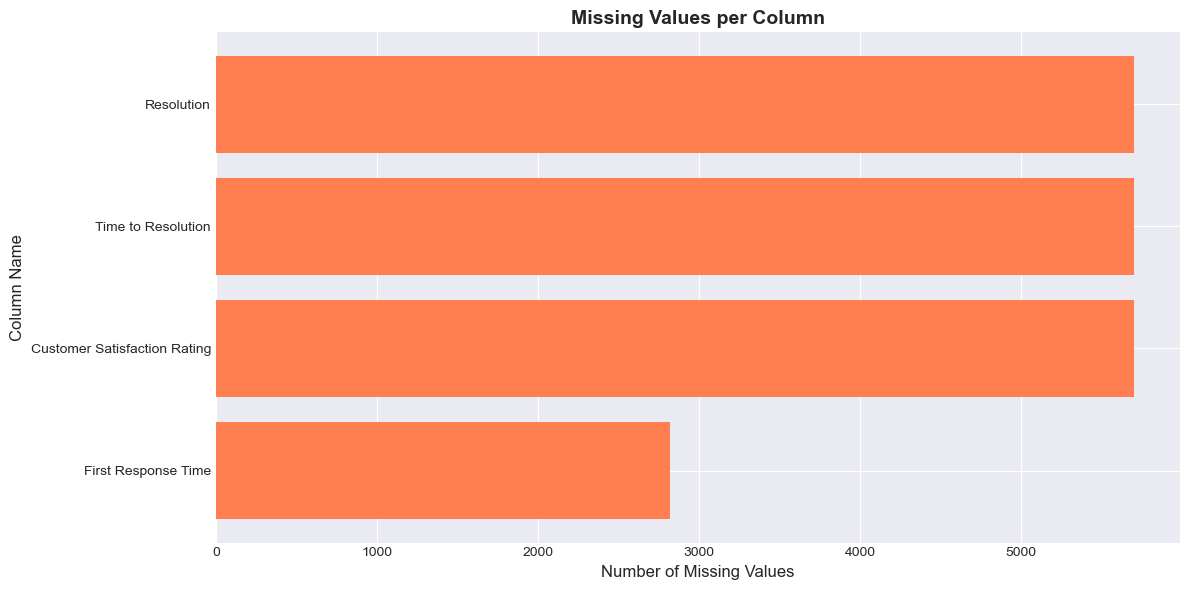

In [5]:
# Missing Values Analysis
print('=' * 70)
print('MISSING VALUES ANALYSIS')
print('=' * 70)

# Calculate missing values
missing_counts = tickets.isnull().sum()
missing_percent = (missing_counts / len(tickets)) * 100

missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing Count': missing_counts.values,
    'Missing Percentage': missing_percent.values
}).sort_values('Missing Count', ascending = False)

# Display only columns with missing values
missing_with_nulls = missing_df[missing_df['Missing Count'] > 0]
if len(missing_with_nulls) > 0:
    print(missing_with_nulls.to_string(index = False))
else:
    print('No missing values found')

# Visualize missing values
plt.figure(figsize = (12, 6))
missing_with_nulls_sorted = missing_with_nulls.sort_values('Missing Count', ascending = True)
plt.barh(missing_with_nulls_sorted['Column'], missing_with_nulls_sorted['Missing Count'], color = 'coral')
plt.xlabel('Number of Missing Values', fontsize = 12)
plt.ylabel('Column Name', fontsize = 12)
plt.title('Missing Values per Column', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

In [6]:
# Duplicate Records
print('=' * 70)
print('DUPLICATE RECORDS')
print('=' * 70)

duplicates = tickets.duplicated().sum()
print(f"Total duplicate rows: {duplicates:,} ({(duplicates / len(tickets) * 100):.2f}%)")

# Check duplicates in Ticket ID
if 'Ticket ID' in tickets.columns:
    duplicate_ids = tickets['Ticket ID'].duplicated().sum()
    print(f'Duplicate Ticket IDs: {duplicate_ids}')

DUPLICATE RECORDS
Total duplicate rows: 0 (0.00%)
Duplicate Ticket IDs: 0


CUSTOMER DEMOGRAPHICS
AGE STATISTICS:
count   8469.000
mean      44.027
std       15.296
min       18.000
25%       31.000
50%       44.000
75%       57.000
max       70.000
Name: Customer Age, dtype: float64

GENDER DISTRIBUTION
Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64

Male: 34.2%
Female: 34.1%
Other: 31.7%


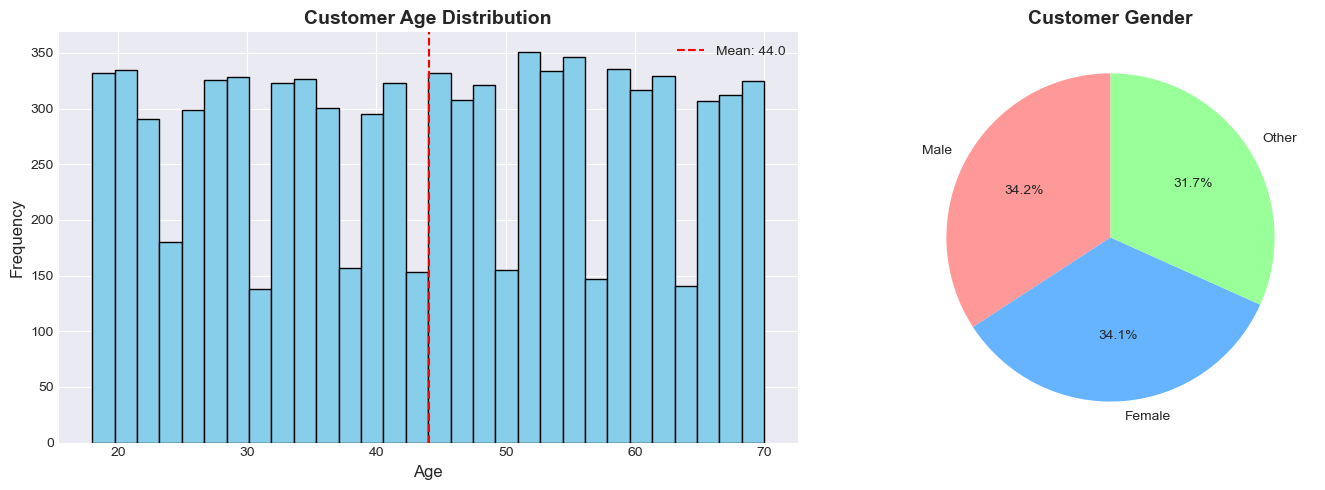

In [7]:
# Customer Demographics
print('=' * 70)
print('CUSTOMER DEMOGRAPHICS')
print('=' * 70)

# Age statistics
if 'Customer Age' in tickets.columns:
    print('AGE STATISTICS:')
    print(tickets['Customer Age'].describe())
    print()

# Gender distribution
if 'Customer Gender' in tickets.columns:
    print('GENDER DISTRIBUTION')
    gender_counts = tickets['Customer Gender'].value_counts()
    print(gender_counts)
    print()

    # Gender percentages
    for gender, count in gender_counts.items():
        pct = (count / len(tickets)) * 100
        print(f'{gender}: {pct:.1f}%')

# Visualize demographics
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

# Age distribution
if 'Customer Age' in tickets.columns:
    axes[0].hist(tickets['Customer Age'].dropna(), bins = 30, color = 'skyblue', edgecolor = 'black')
    axes[0].set_xlabel('Age', fontsize = 12)
    axes[0].set_ylabel('Frequency', fontsize = 12)
    axes[0].set_title('Customer Age Distribution', fontsize = 14, fontweight = 'bold')
    axes[0].axvline(tickets['Customer Age'].mean(), color = 'red', linestyle = '--', label = f"Mean: {tickets['Customer Age'].mean():.1f}")
    axes[0].legend()

# Gender distribution
if 'Customer Gender' in tickets.columns:
    gender_counts = tickets['Customer Gender'].value_counts()
    axes[1].pie(gender_counts, labels = gender_counts.index, autopct = '%1.1f%%', startangle = 90,
                colors = ['#ff9999', '#66b3ff', '#99ff99'])
    axes[1].set_title('Customer Gender', fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()

TICKET TYPE ANALYSIS
TICKET TYPES:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Refund request: 20.7%
Technical issue: 20.6%
Cancellation request: 20.0%
Product inquiry: 19.4%
Billing inquiry: 19.3%


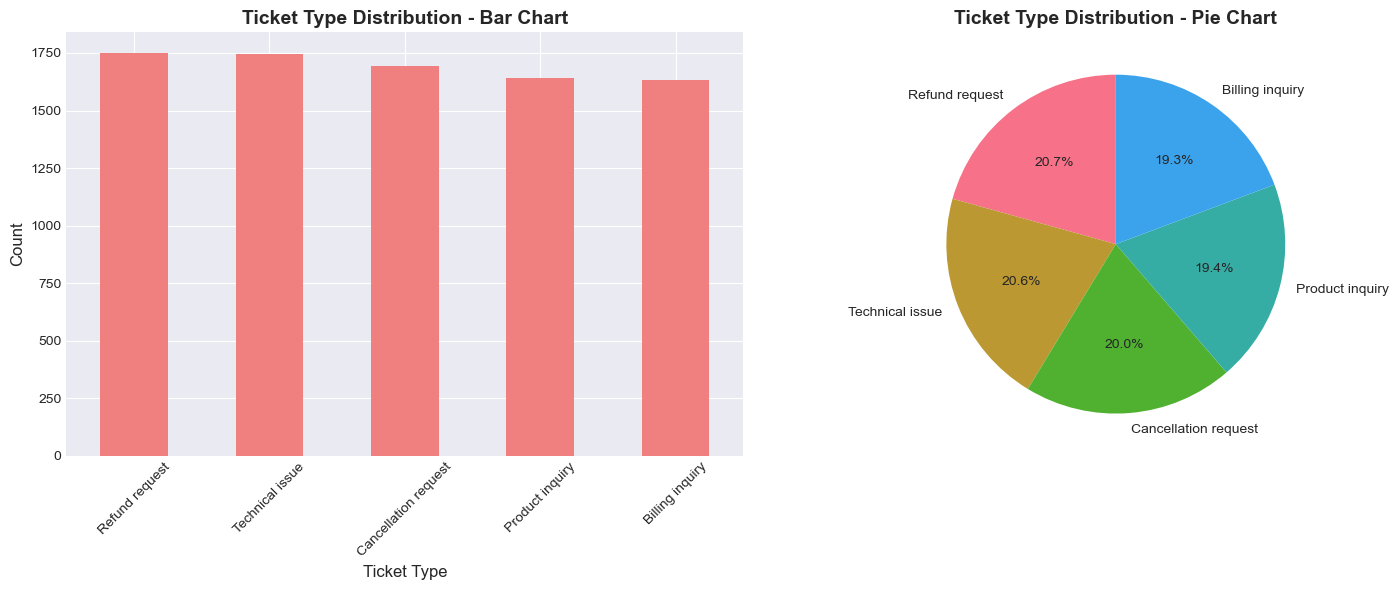

In [8]:
# Ticket Type Analysis
print('=' * 70)
print('TICKET TYPE ANALYSIS')
print('=' * 70)

if 'Ticket Type' in tickets.columns:
    print('TICKET TYPES:')
    ticket_types = tickets['Ticket Type'].value_counts()
    print(ticket_types)
    print()

    # Percentages
    for ticket_type, count in ticket_types.items():
        pct = (count / len(tickets)) * 100
        print(f"{ticket_type}: {pct:.1f}%")

    # Visulization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 6))

    # Bar chart
    ticket_types.plot(kind = 'bar', ax = ax1, color = 'lightcoral')
    ax1.set_title('Ticket Type Distribution - Bar Chart', fontsize = 14, fontweight = 'bold')
    ax1.set_xlabel('Ticket Type', fontsize = 12)
    ax1.set_ylabel('Count', fontsize = 12)
    ax1.tick_params(axis = 'x', rotation = 45)

    # Pie chart
    ax2.pie(ticket_types, labels = ticket_types.index, autopct = '%1.1f%%', startangle = 90)
    ax2.set_title('Ticket Type Distribution - Pie Chart', fontsize = 14, fontweight = 'bold')

    plt.tight_layout()
    plt.show()

TICKET SUBJECT ANALYSIS
TOP 10 TICKET SUBJECTS:
Ticket Subject
Refund request           576
Software bug             574
Product compatibility    567
Delivery problem         561
Hardware issue           547
Battery life             542
Network problem          539
Installation support     530
Product setup            529
Payment issue            526
Name: count, dtype: int64



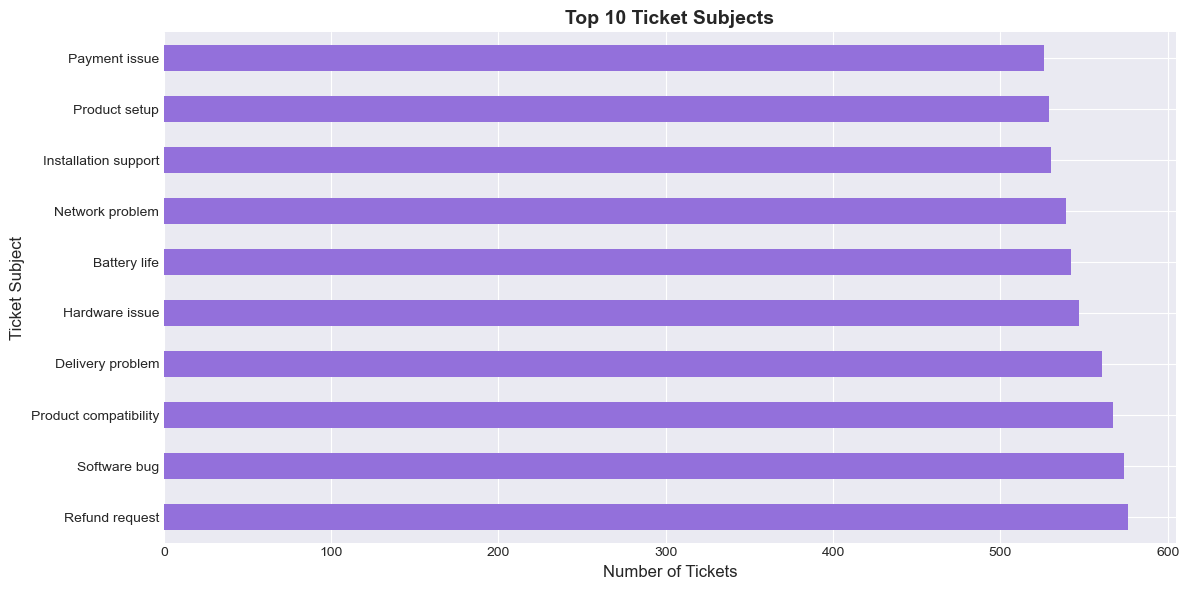

In [9]:
# Ticket Subject Analysis
print('=' * 70)
print('TICKET SUBJECT ANALYSIS')
print('=' * 70)

if 'Ticket Subject' in tickets.columns:
    print('TOP 10 TICKET SUBJECTS:')
    subject_counts = tickets['Ticket Subject'].value_counts().head(10)
    print(subject_counts)
    print()

    # Visualization
    plt.figure(figsize = (12, 6))
    subject_counts.plot(kind = 'barh', color = 'mediumpurple')
    plt.xlabel('Number of Tickets', fontsize = 12)
    plt.ylabel('Ticket Subject', fontsize = 12)
    plt.title('Top 10 Ticket Subjects', fontsize = 14, fontweight = 'bold')
    plt.tight_layout()
    plt.show()

TICKET PRIORITY ANALYSIS
TICKETS PRIORITY LEVELS:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Medium : 25.9%
Critical : 25.1%
High : 24.6%
Low : 24.4%


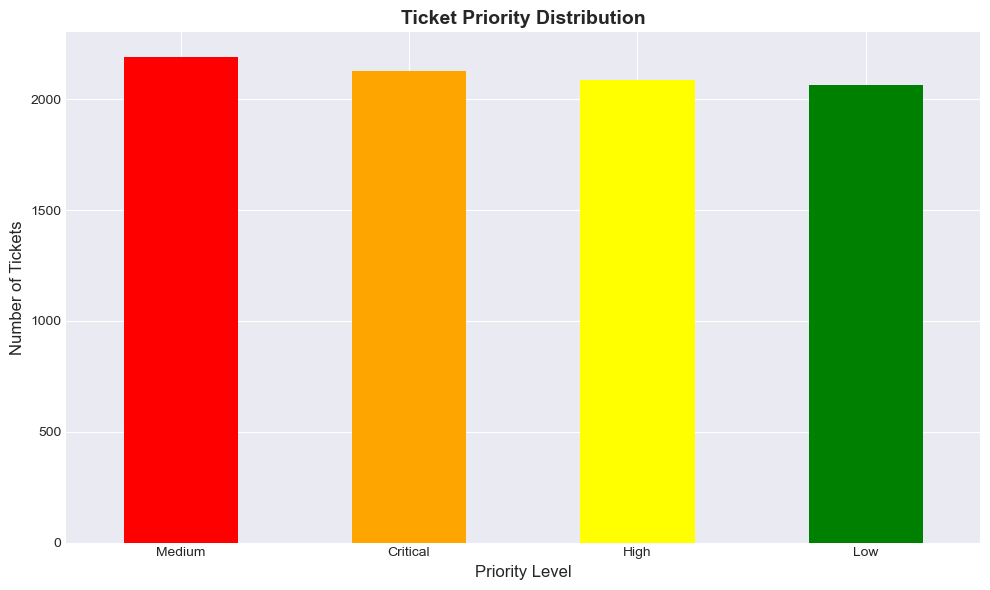

In [10]:
# Ticket Priority Analysis
print('=' * 70)
print('TICKET PRIORITY ANALYSIS')
print('=' * 70)

if 'Ticket Priority' in tickets.columns:
    print('TICKETS PRIORITY LEVELS:')
    priority_counts = tickets['Ticket Priority'].value_counts()
    print(priority_counts)
    print()

    # Percentages
    for priority, count in priority_counts.items():
        pct = (count / len(tickets)) * 100
        print(f"{priority} : {pct:.1f}%")

    # Visualization
    plt.figure(figsize = (10, 6))
    priority_counts.plot(kind = 'bar', color = ['red', 'orange', 'yellow', 'green'])
    plt.title('Ticket Priority Distribution', fontsize = 14, fontweight = 'bold')
    plt.xlabel('Priority Level', fontsize = 12)
    plt.ylabel('Number of Tickets', fontsize = 12)
    plt.xticks(rotation = 0)
    plt.tight_layout()
    plt.show()

TICKET CHANNEL ANALYSIS
Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

Email: 25.3%
Phone: 25.2%
Social media: 25.0%
Chat: 24.5%


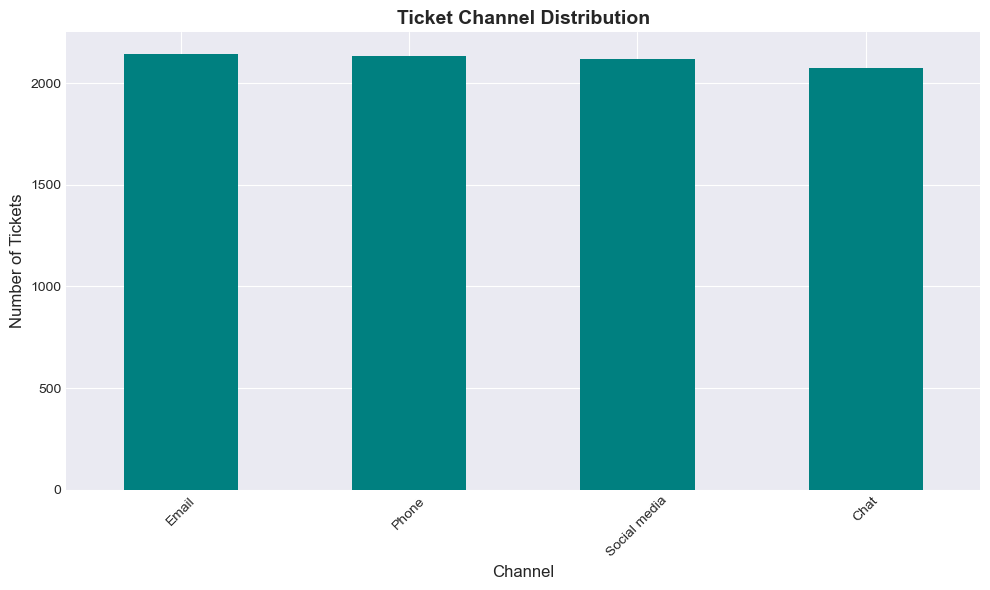

In [11]:
# Ticket Channel Analysis
print('=' * 70)
print('TICKET CHANNEL ANALYSIS')
print('=' * 70)

if 'Ticket Channel' in tickets.columns:
    channel_counts = tickets['Ticket Channel'].value_counts()
    print(channel_counts)
    print()

    # Percentages
    for channel, count in channel_counts.items():
        pct = (count / len(tickets)) * 100
        print(f"{channel}: {pct:.1f}%")

    # Visualization
    plt.figure(figsize = (10, 6))
    channel_counts.plot(kind = 'bar', color = 'teal')
    plt.title('Ticket Channel Distribution', fontsize = 14, fontweight = 'bold')
    plt.xlabel('Channel', fontsize = 12)
    plt.ylabel('Number of Tickets', fontsize = 12)
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

PRODUCT ANALYSIS
Top 10 Products with Most Tickets:
Product Purchased
Canon EOS              240
GoPro Hero             228
Nest Thermostat        225
Philips Hue Lights     221
Amazon Echo            221
LG Smart TV            219
Sony Xperia            217
Roomba Robot Vacuum    216
Apple AirPods          213
LG OLED                213
Name: count, dtype: int64



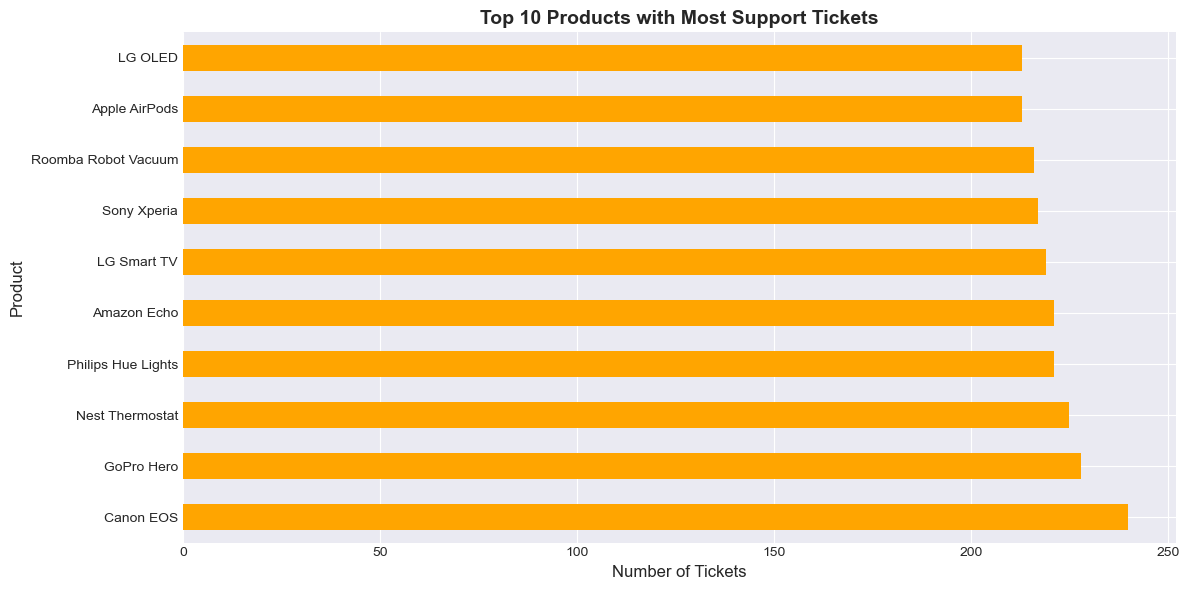

In [12]:
# Product Analysis
print('=' * 70)
print('PRODUCT ANALYSIS')
print('=' * 70)

if 'Product Purchased' in tickets.columns:
    print('Top 10 Products with Most Tickets:')
    product_counts = tickets['Product Purchased'].value_counts().head(10)
    print(product_counts)
    print()

    # Visualization
    plt.figure(figsize = (12, 6))
    product_counts.plot(kind = 'barh', color = 'orange')
    plt.xlabel('Number of Tickets', fontsize = 12)
    plt.ylabel('Product', fontsize = 12)
    plt.title('Top 10 Products with Most Support Tickets', fontsize = 14, fontweight = 'bold')
    plt.tight_layout()
    plt.show()

CUSTOMER SATISFACTION RATING ANALYSIS
count   2769.000
mean       2.991
std        1.407
min        1.000
25%        2.000
50%        3.000
75%        4.000
max        5.000
Name: Customer Satisfaction Rating, dtype: float64

RATING DISTRIBUTION
Customer Satisfaction Rating
1.000    553
2.000    549
3.000    580
4.000    543
5.000    544
Name: count, dtype: int64

AVERAGE SATISFACTION RATING: 2.99/ 5.0

1 stars: 20.0%
2 stars: 19.8%
3 stars: 20.9%
4 stars: 19.6%
5 stars: 19.6%


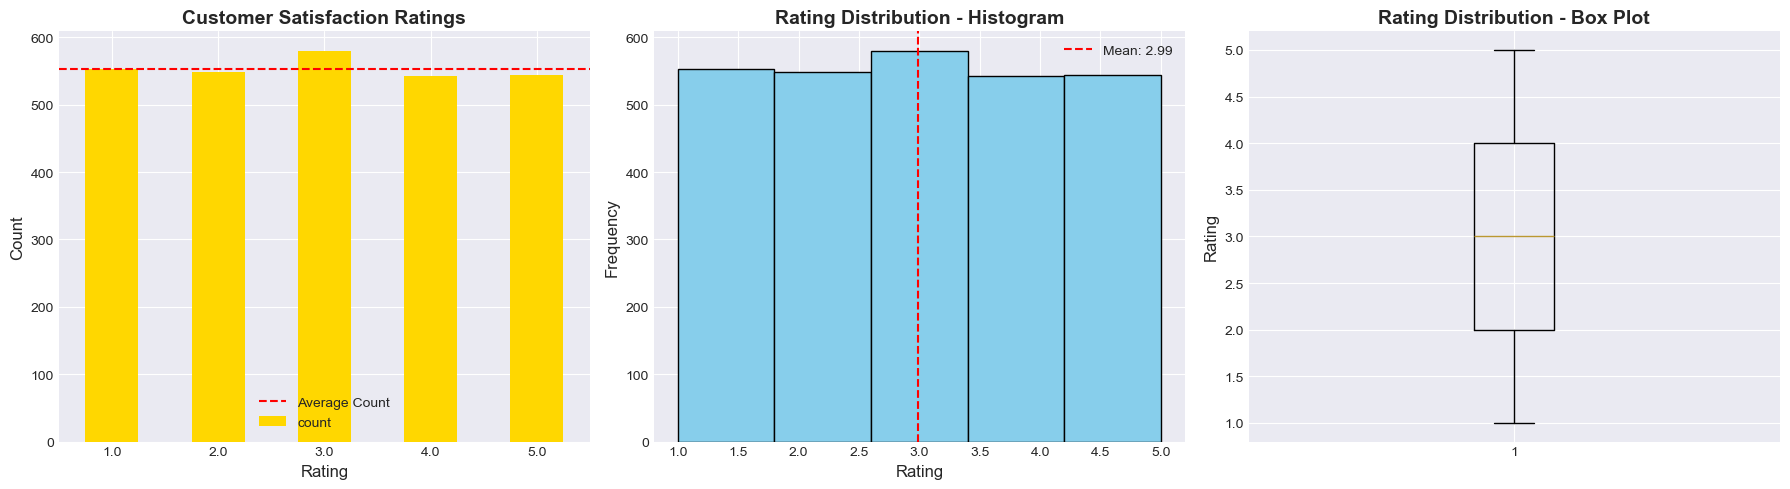

In [13]:
# Customer Satisfcation Rating Analysis
print('=' * 70)
print('CUSTOMER SATISFACTION RATING ANALYSIS')
print('=' * 70)

if 'Customer Satisfaction Rating' in tickets.columns:
    # Basic Statistics
    print(tickets['Customer Satisfaction Rating'].describe())
    print()

    # Count by rating
    print('RATING DISTRIBUTION')
    rating_counts = tickets['Customer Satisfaction Rating'].value_counts().sort_index()
    print(rating_counts)
    print()

    # Average rating
    avg_rating = tickets['Customer Satisfaction Rating'].mean()
    print(f"AVERAGE SATISFACTION RATING: {avg_rating:.2f}/ 5.0")
    print()

    # Percentage of each rating
    total_rating = tickets['Customer Satisfaction Rating'].notna().sum()
    for rating in sorted(tickets['Customer Satisfaction Rating'].dropna().unique()):
        count = (tickets['Customer Satisfaction Rating'] == rating).sum()
        pct = (count / total_rating) * 100
        print(f"{rating:.0f} stars: {pct:.1f}%")

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize = (18, 5))

    # Bar chart
    rating_counts.plot(kind = 'bar', ax = axes[0], color = 'gold')
    axes[0].set_title('Customer Satisfaction Ratings', fontsize = 14, fontweight = 'bold')
    axes[0].set_xlabel('Rating', fontsize = 12)
    axes[0].set_ylabel('Count', fontsize = 12)
    axes[0].axhline(y = rating_counts.mean(), color = 'r', linestyle = '--', label = 'Average Count')
    axes[0].legend()

    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation = 0)

    # Histogram
    axes[1].hist(tickets['Customer Satisfaction Rating'].dropna(), bins = 5, color = 'skyblue', edgecolor = 'black')
    axes[1].set_title('Rating Distribution - Histogram', fontsize = 14, fontweight = 'bold')
    axes[1].set_xlabel('Rating', fontsize = 12)
    axes[1].set_ylabel('Frequency', fontsize = 12)
    axes[1].axvline(avg_rating, color = 'red', linestyle = '--', label = f"Mean: {avg_rating:.2f}")
    axes[1].legend()

    # Box plot
    axes[2].boxplot(tickets['Customer Satisfaction Rating'].dropna())
    axes[2].set_title('Rating Distribution - Box Plot', fontsize = 14, fontweight = 'bold')
    axes[2].set_ylabel('Rating', fontsize = 12)

    plt.tight_layout()
    plt.show()

RESPONSE TIME ANALYSIS
FIRST RESONSE TIME:
Total records: 5,650
Missing values: 2,819

TIME TO RESOLUTION:
Total records: 2,769
Missing value: 5,700

RESOLUTINO TIME STATISTICS (HOURS):
count   1404.000
mean       7.578
std        5.597
min        0.000
25%        3.000
50%        6.342
75%       11.354
max       23.467
Name: Resolution_Hours, dtype: float64



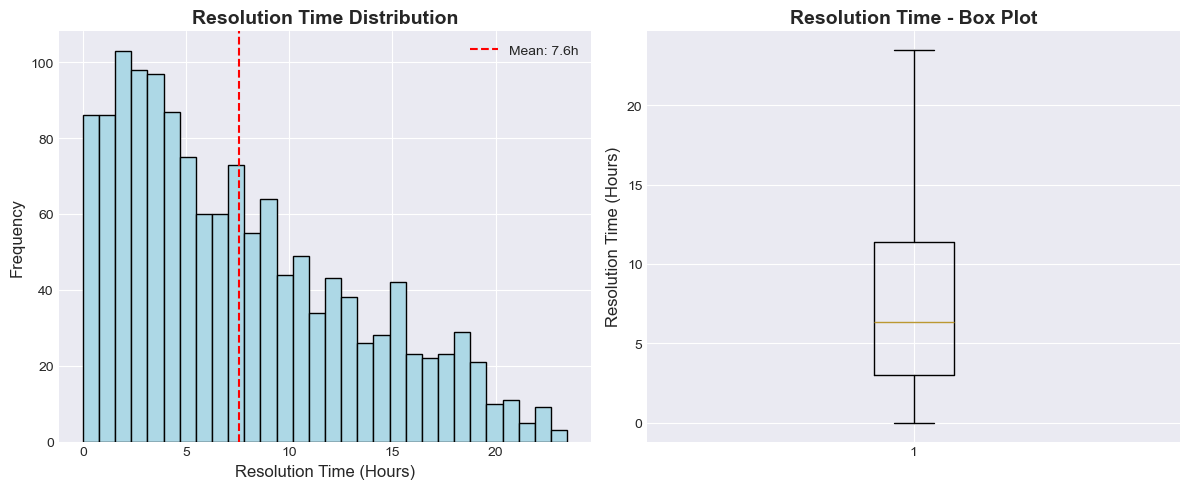

In [14]:
# Response Time Analysis
print('=' * 70)
print('RESPONSE TIME ANALYSIS')
print('=' * 70)

if 'First Response Time' in tickets.columns:
    # Convert to datetime if not already
    tickets['First Response Time'] = pd.to_datetime(tickets['First Response Time'], errors = 'coerce')

    print('FIRST RESONSE TIME:')
    print(f"Total records: {tickets['First Response Time'].notna().sum():,}")
    print(f"Missing values: {tickets['First Response Time'].isna().sum():,}")
    print()

if 'Time to Resolution' in tickets.columns:
    # Convert to datetime if not already
    tickets['Time to Resolution'] = pd.to_datetime(tickets['Time to Resolution'], errors = 'coerce')

    print('TIME TO RESOLUTION:')
    print(f"Total records: {tickets['Time to Resolution'].notna().sum():,}")
    print(f"Missing value: {tickets['Time to Resolution'].isna().sum():,}")
    print()

# Calculate resolution time in hours (if both columns exist)
if 'First Response Time' in tickets.columns and 'Time to Resolution' in tickets.columns:
    tickets['Resolution_Hours'] = (tickets['Time to Resolution'] - tickets['First Response Time']).dt.total_seconds() / 3600

    # Only analyze non-negative values
    valid_resolution = tickets[tickets['Resolution_Hours'] >= 0]['Resolution_Hours']

    if len(valid_resolution) > 0:
        print('RESOLUTINO TIME STATISTICS (HOURS):')
        print(valid_resolution.describe())
        print()

        # Visualization
        plt.figure(figsize = (12, 5))
        
        plt.subplot(1, 2, 1)
        plt.hist(valid_resolution, bins = 30, color = 'lightblue', edgecolor = 'black')
        plt.xlabel('Resolution Time (Hours)', fontsize = 12)
        plt.ylabel('Frequency', fontsize = 12)
        plt.title('Resolution Time Distribution', fontsize = 14, fontweight = 'bold')
        plt.axvline(valid_resolution.mean(), color = 'red', linestyle = '--', label = f"Mean: {valid_resolution.mean():.1f}h")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.boxplot(valid_resolution)
        plt.ylabel('Resolution Time (Hours)', fontsize = 12)
        plt.title('Resolution Time - Box Plot', fontsize = 14, fontweight = 'bold')

        plt.tight_layout()
        plt.show()

TEXT ANALYSIS - TICKET DESCRIPTION
DESCRIPTION LENGTH STATISTICS (CHARACTERS):
count   8469.000
mean     289.822
std       43.594
min      151.000
25%      273.000
50%      298.000
75%      318.000
max      397.000
Name: Description_Length, dtype: float64

DESCRIPTION WORD COUNT STATISTICS:
count   8469.000
mean      46.467
std        8.462
min       21.000
25%       43.000
50%       49.000
75%       52.000
max       63.000
Name: Description_Words, dtype: float64



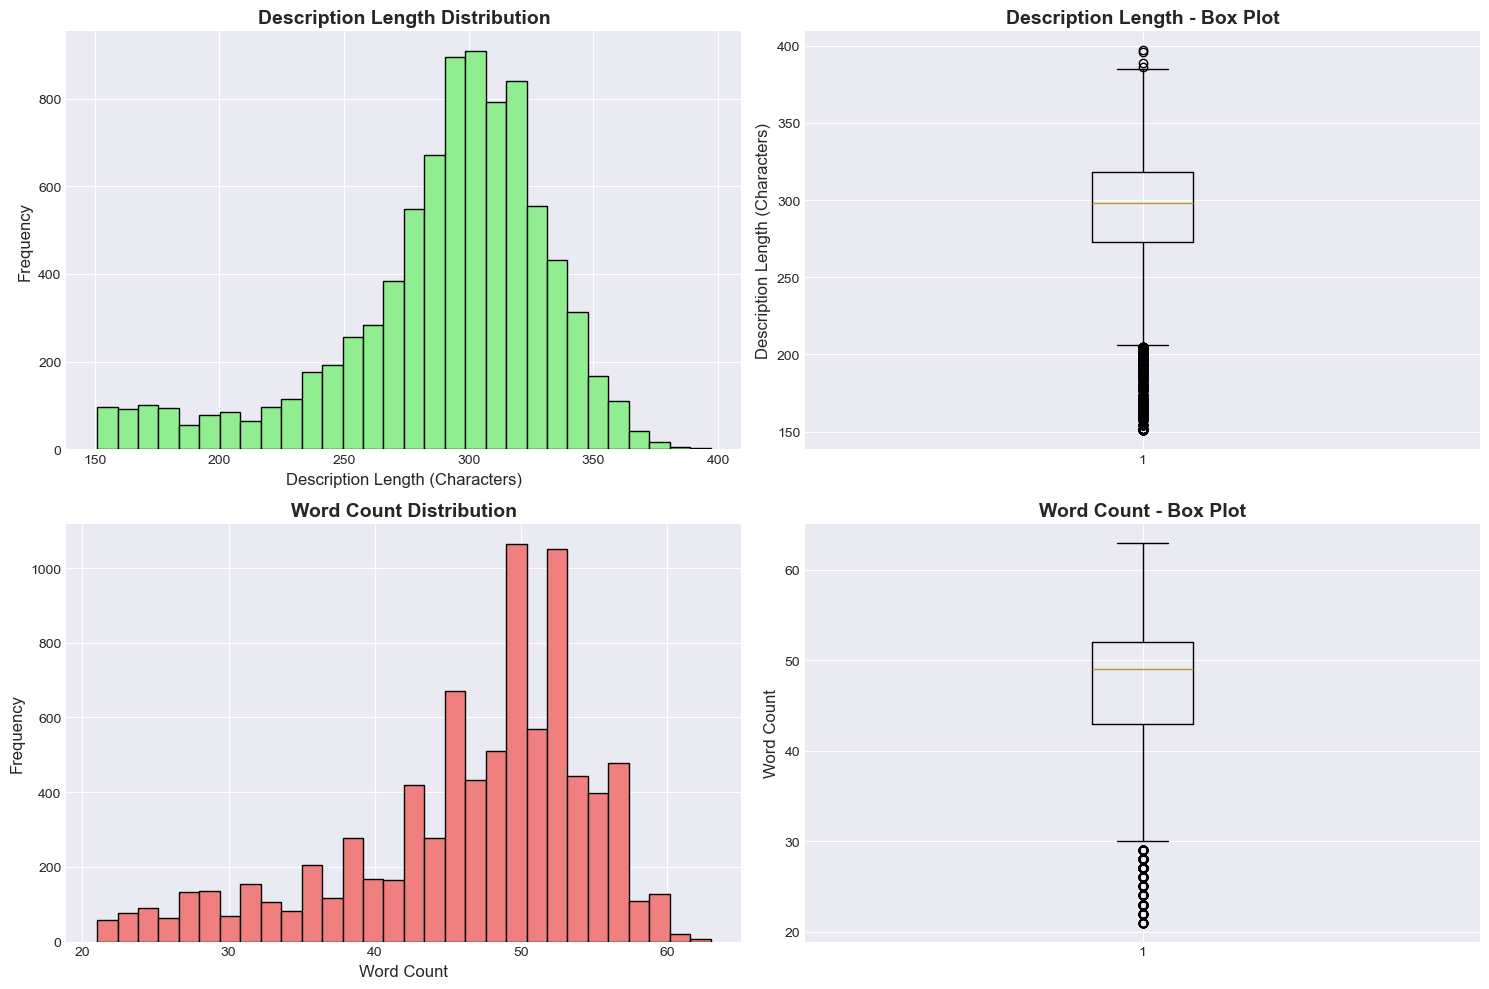

In [15]:
# Text Analysis - Ticket Description
print('=' * 70)
print('TEXT ANALYSIS - TICKET DESCRIPTION')
print('=' * 70)

if 'Ticket Description' in tickets.columns:
    # Calculate text length
    tickets['Description_Length'] = tickets['Ticket Description'].fillna('').str.len()
    tickets['Description_Words'] = tickets['Ticket Description'].fillna('').str.split().str.len()

    print('DESCRIPTION LENGTH STATISTICS (CHARACTERS):')
    print(tickets['Description_Length'].describe())
    print()

    print('DESCRIPTION WORD COUNT STATISTICS:')
    print(tickets['Description_Words'].describe())
    print()

    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize = (15, 10))

    # Character length histogram
    axes[0, 0].hist(tickets['Description_Length'], bins = 30, color = 'lightgreen', edgecolor = 'black')
    axes[0, 0].set_xlabel('Description Length (Characters)', fontsize = 12)
    axes[0, 0].set_ylabel('Frequency', fontsize = 12)
    axes[0, 0].set_title('Description Length Distribution', fontsize = 14, fontweight = 'bold')

    # Character length box plot
    axes[0, 1].boxplot(tickets['Description_Length'])
    axes[0, 1].set_ylabel('Description Length (Characters)', fontsize = 12)
    axes[0, 1].set_title('Description Length - Box Plot', fontsize = 14, fontweight = 'bold')

    # Word count histogram
    axes[1, 0].hist(tickets['Description_Words'], bins = 30, color = 'lightcoral', edgecolor = 'black')
    axes[1, 0].set_xlabel('Word Count', fontsize = 12)
    axes[1, 0].set_ylabel('Frequency', fontsize = 12)
    axes[1, 0].set_title('Word Count Distribution', fontsize = 14, fontweight = 'bold')

    # Word count box plot
    axes[1, 1].boxplot(tickets['Description_Words'])
    axes[1, 1].set_ylabel('Word Count', fontsize = 12)
    axes[1, 1].set_title('Word Count - Box Plot', fontsize = 14, fontweight = 'bold')

    plt.tight_layout()
    plt.show()

CROSS-ANALYSIS
PRIORITY vs STATUS:
Ticket Status    Closed  Open  Pending Customer Response
Ticket Priority                                         
Critical            726   692                        711
High                705   704                        676
Low                 644   696                        723
Medium              694   727                        771



<Figure size 1200x600 with 0 Axes>

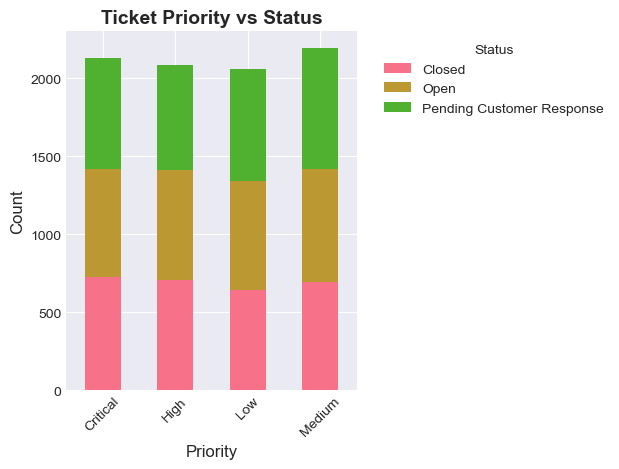

PRIORITY vs CHANNEL:
Ticket Channel   Chat  Email  Phone  Social media
Ticket Priority                                  
Critical          504    571    526           528
High              517    504    512           552
Low               501    525    499           538
Medium            551    543    595           503



<Figure size 1200x600 with 0 Axes>

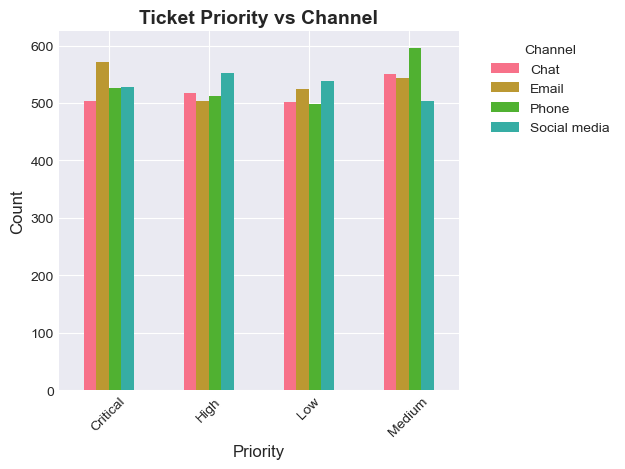

TICKET TYPE vs SATISFACTION RATING:
                      mean  count
Ticket Type                      
Billing inquiry      3.028    544
Cancellation request 3.029    516
Product inquiry      3.017    533
Refund request       2.935    596
Technical issue      2.959    580



<Figure size 1000x600 with 0 Axes>

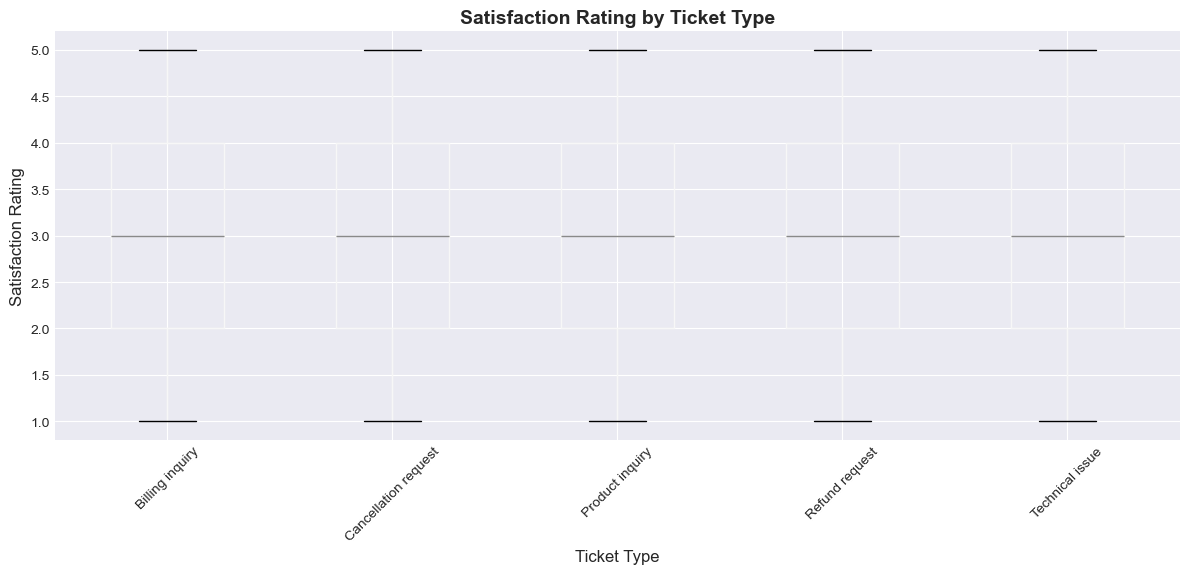

In [16]:
# Cross-Analysis - Priority vs Status
print('=' * 70)
print('CROSS-ANALYSIS')
print('=' * 70)

if 'Ticket Priority' in tickets.columns and 'Ticket Status' in tickets.columns:
    print('PRIORITY vs STATUS:')
    priority_status = pd.crosstab(tickets['Ticket Priority'], tickets['Ticket Status'])
    print(priority_status)
    print()

    # Visualization
    plt.figure(figsize = (12, 6))
    priority_status.plot(kind = 'bar', stacked = True)
    plt.title('Ticket Priority vs Status', fontsize = 14, fontweight = 'bold')
    plt.xlabel('Priority', fontsize = 12)
    plt.ylabel('Count', fontsize = 12)
    plt.legend(title = 'Status', bbox_to_anchor = (1.05, 1), loc = 'upper left')
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

# Priority vs Channel
if 'Ticket Priority' in tickets.columns and 'Ticket Channel' in tickets.columns:
    print('PRIORITY vs CHANNEL:')
    priority_channel = pd.crosstab(tickets['Ticket Priority'], tickets['Ticket Channel'])
    print(priority_channel)
    print()

    # Visualization
    plt.figure(figsize = (12, 6))
    priority_channel.plot( kind = 'bar', stacked = False)
    plt.title('Ticket Priority vs Channel', fontsize = 14, fontweight = 'bold')
    plt.xlabel('Priority', fontsize = 12)
    plt.ylabel('Count', fontsize = 12)
    plt.legend(title = 'Channel', bbox_to_anchor = (1.05, 1), loc = 'upper left')
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

# Type vs Satisfaction
if 'Ticket Type' in tickets.columns and 'Customer Satisfaction Rating' in tickets.columns:
    print('TICKET TYPE vs SATISFACTION RATING:')
    type_satisfaction = tickets.groupby('Ticket Type')['Customer Satisfaction Rating'].agg(['mean', 'count'])
    print(type_satisfaction)
    print()

    # Visualization
    plt.figure(figsize = (10, 6))
    tickets.boxplot(column = 'Customer Satisfaction Rating', by = 'Ticket Type', figsize = (12, 6))
    plt.title('Satisfaction Rating by Ticket Type', fontsize = 14, fontweight = 'bold')
    plt.suptitle('')
    plt.xlabel('Ticket Type' , fontsize = 12)
    plt.ylabel('Satisfaction Rating', fontsize = 12)
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

CORRELATION ANALYSIS
CORRELATIONS BETWEEN NUMERCIAL VARIABLES:
                              Customer Age  Customer Satisfaction Rating  \
Customer Age                         1.000                        -0.004   
Customer Satisfaction Rating        -0.004                         1.000   
Resolution_Hours                     0.004                         0.020   
Description_Length                  -0.006                        -0.014   
Description_Words                   -0.005                        -0.010   

                              Resolution_Hours  Description_Length  \
Customer Age                             0.004              -0.006   
Customer Satisfaction Rating             0.020              -0.014   
Resolution_Hours                         1.000              -0.014   
Description_Length                      -0.014               1.000   
Description_Words                       -0.003               0.913   

                              Description_Words  
Customer 

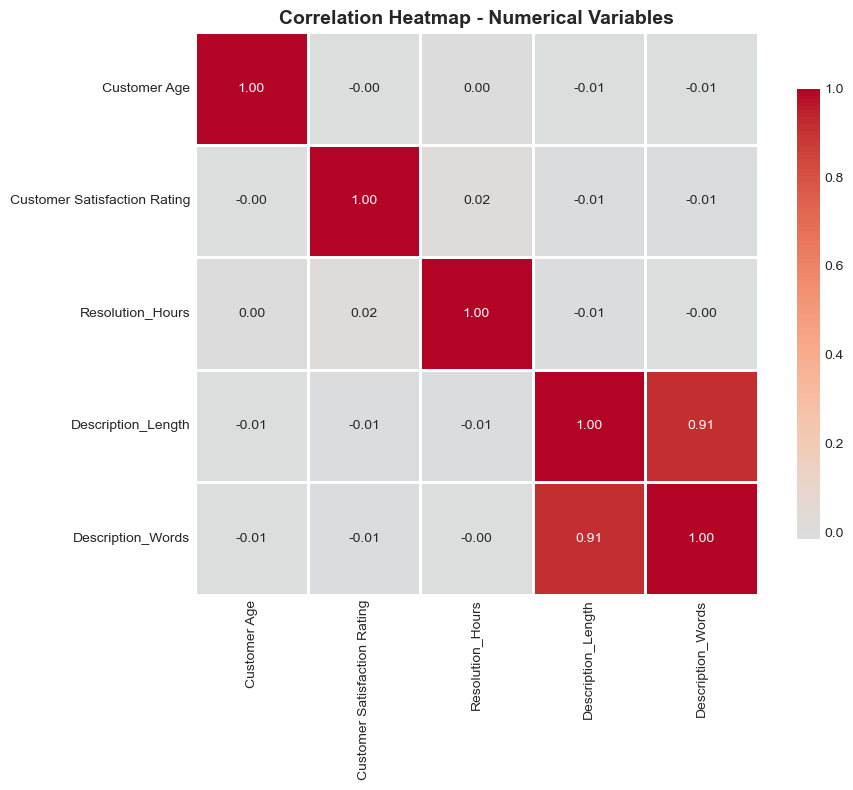

In [17]:
# Correlation Anaysis
print('=' * 70)
print('CORRELATION ANALYSIS')
print('=' * 70)

# Select only numerical columns for correlation
numerical_cols = tickets.select_dtypes(include = [np.number]).columns
numerical_cols = [col for col in numerical_cols if col not in ['Ticket ID']] # Exclude ID

if len(numerical_cols) > 1:
    print('CORRELATIONS BETWEEN NUMERCIAL VARIABLES:')

    # Calculate correlation matrix
    correlation_matrix = tickets[numerical_cols].corr()
    print(correlation_matrix)
    print()

    # Visualization
    plt.figure(figsize = (10, 8))
    sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', center = 0, square = True,
                linewidths = 1, cbar_kws = {"shrink": 0.8}, fmt = '.2f')
    plt.title('Correlation Heatmap - Numerical Variables', fontsize = 14, fontweight = 'bold')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numerical columns for correlation analysis')

DATE ANALYSIS
Purchase Date Range:
Earliest: 2020-01-01 00:00:00
Latest: 2021-12-30 00:00:00
Purchases by Year:
Purchase Year
2020    4236
2021    4233
Name: count, dtype: int64

Purchases by Month:
Purchase Month
1     736
2     715
3     672
4     718
5     701
6     678
7     727
8     691
9     696
10    735
11    704
12    696
Name: count, dtype: int64



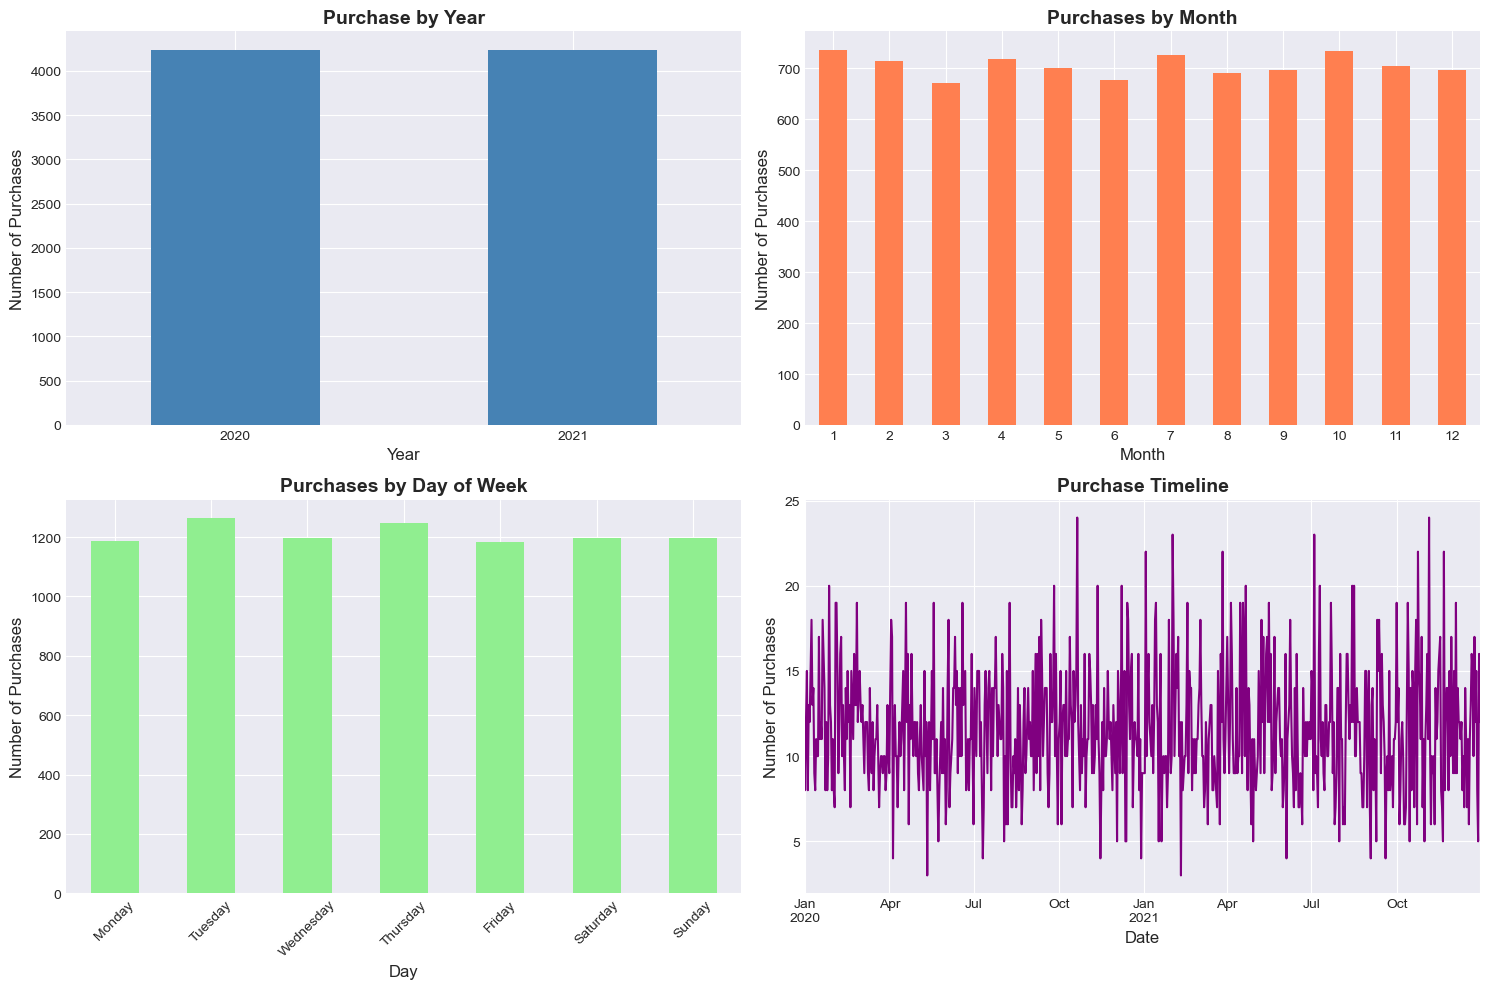

In [18]:
# Date Analysis
print('=' * 70)
print('DATE ANALYSIS')
print('=' * 70)

if 'Date of Purchase' in tickets.columns:
    # Convert to datetime
    tickets['Date of Purchase'] = pd.to_datetime(tickets['Date of Purchase'], errors = 'coerce')

    # Extract date components
    tickets['Purchase Year'] = tickets['Date of Purchase'].dt.year
    tickets['Purchase Month'] = tickets['Date of Purchase'].dt.month
    tickets['Purchase Day'] = tickets['Date of Purchase'].dt.day
    tickets['Purchase Day of Week'] = tickets['Date of Purchase'].dt.day_name()

    print('Purchase Date Range:')
    print(f"Earliest: {tickets['Date of Purchase'].min()}")
    print(f"Latest: {tickets['Date of Purchase'].max()}")

    # Year distribution
    print("Purchases by Year:")
    year_counts = tickets['Purchase Year'].value_counts().sort_index()
    print(year_counts)
    print()

    # Month distribution
    print('Purchases by Month:')
    month_counts = tickets['Purchase Month'].value_counts().sort_index()
    print(month_counts)
    print()

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize = (15, 10))

    # Purchase by Year
    year_counts.plot(kind = 'bar', ax = axes[0, 0], color = 'steelblue')
    axes[0, 0].set_title('Purchase by Year', fontsize = 14, fontweight = 'bold')
    axes[0, 0].set_xlabel('Year', fontsize = 12)
    axes[0, 0].set_ylabel('Number of Purchases', fontsize = 12)
    axes[0, 0].tick_params(axis = 'x', rotation = 0)

    # Purchase by Month
    month_counts.plot(kind = 'bar', ax = axes[0, 1], color = 'coral')
    axes[0, 1].set_title('Purchases by Month', fontsize = 14, fontweight = 'bold')
    axes[0, 1].set_xlabel('Month', fontsize = 12)
    axes[0, 1].set_ylabel('Number of Purchases', fontsize = 12)
    axes[0, 1].tick_params(axis = 'x', rotation = 0)

    # Purcahses by day of week
    dow_counts = tickets['Purchase Day of Week'].value_counts()
    dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dow_counts = dow_counts.reindex([d for d in dow_order if d in dow_counts.index])
    dow_counts.plot(kind = 'bar', ax = axes[1, 0], color = 'lightgreen')
    axes[1, 0].set_title('Purchases by Day of Week', fontsize = 14, fontweight = 'bold')
    axes[1, 0].set_xlabel('Day', fontsize = 12)
    axes[1, 0].set_ylabel('Number of Purchases', fontsize = 12)
    axes[1, 0].tick_params(axis = 'x', rotation = 45)

    # Timeline 
    purchase_timeline = tickets.groupby('Date of Purchase').size()
    purchase_timeline.plot(ax = axes[1, 1], color = 'purple')
    axes[1, 1].set_title('Purchase Timeline', fontsize = 14, fontweight = 'bold')
    axes[1, 1].set_xlabel('Date', fontsize = 12)
    axes[1, 1].set_ylabel('Number of Purchases', fontsize = 12)

    plt.tight_layout()
    plt.show()

In [19]:
# Summary Statistics
print('=' * 70)
print('COMPRENSIVE SUMMARY')
print('=' * 70)

summary_stats = {'Total Tickets': len(tickets), 
                 'Unique Customers': tickets['Customer Email'].nunique() if 'Customer Email' in tickets.columns else 'N/A',
                 'Date Range': f"{tickets['Date of Purchase'].min()} to {tickets['Date of Purchase'].max()}" if 'Date of Purchase'
                 in tickets.columns else 'N/A',
                 'Avg Customer Age': f"{tickets['Customer Age'].mean():.1f}" if 'Customer Age' in tickets.columns else 'N/A',
                 'Most Common Ticket Type': tickets['Ticket Type'].mode()[0] if 'Ticket Type' in tickets.columns else 'N/A',
                 'Most Common Priority': tickets['Ticket Priority'].mode()[0] if 'Ticket Priority' in tickets.columns else 'N/A',
                 'Most Common Channel': tickets['Ticket Channel'].mode()[0] if 'Ticket Channel' in tickets.columns else 'N/A',
                 'Avg Satisfaction': f"{tickets['Customer Satisfaction Rating'].mean():.2f}/5.0" if 'Customer Satisfaction Rating'
                 in tickets.columns else 'N/A',
                 'Missing Values': tickets.isnull().sum().sum(),
                 'Duplicate Records': tickets.duplicated().sum()
}

print('Key Metrics:')
for key, value in summary_stats.items():
    print(f"{key}: {value}")

COMPRENSIVE SUMMARY
Key Metrics:
Total Tickets: 8469
Unique Customers: 8320
Date Range: 2020-01-01 00:00:00 to 2021-12-30 00:00:00
Avg Customer Age: 44.0
Most Common Ticket Type: Refund request
Most Common Priority: Medium
Most Common Channel: Email
Avg Satisfaction: 2.99/5.0
Missing Values: 25619
Duplicate Records: 0


In [20]:
# Key Findings & Insights
print('=' * 70)
print('KEY FINDINS & INSIGHTS')
print('=' * 70)

print('Data Quality:')
print(f" Total missing values: {tickets.isnull().sum().sum():,}")
print(f"Columns with missing data: {(tickets.isnull().sum() > 0).sum()}")
print(f"Duplicate records: {tickets.duplicated().sum():,}")
print()

print('Customer Insights:')
if 'Customer Age' in tickets.columns:
    print(f"Average Customer Age: {tickets['Customer Age'].mean():.1f} years")
    print(f"Age Range: {tickets['Customer Age'].min():} - {tickets['Customer Age'].max():}")

if 'Customer Gender' in tickets.columns:
    most_common_gender = tickets['Customer Gender'].mode()[0]
    print(f"Most common gender: {most_common_gender}")
print()

print('Ticket Insights:')
if 'Ticket Type' in tickets.columns:
    print(f"Most common ticket type: {tickets['Ticket Type'].mode()[0]}")
if 'Ticket Priority' in tickets.columns:
    print(f"Most common priority: {tickets['Ticket Priority'].mode()[0]}")
if 'Ticket Status' in tickets.columns:
    print(f"Most common status: {tickets['Ticket Status'].mode()[0]}")
if 'Ticket Channel' in tickets.columns:
    print(f"Preferred channel: {tickets['Ticket Channel'].mode()[0]}")
print()

print("Satisfaction:")
if 'Customer Satisfaction Rating' in tickets.columns:
    avg_rating = tickets['Customer Satisfaction Rating'].mean()
    print(f"Average rating: {avg_rating:.2f}/5.0")
    
    low_ratings = (tickets['Customer Satisfaction Rating'] <= 2).sum()
    low_pct = (low_ratings / tickets['Customer Satisfaction Rating'].notna().sum()) * 100
    print(f"Low ratings (≤2): {low_ratings} ({low_pct:.1f}%)")
    
    high_ratings = (tickets['Customer Satisfaction Rating'] >= 4).sum()
    high_pct = (high_ratings / tickets['Customer Satisfaction Rating'].notna().sum()) * 100
    print(f"High ratings (≥4): {high_ratings} ({high_pct:.1f}%)")
print()

print("Products:")
if 'Product Purchased' in tickets.columns:
    top_product = tickets['Product Purchased'].value_counts().index[0]
    top_product_count = tickets['Product Purchased'].value_counts().iloc[0]
    print(f"Product with most tickets: {top_product} ({top_product_count} tickets)")

KEY FINDINS & INSIGHTS
Data Quality:
 Total missing values: 25,619
Columns with missing data: 5
Duplicate records: 0

Customer Insights:
Average Customer Age: 44.0 years
Age Range: 18 - 70
Most common gender: Male

Ticket Insights:
Most common ticket type: Refund request
Most common priority: Medium
Most common status: Pending Customer Response
Preferred channel: Email

Satisfaction:
Average rating: 2.99/5.0
Low ratings (≤2): 1102 (39.8%)
High ratings (≥4): 1087 (39.3%)

Products:
Product with most tickets: Canon EOS (240 tickets)


In [21]:
# Save Processed Data (Optional)
print('=' * 70)
print('SAVE ANALYSIS')
print('=' * 70)

# Save the explored dataset with new features
output_path = '/Users/vishalhooda/Documents/Intelligent-Customer-Support/data/processed/tickets_explored.csv'

try:
    tickets.to_csv(output_path, index = False)
    print(f"Dataset saved to: {output_path}")
except:
    print("Count not save file. Check if the directory exists.")

print('\n' + '=' * 70)
print('DATA EXPLORATION OF DATASET 1 COMPLETE')
print('=' * 70)

SAVE ANALYSIS
Dataset saved to: /Users/vishalhooda/Documents/Intelligent-Customer-Support/data/processed/tickets_explored.csv

DATA EXPLORATION OF DATASET 1 COMPLETE


# Dataset 2: Spam

In [22]:
# Load Spam Dataset
print('\n' + '=' * 70)
print('SPAM MESSAGES DATASET EXPLORATION')
print('=' * 70 + '\n')

# Load the spam dataset
spam_file_path = '/Users/vishalhooda/Documents/Intelligent-Customer-Support/data/raw/spam.csv'

# Load with encoding to handle special characters
spam = pd.read_csv(spam_file_path, encoding = 'latin-1')
print('Spam dataset loaded successfully')
print(f"Dataset shape: {spam.shape}")


SPAM MESSAGES DATASET EXPLORATION

Spam dataset loaded successfully
Dataset shape: (5572, 5)


In [23]:
# Initial Data Inspection

print('\n' +  '=' * 70)
print('INITIAL DATA INSPECTION')
print('=' * 70 + '\n')

# Display first few rows
print('First 10 rows (RAW DATA):')
print(spam.head(10))
print('\n' + '=' * 70)

# Display last few rows
print('\nLast 5 rows:')
print(spam.tail())
print('\n' + '=' * 70)

# Column information
print('\nCOLUMN NAMES:')
for i, col in enumerate(spam, 1):
    print(f"{i}. {col}")

print('\n' + '=' * 70)

# Data types and info
print('\nDATASET INFO:')
spam.info()


INITIAL DATA INSPECTION

First 10 rows (RAW DATA):
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   
5  spam  FreeMsg Hey there darling it's been 3 week's n...        NaN   
6   ham  Even my brother is not like to speak with me. ...        NaN   
7   ham  As per your request 'Melle Melle (Oru Minnamin...        NaN   
8  spam  WINNER!! As a valued network customer you have...        NaN   
9  spam  Had your mobile 11 months or more? U R entitle...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN  

In [24]:
# Data Cleaning - Handle Unnamed Columns
print('\n' + '=' * 70)
print('DATA CLEANING')
print('=' * 70 + '\n')

# Check for unnamed columns
unnamed_cols = [col for col in spam.columns if 'Unnamed' in col]
print(f"Found {len(unnamed_cols)} unnamed columns: {unnamed_cols}")

# Check how many non-null values in unnamed columns
print('\nNon-null counts in unnamed columns:')
for col in unnamed_cols:
    non_null = spam[col].notna().sum()
    print(f"{col}: {non_null} non-null values ({(non_null / len(spam) * 100):.2f}%)")

# These unnamed columns have very few values, likely erros in CSV, We'll drop them
print('\nDropping unnamed columns...')
spam = spam.drop(columns = unnamed_cols)
print(f"Unnamed columns dropped")

# Rename columns to meaningfull names
print('\nRenaming columns..')
spam.columns = ['label', 'message']
print('New column names:', list(spam.columns))

print('\nCLEANED DATA:')
print(spam.head())

print('\n' + '=' * 70)
print(f"Data cleaned! New shape: {spam.shape}")
print('=' * 70)


DATA CLEANING

Found 3 unnamed columns: ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Non-null counts in unnamed columns:
Unnamed: 2: 50 non-null values (0.90%)
Unnamed: 3: 12 non-null values (0.22%)
Unnamed: 4: 6 non-null values (0.11%)

Dropping unnamed columns...
Unnamed columns dropped

Renaming columns..
New column names: ['label', 'message']

CLEANED DATA:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Data cleaned! New shape: (5572, 2)


In [25]:
# Missing Values Analysis
print('\n' + '=' * 70)
print('MISSING VALUES ANALYSIS')
print('=' * 70 + '\n')

# Check for missing values in cleaned data
missing_counts = spam.isnull().sum()
missing_percent = (missing_counts / len(spam)) * 100

missing_df = pd.DataFrame({
    'Column' : missing_counts.index,
    'Missing Count' : missing_counts.values,
    'Missing Percentage' : missing_percent.values
})

print(missing_df.to_string(index = False))

if missing_counts.sum() == 0:
    print('\nNo missing values in cleaned dataset')
else:
    print(f"\nTotal missing values: {missing_counts.sum()}")

# Check for duplicates
duplicates = spam.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates} ({(duplicates / len(spam) * 100):.2f}%)")

if duplicates > 0:
    print(f"Note: {duplicates} duplicate messages found")


MISSING VALUES ANALYSIS

 Column  Missing Count  Missing Percentage
  label              0               0.000
message              0               0.000

No missing values in cleaned dataset

Duplicate Rows: 403 (7.23%)
Note: 403 duplicate messages found



LABEL DISTRIBUTION ANALYSIS

MESSAGE CLASSIFICATION:
label
ham     4825
spam     747
Name: count, dtype: int64

HAM: 4,825 messages (86.59%)
SPAM: 747 messages (13.41%)

SPAM RATE: 13.41%
HAM RATE: 86.59%

CLASS BALANCE:
Imbalance Ratio: 6.46:1
• SMOTE (oversampling)
• Class weights
• Stratified sampling


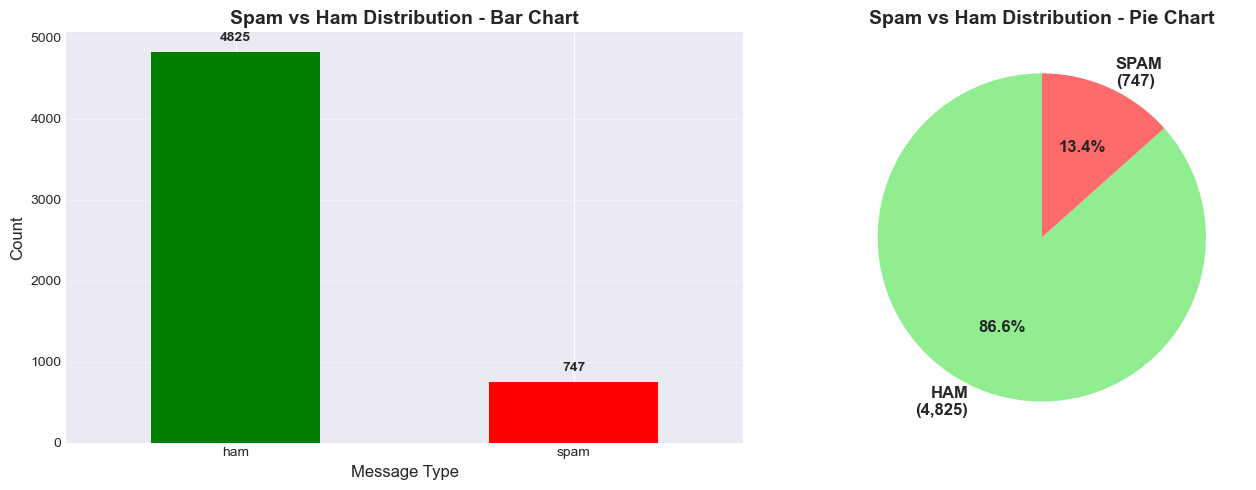

In [26]:
# Label Distribution Analysis
print('\n' + '=' * 70)
print('LABEL DISTRIBUTION ANALYSIS')
print('=' * 70 + '\n')

# Count spam vs ham
label_counts = spam['label'].value_counts()
print('MESSAGE CLASSIFICATION:')
print(label_counts)
print()

# Calculate percentages
total_messages = len(spam)
for label, count in label_counts.items():
    percentage = (count / total_messages) * 100
    print(f"{label.upper()}: {count:,} messages ({percentage:.2f}%)")

# Calculate spam rate
spam_count = label_counts.get('spam', 0)
spam_rate = (spam_count / total_messages) * 100
print(f"\nSPAM RATE: {spam_rate:.2f}%")
print(f"HAM RATE: {100 - spam_rate:.2f}%")

# Check class balance
print(f"\nCLASS BALANCE:")
ratio = label_counts.max() / label_counts.min()
print(f"Imbalance Ratio: {ratio:.2f}:1")
if ratio > 3:
    print('WARNING: Highly imbalanced dataset! Consider using:')
    print("• SMOTE (oversampling)")
    print('• Class weights')
    print('• Stratified sampling')
else:
    print('Dataset is reasonably balanced')

# Visualization
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Bar Chart
label_counts.plot(kind = 'bar', ax = axes[0], color = ['green', 'red'])
axes[0].set_title('Spam vs Ham Distribution - Bar Chart', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Message Type', fontsize = 12)
axes[0].set_ylabel('Count', fontsize = 12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation = 0)
axes[0].grid(axis = 'y', alpha = 0.3)

# Add count labels on bars
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha = 'center', va = 'bottom', fontweight = 'bold')

# Pie Chart
colors = ['#90EE90', '#FF6B6B']  # Light green for ham, light red for spam
axes[1].pie(label_counts, labels = [f'{label.upper()}\n({count:,})' for label, count in label_counts.items()],
            autopct = '%1.1f%%', startangle = 90, colors = colors, textprops = {'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Spam vs Ham Distribution - Pie Chart', fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()



MESSAGE LENGTH ANALYSIS

MESSAGE LENGTH STATISTICS (Characters):
count   5572.000
mean      80.119
std       59.691
min        2.000
25%       36.000
50%       61.000
75%      121.000
max      910.000
Name: message_length, dtype: float64

WORD COUNT STATISTICS:
count   5572.000
mean      15.494
std       11.329
min        1.000
25%        7.000
50%       12.000
75%       23.000
max      171.000
Name: word_count, dtype: float64

STATISTICS BY MESSAGE TYPE:

CHARACTER LENGTH:
         count    mean    std    min     25%     50%     75%     max
label                                                               
ham   4825.000  71.024 58.016  2.000  33.000  52.000  92.000 910.000
spam   747.000 138.866 29.183 13.000 132.500 149.000 157.000 224.000

WORD COUNT:
         count   mean    std   min    25%    50%    75%     max
label                                                          
ham   4825.000 14.201 11.425 1.000  7.000 11.000 19.000 171.000
spam   747.000 23.851  5.812 2.000 22.0

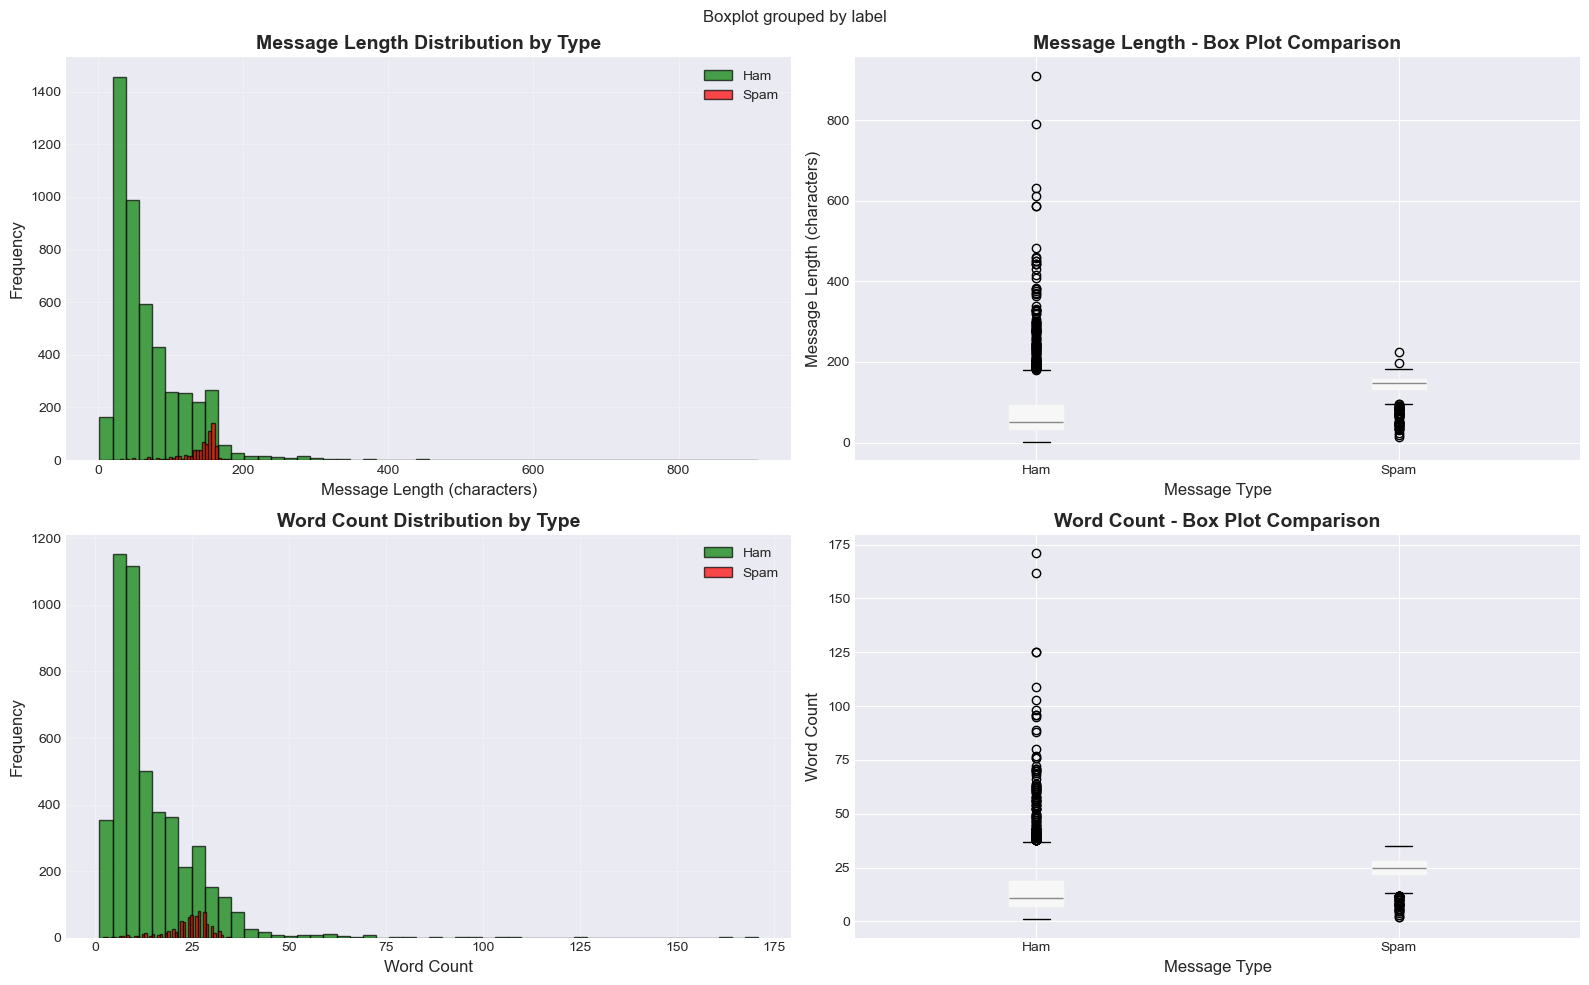

In [27]:
# Message Length Analysis
print('\n' + '=' * 70)
print('MESSAGE LENGTH ANALYSIS')
print('=' * 70 + '\n')

# Calculate message length
spam['message_length'] = spam['message'].str.len()
spam['word_count'] = spam['message'].str.split().str.len()

# Overall statistics
print('MESSAGE LENGTH STATISTICS (Characters):')
print(spam['message_length'].describe())
print()

print('WORD COUNT STATISTICS:')
print(spam['word_count'].describe())
print()

# Statistics by label
print('STATISTICS BY MESSAGE TYPE:\n')
print('CHARACTER LENGTH:')
print(spam.groupby('label')['message_length'].describe())
print()

print('WORD COUNT:')
print(spam.groupby('label')['word_count'].describe())
print()

# Compare averages
print('AVERAGE COMPARISON:')
avg_stats = spam.groupby('label')[['message_length', 'word_count']].mean()
print(avg_stats)
print()

ham_avg_len = spam[spam['label'] == 'ham']['message_length'].mean()
spam_avg_len = spam[spam['label'] == 'spam']['message_length'].mean()
print(f"INSIGHT: Spam messages are {(spam_avg_len / ham_avg_len - 1) * 100:.1f}% {'longer' if spam_avg_len > ham_avg_len else 'shorter'} than ham messages on average")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize = (16, 10))

# Character length - Histogram comparison
axes[0, 0].hist(spam[spam['label'] == 'ham']['message_length'], bins = 50, alpha = 0.7,
                label = 'Ham', color = 'green', edgecolor = 'black')
axes[0, 0].hist(spam[spam['label'] == 'spam']['message_length'], bins = 50, alpha = 0.7,
                label = 'Spam', color = 'red', edgecolor = 'black')
axes[0, 0].set_xlabel('Message Length (characters)', fontsize = 12)
axes[0, 0].set_ylabel('Frequency', fontsize = 12)
axes[0, 0].set_title('Message Length Distribution by Type', fontsize = 14, fontweight = 'bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha = 0.3)

# Character length - Box plot
spam.boxplot(column = 'message_length', by = 'label', ax = axes[0, 1], patch_artist = True)
axes[0, 1].set_title('Message Length - Box Plot Comparison', fontsize = 14, fontweight = 'bold')
axes[0, 1].set_xlabel('Message Type', fontsize = 12)
axes[0, 1].set_ylabel('Message Length (characters)', fontsize = 12)
plt.sca(axes[0, 1])
plt.xticks([1, 2], ['Ham', 'Spam'])

# Word count - Histogram comparison
axes[1, 0].hist(spam[spam['label'] == 'ham']['word_count'], bins = 50, alpha = 0.7,
                label = 'Ham', color = 'green', edgecolor = 'black')
axes[1, 0].hist(spam[spam['label'] == 'spam']['word_count'], bins = 50, alpha = 0.7,
                label = 'Spam', color = 'red', edgecolor = 'black')
axes[1, 0].set_xlabel('Word Count', fontsize = 12)
axes[1, 0].set_ylabel('Frequency', fontsize = 12)
axes[1, 0].set_title('Word Count Distribution by Type', fontsize = 14, fontweight = 'bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha = 0.3)

# Word count - Box plot
spam.boxplot(column = 'word_count', by = 'label', ax = axes[1, 1], patch_artist = True)
axes[1, 1].set_title('Word Count - Box Plot Comparison', fontsize = 14, fontweight = 'bold')
axes[1, 1].set_xlabel('Message Type', fontsize = 12)
axes[1, 1].set_ylabel('Word Count', fontsize = 12)
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['Ham', 'Spam'])

plt.tight_layout()
plt.show()


TEXT CONTENT ANALYSIS

SAMPLE HAM MESSAGES:
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got a...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my brother is not like to speak with me. They treat me like aids patent.

SAMPLE SPAM MESSAGES:
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entr...

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it s...

3. WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To clai...

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera f...

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6day...

CHARACTER PATTERNS BY TYPE:

HAM MESSAGES:
Contai

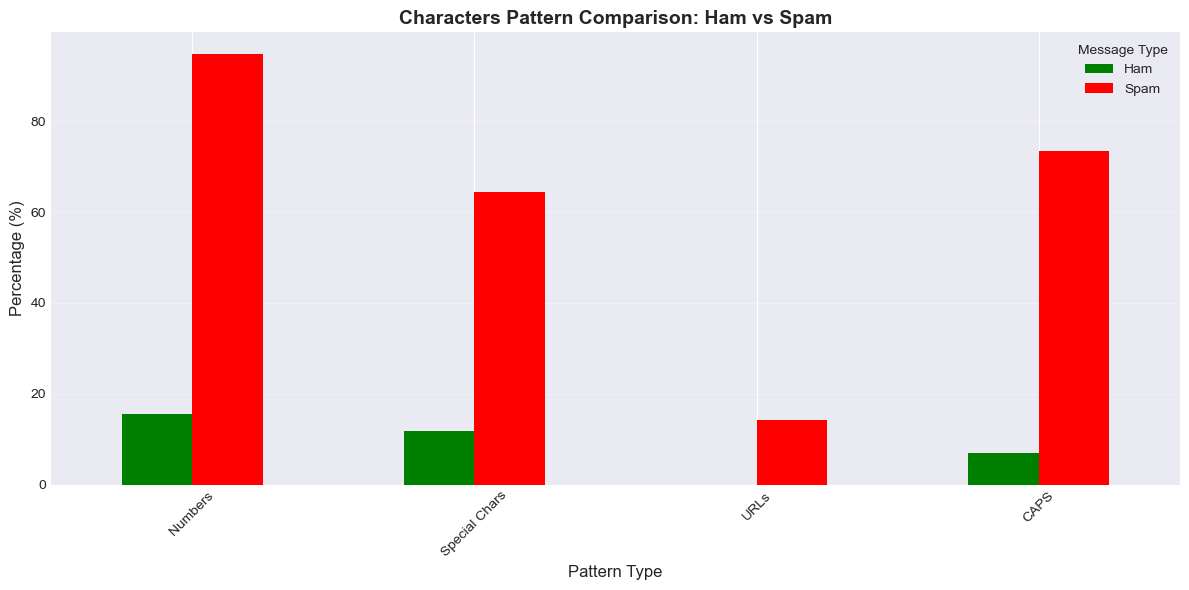

In [28]:
# Text Content Analysis
print('\n' + '=' * 70)
print('TEXT CONTENT ANALYSIS')
print('=' * 70 + '\n')

# Sample messages
print('SAMPLE HAM MESSAGES:')
ham_samples = spam[spam['label'] == 'ham']['message'].head()
for i, msg in enumerate(ham_samples, 1):
    print(f"{i}. {msg[:100]}..." if len(msg) > 100 else f"{i}. {msg}")
    print()

print('SAMPLE SPAM MESSAGES:')
spam_samples = spam[spam['label'] == 'spam']['message'].head()
for i, msg in enumerate(spam_samples, 1):
    print(f"{i}. {msg[:100]}..." if len(msg) > 100 else f"{i}. {msg}")
    print()

# Character Analysis
spam['has_numbers'] = spam['message'].str.contains(r'\d', regex = True)
spam['has_special_chars'] = spam['message'].str.contains(r'[!$£€]', regex = True)
spam['has_url'] = spam['message'].str.contains(r'http|www', case = False, regex = True)
spam['has_caps'] = spam['message'].str.contains(r'[A-Z]{3,}', regex = True)

print('CHARACTER PATTERNS BY TYPE:')
print('\nHAM MESSAGES:')
print(f"Contains numbers: {spam[spam['label'] == 'ham']['has_numbers'].sum()} ({spam[spam['label'] == 'ham']['has_numbers'].mean() * 100:.1f}%)")
print(f"Contains special chars (!$£€): {spam[spam['label'] == 'ham']['has_special_chars'].sum()} ({spam[spam['label'] == 'ham']['has_special_chars'].mean() * 100:.1f}%)")
print(f"Contains URLs: {spam[spam['label'] == 'ham']['has_url'].sum()} ({spam[spam['label'] == 'ham']['has_url'].mean() * 100:.1f}%)")
print(f"Contains CAPS (3+): {spam[spam['label'] == 'ham']['has_caps'].sum()} ({spam[spam['label'] == 'ham']['has_caps'].mean() * 100:.1f}%)")

print('\nSPAM MESSAGES:')
print(f"Contains numbers: {spam[spam['label'] == 'spam']['has_numbers'].sum()}  ({spam[spam['label'] == 'spam']['has_numbers'].mean() * 100:.1f}%)")
print(f"Contains special chars (!$£€): {spam[spam['label'] == 'spam']['has_special_chars'].sum()} ({spam[spam['label'] == 'spam']['has_special_chars'].mean() * 100:.1f}%)")
print(f"Contains URLs: {spam[spam['label'] == 'spam']['has_url'].sum()} ({spam[spam['label'] == 'spam']['has_url'].mean() * 100:.1f}%)")
print(f"Contains CAPS (3+): {spam[spam['label'] == 'spam']['has_caps'].sum()} ({spam[spam['label'] == 'spam']['has_caps'].mean() * 100:.1f}%)")

# Visualization
pattern_data = pd.DataFrame({
    'Ham': [spam[spam['label'] == 'ham']['has_numbers'].mean() * 100, 
            spam[spam['label'] == 'ham']['has_special_chars'].mean() * 100,
            spam[spam['label'] == 'ham']['has_url'].mean() * 100,
            spam[spam['label'] == 'ham']['has_caps'].mean() * 100],
    'Spam':[spam[spam['label'] == 'spam']['has_numbers'].mean() * 100, 
            spam[spam['label'] == 'spam']['has_special_chars'].mean() * 100,
            spam[spam['label'] == 'spam']['has_url'].mean() * 100,
            spam[spam['label'] == 'spam']['has_caps'].mean() * 100]
}, index = ['Numbers', 'Special Chars', 'URLs', 'CAPS'])

pattern_data.plot(kind = 'bar', figsize = (12, 6), color = ['green', 'red'])
plt.title('Characters Pattern Comparison: Ham vs Spam', fontsize = 14, fontweight = 'bold')
plt.xlabel('Pattern Type', fontsize = 12)
plt.ylabel('Percentage (%)', fontsize = 12)
plt.xticks(rotation = 45)
plt.legend(title = 'Message Type')
plt.grid(axis = 'y', alpha = 0.3)
plt.tight_layout()
plt.show()


WORD CLOUD VISUALIZATION



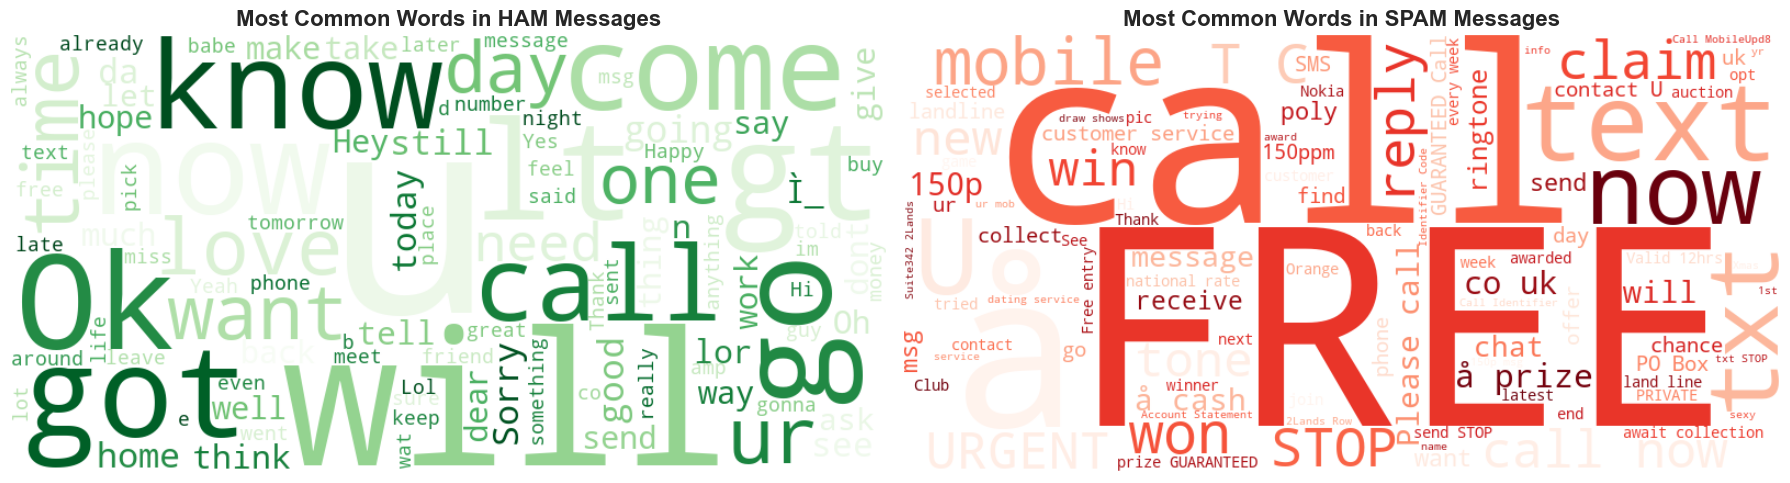

Word clouds generated successfully


In [29]:
# Word Cloud Visualization
print('\n' + '=' * 70)
print('WORD CLOUD VISUALIZATION')
print('=' * 70 + '\n')

try:
    from wordcloud import WordCloud, STOPWORDS

    # Prepare text
    ham_text = ' '.join(spam[spam['label'] == 'ham']['message'].values)
    spam_text = ' '.join(spam[spam['label'] == 'spam']['message'].values)

    # Create word clouds
    fig, axes = plt.subplots(1, 2, figsize = (18, 8))

    # Ham word cloud
    wordcloud_ham = WordCloud(width = 800, height = 400, background_color = 'white', stopwords = STOPWORDS, 
                              colormap = 'Greens', max_words = 100).generate(ham_text)
    axes[0].imshow(wordcloud_ham, interpolation = 'bilinear')
    axes[0].set_title('Most Common Words in HAM Messages', fontsize = 16, fontweight = 'bold')
    axes[0].axis('off')

    # Spam word cloud
    wordcloud_spam = WordCloud(width = 800, height = 400, background_color = 'white', stopwords = STOPWORDS,
                               colormap = 'Reds', max_words = 100).generate(spam_text)
    axes[1].imshow(wordcloud_spam, interpolation = 'bilinear')
    axes[1].set_title('Most Common Words in SPAM Messages', fontsize = 16, fontweight = 'bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    print('Word clouds generated successfully')

except ImportError:
    print('WordCloud library not installed.')
    print('To install: pip install wordcloud')
    print('Skipping word cloud visualization...')


MOST COMMON WORDS ANALYSIS

TOP 20 WORDS IN HAM MESSAGES:
 1. get             :  305
 2. how             :  304
 3. now             :  300
 4. just            :  293
 5. when            :  287
 6. what            :  273
 7. all             :  245
 8. know            :  236
 9. call            :  236
10. then            :  233
11. good            :  233
12. got             :  232
13. like            :  232
14. come            :  227
15. its             :  221
16. there           :  216
17. out             :  214
18. day             :  209
19. time            :  201
20. love            :  199

TOP 20 WORDS IN SPAM MESSAGES:
 1. call            :  355
 2. free            :  224
 3. now             :  199
 4. txt             :  163
 5. mobile          :  127
 6. text            :  125
 7. stop            :  121
 8. claim           :  113
 9. reply           :  104
10. www             :   98
11. prize           :   93
12. get             :   86
13. our             :   85
14. only          

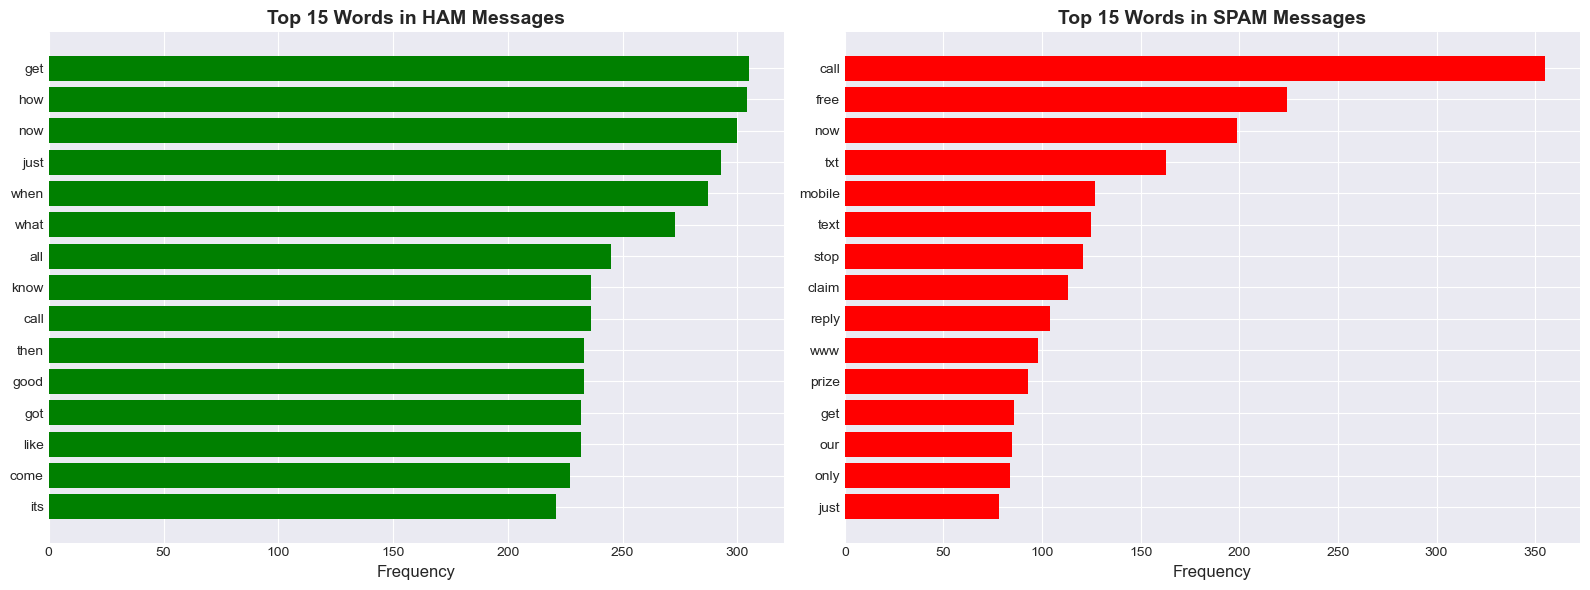

In [30]:
# Most Common Words Analysis
print('\n' + '=' * 70)
print('MOST COMMON WORDS ANALYSIS')
print('=' * 70 + '\n')

from collections import Counter
import re

def get_top_words(messages, n = 20):
    """Exact top N words from messages"""
    # Comine all messages
    all_text = ' '.join(messages)
    # Convert to lowercase and extract words
    words = re.findall(r'\b[a-z]{3,}\b', all_text.lower())
    # Remove common stopwords
    stopwords = {'the', 'and', 'to', 'of', 'for', 'you', 'in', 'is', 'that', 'it', 'on', 'with', 'was', 'are', 'this', 
                 'have', 'from', 'or', 'be', 'at', 'by', 'not', 'but', 'can', 'your', 'will', 'my', 'me', 'has'}
    words = [w for w in words if w not in stopwords]
    return Counter(words).most_common(n)

# Get top words for ham
print('TOP 20 WORDS IN HAM MESSAGES:')
ham_words = get_top_words(spam[spam['label'] == 'ham']['message'])
for i, (word, count) in enumerate(ham_words, 1):
    print(f"{i:2d}. {word:15s} : {count:4d}")

print("\nTOP 20 WORDS IN SPAM MESSAGES:")
spam_words = get_top_words(spam[spam['label'] == 'spam']['message'])
for i, (word, count) in enumerate(spam_words, 1):
    print(f"{i:2d}. {word:15s} : {count:4d}")

# Visualize top words
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# Ham top words
ham_words_df = pd.DataFrame(ham_words[:15], columns = ['word', 'count'])
axes[0].barh(ham_words_df['word'], ham_words_df['count'], color = 'green')
axes[0].set_xlabel('Frequency', fontsize = 12)
axes[0].set_title('Top 15 Words in HAM Messages', fontsize = 14, fontweight = 'bold')
axes[0].invert_yaxis()

# Spam top words
spam_words_df = pd.DataFrame(spam_words[:15], columns=['word', 'count'])
axes[1].barh(spam_words_df['word'], spam_words_df['count'], color='red')
axes[1].set_xlabel('Frequency', fontsize=12)
axes[1].set_title('Top 15 Words in SPAM Messages', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [31]:
# Summary Statistics - Spam Dataset
print("\n" + "="*70)
print("SPAM DATASET - COMPREHENSIVE SUMMARY")
print("="*70 + "\n")

summary_stats_spam = {
    'Total Messages': len(spam),
    'Ham Messages': (spam['label'] == 'ham').sum(),
    'Spam Messages': (spam['label'] == 'spam').sum(),
    'Spam Rate': f"{((spam['label'] == 'spam').sum() / len(spam) * 100):.2f}%",
    'Avg Message Length (Ham)': f"{spam[spam['label']=='ham']['message_length'].mean():.1f} chars",
    'Avg Message Length (Spam)': f"{spam[spam['label']=='spam']['message_length'].mean():.1f} chars",
    'Avg Word Count (Ham)': f"{spam[spam['label']=='ham']['word_count'].mean():.1f} words",
    'Avg Word Count (Spam)': f"{spam[spam['label']=='spam']['word_count'].mean():.1f} words",
    'Duplicate Messages': spam.duplicated().sum(),
    'Class Balance Ratio': f"{(spam['label']=='ham').sum() / (spam['label']=='spam').sum():.2f}:1"
}

print("KEY METRICS:")
for key, value in summary_stats_spam.items():
    print(f"{key}: {value}")


SPAM DATASET - COMPREHENSIVE SUMMARY

KEY METRICS:
Total Messages: 5572
Ham Messages: 4825
Spam Messages: 747
Spam Rate: 13.41%
Avg Message Length (Ham): 71.0 chars
Avg Message Length (Spam): 138.9 chars
Avg Word Count (Ham): 14.2 words
Avg Word Count (Spam): 23.9 words
Duplicate Messages: 403
Class Balance Ratio: 6.46:1


In [32]:
# Key Findins & Insights - Spam Dataset
print("\n" + "="*70)
print("KEY FINDINGS & INSIGHTS - SPAM DATASET")
print("="*70 + "\n")

print("DATA QUALITY:")
print(f"Clean dataset with no missing values")
print(f"{spam.duplicated().sum()} duplicate messages found")
print(f"Dataset has {len(spam):,} messages total")
print()

print("CLASS DISTRIBUTION:")
ham_pct = (spam['label']=='ham').sum() / len(spam) * 100
spam_pct = (spam['label']=='spam').sum() / len(spam) * 100
print(f"Ham: {ham_pct:.1f}% ({(spam['label']=='ham').sum():,} messages)")
print(f"Spam: {spam_pct:.1f}% ({(spam['label']=='spam').sum():,} messages)")
if abs(ham_pct - spam_pct) > 50:
    print(f"Highly imbalanced! Ham is {ham_pct/spam_pct:.1f}x more common")
else:
    print(f"Reasonably balanced distribution")
print()

print("MESSAGE LENGTH PATTERNS:")
ham_avg = spam[spam['label']=='ham']['message_length'].mean()
spam_avg = spam[spam['label']=='spam']['message_length'].mean()
print(f"Ham messages: avg {ham_avg:.0f} characters")
print(f"Spam messages: avg {spam_avg:.0f} characters")
if spam_avg > ham_avg:
    print(f"Spam messages are {((spam_avg/ham_avg - 1)*100):.1f}% longer")
else:
    print(f"Ham messages are {((ham_avg/spam_avg - 1)*100):.1f}% longer")
print()

print("DISTINCTIVE FEATURES:")
spam_numbers = spam[spam['label']=='spam']['has_numbers'].mean() * 100
ham_numbers = spam[spam['label']=='ham']['has_numbers'].mean() * 100
print(f"Numbers more common in {'spam' if spam_numbers > ham_numbers else 'ham'} ({max(spam_numbers, ham_numbers):.1f}% vs {min(spam_numbers, ham_numbers):.1f}%)")

spam_special = spam[spam['label']=='spam']['has_special_chars'].mean() * 100
ham_special = spam[spam['label']=='ham']['has_special_chars'].mean() * 100
print(f"Special chars (!$£€) more in {'spam' if spam_special > ham_special else 'ham'} ({max(spam_special, ham_special):.1f}% vs {min(spam_special, ham_special):.1f}%)")

spam_caps = spam[spam['label']=='spam']['has_caps'].mean() * 100
ham_caps = spam[spam['label']=='ham']['has_caps'].mean() * 100
print(f"CAPITAL letters more in {'spam' if spam_caps > ham_caps else 'ham'} ({max(spam_caps, ham_caps):.1f}% vs {min(spam_caps, ham_caps):.1f}%)")
print()

print("CONTENT PATTERNS:")
print(f"Spam often contains: 'free', 'win', 'call', 'prize', 'urgent'")
print(f"Ham often contains: casual conversation words")


KEY FINDINGS & INSIGHTS - SPAM DATASET

DATA QUALITY:
Clean dataset with no missing values
403 duplicate messages found
Dataset has 5,572 messages total

CLASS DISTRIBUTION:
Ham: 86.6% (4,825 messages)
Spam: 13.4% (747 messages)
Highly imbalanced! Ham is 6.5x more common

MESSAGE LENGTH PATTERNS:
Ham messages: avg 71 characters
Spam messages: avg 139 characters
Spam messages are 95.5% longer

DISTINCTIVE FEATURES:
Numbers more common in spam (94.8% vs 15.5%)
Special chars (!$£€) more in spam (64.4% vs 11.9%)
CAPITAL letters more in spam (73.5% vs 7.1%)

CONTENT PATTERNS:
Spam often contains: 'free', 'win', 'call', 'prize', 'urgent'
Ham often contains: casual conversation words


In [33]:
# Saved Processed Spam Data
print("\n" + "="*70)
print("SAVE PROCESSED DATA")
print("="*70 + "\n")

# Save cleaned dataset
output_path_spam = '../data/processed/spam_explored.csv'

try:
    spam.to_csv(output_path_spam, index=False)
    print(f"Cleaned spam dataset saved to: {output_path_spam}")
    print(f"Columns: {list(spam.columns)}")
    print(f"Shape: {spam.shape}")
except Exception as e:
    print(f"Could not save file: {e}")

print("\n" + "="*70)
print("SPAM DATASET EXPLORATION COMPLETE!")
print("="*70)
print("\nDataset Summary:")
print(f"{len(spam):,} total messages")
print(f"{(spam['label']=='spam').sum():,} spam messages")
print(f"{(spam['label']=='ham').sum():,} ham messages")
print(f"{len(spam.columns)} features created")


SAVE PROCESSED DATA

Cleaned spam dataset saved to: ../data/processed/spam_explored.csv
Columns: ['label', 'message', 'message_length', 'word_count', 'has_numbers', 'has_special_chars', 'has_url', 'has_caps']
Shape: (5572, 8)

SPAM DATASET EXPLORATION COMPLETE!

Dataset Summary:
5,572 total messages
747 spam messages
4,825 ham messages
8 features created


# Dataset 3: Reviews

In [34]:
# Load the reviews dataset
reviews_file_path = '/Users/vishalhooda/Documents/Intelligent-Customer-Support/data/raw/Reviews.csv'

try:
    reviews = pd.read_csv(reviews_file_path)
    print('Reviews dataset loaded successfully')
    print(f"Dataset shape: {reviews.shape}")
except FileNotFoundError:
    print('File not found')
    print('Please make sure this file is at: data/raw/reviews.csv')
except Exception as e:
    print(f"Error loading file: {e}")

Reviews dataset loaded successfully
Dataset shape: (568454, 10)


In [35]:
# Initial Data Inspection
print('\n' + '=' * 70)
print('INITIAL DATA INSPECTION')
print('=' * 70 + '\n')

# Display basic info
print(f"Total Reviews: {len(reviews):,}")
print(f"Total Columns: {len(reviews.columns)}")
print(f"Date Range: {pd.to_datetime(reviews['Time'], unit = 's').min()} to {pd.to_datetime(reviews['Time'], unit = 's').max()}")

# Display first few rows
print('\nFIRST 5 ROWS:')
print(reviews.head())

# Display last few rows
print('\nLAST 5 ROWS:')
print(reviews.tail())

print('\n' + '=' * 70)

# Column names
print('\nCOLUMN NAMES:')
for i, col in enumerate(reviews.columns, 1):
    print(f"{i:2d}. {col}")

print('\n' + '=' * 70)

# Data types
print('\nDATA TYPES:')
print(reviews.dtypes)

print('\n' + '=' * 70)

# Detailed info
print('\nDETAILED INFO:')
reviews.info()


INITIAL DATA INSPECTION

Total Reviews: 568,454
Total Columns: 10
Date Range: 1999-10-08 00:00:00 to 2012-10-26 00:00:00

FIRST 5 ROWS:
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summ


MISSING VALUES ANALYSIS

COLUMNS WITH MISSING VALUES:
     Column  Missing Count  Missing Percentage
    Summary             27               0.005
ProfileName             26               0.005

Summary: 27 missing (0.0047%)
ProfileName: 26 missing (0.0046%)


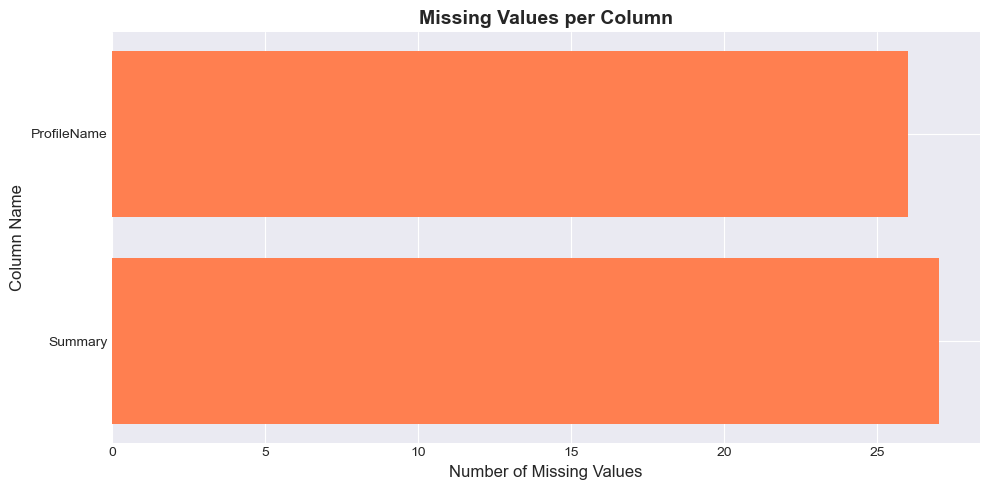


DUPLICATE ROWS: 0
DUPLICATE REVIEW IDs: 0


In [36]:
# Missing Values Analysis
print('\n' + '=' * 70)
print('MISSING VALUES ANALYSIS')
print('=' * 70 + '\n')

# Calculate missing values
missing_counts = reviews.isnull().sum()
missing_percent = (missing_counts / len(reviews)) * 100

missing_df = pd.DataFrame({
    'Column' : missing_counts.index,
    'Missing Count' : missing_counts.values,
    'Missing Percentage' : missing_percent.values
}).sort_values('Missing Count', ascending = False)

# Display only columns with missing values
missing_with_nulls = missing_df[missing_df['Missing Count'] > 0]

if len(missing_with_nulls) > 0:
    print('COLUMNS WITH MISSING VALUES:')
    print(missing_with_nulls.to_string(index = False))
    print()

    # Analysis
    for idx, row in missing_with_nulls.iterrows():
        col_name = row['Column']
        missing_count = row['Missing Count']
        missing_pct = row['Missing Percentage']
        print(f"{col_name}: {missing_count:,} missing ({missing_pct:.4f}%)")
else:
    print('No missing values found')

# Visualization
if len(missing_with_nulls) > 0:
    plt.figure(figsize = (10, 5))
    plt.barh(missing_with_nulls['Column'], missing_with_nulls['Missing Count'], color = 'coral')
    plt.xlabel('Number of Missing Values', fontsize = 12)
    plt.ylabel('Column Name', fontsize = 12)
    plt.title('Missing Values per Column', fontsize = 14, fontweight = 'bold')
    plt.tight_layout()
    plt.show()

# Check for duplicates
print(f"\nDUPLICATE ROWS: {reviews.duplicated().sum():,}")

# Check duplicate review IDs
duplicate_ids = reviews['Id'].duplicated().sum()
print(f"DUPLICATE REVIEW IDs: {duplicate_ids}")


SCORE DISTRIBUTION ANALYSIS

SCORE STATISTICS:
count   568454.000
mean         4.183
std          1.310
min          1.000
25%          4.000
50%          5.000
75%          5.000
max          5.000
Name: Score, dtype: float64

SCORE DISTRIBUTION:
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64

SCORE PERCENTAGES:
1 star: 52,268 (9.19%)
2 stars: 29,769 (5.24%)
3 stars: 42,640 (7.50%)
4 stars: 80,655 (14.19%)
5 stars: 363,122 (63.88%)

AVERAGE SCORE: 4.18/5.0
MEDIAN SCORE: 5.0/5.0

SENTIMENT DISTRIBUTION:
Sentiment
Positive    443777
Negative     82037
Neutral      42640
Name: count, dtype: int64
Positive: 78.07%
Negative: 14.43%
Neutral: 7.50%


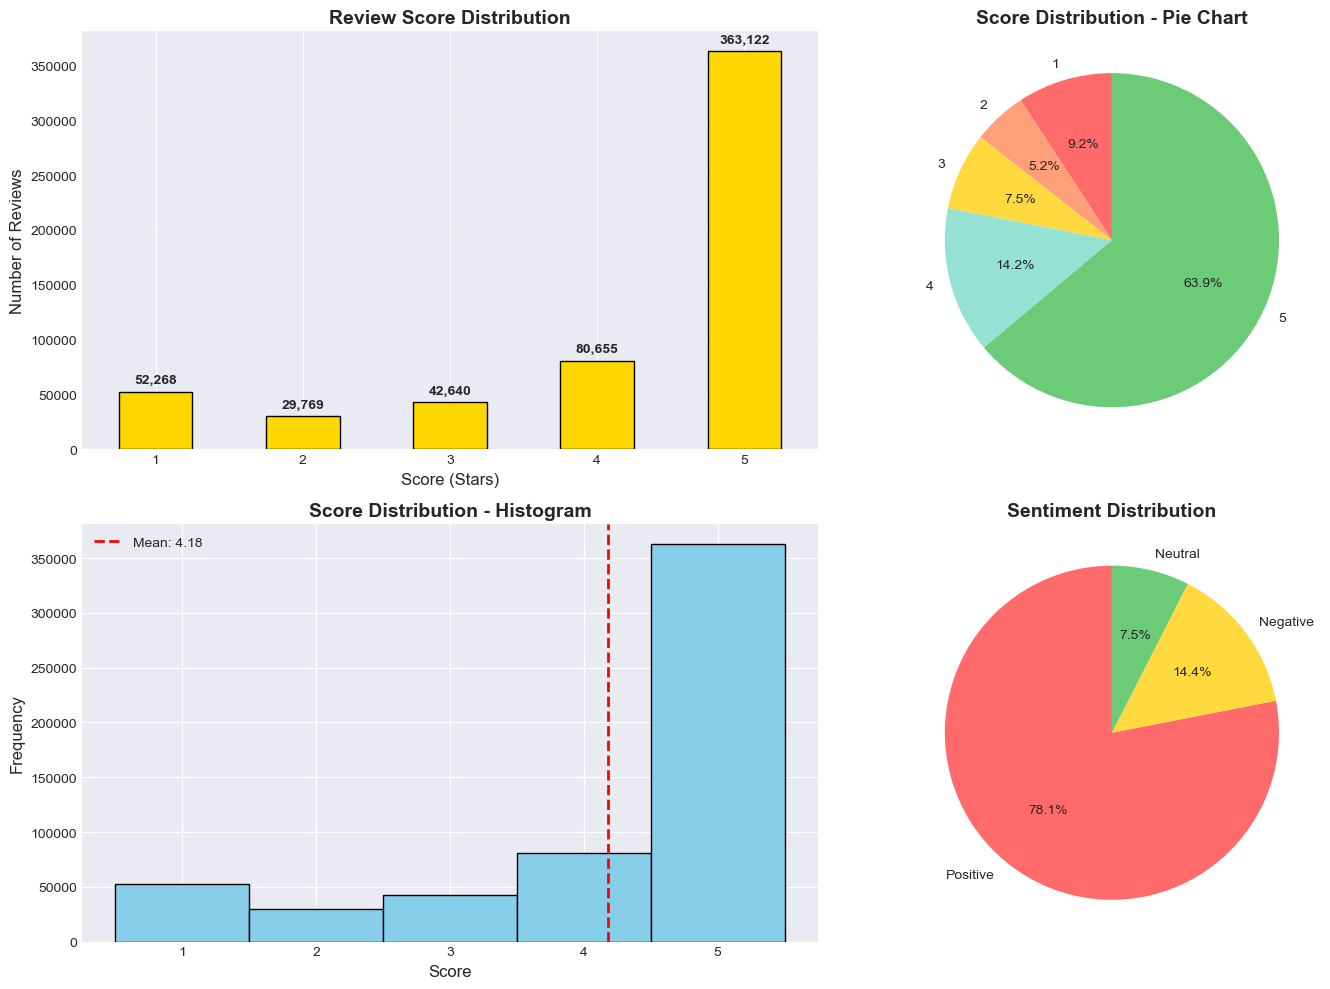

In [37]:
# Score Distribution Analysis
print('\n' + '=' * 70)
print('SCORE DISTRIBUTION ANALYSIS')
print('=' * 70 + '\n')

# Score statistics
print('SCORE STATISTICS:')
print(reviews['Score'].describe())
print()

# Score counts
print('SCORE DISTRIBUTION:')
score_counts = reviews['Score'].value_counts().sort_index()
print(score_counts)
print()

# Calculate percentages
total_reviews = len(reviews)
print('SCORE PERCENTAGES:')
for score in sorted(reviews['Score'].unique()):
    count = (reviews['Score'] == score).sum()
    pct = (count / total_reviews) * 100
    print(f"{score} star{'s' if score != 1 else ''}: {count:,} ({pct:.2f}%)")

# Average score
avg_score = reviews['Score'].mean()
median_score = reviews['Score'].median()
print(f"\nAVERAGE SCORE: {avg_score:.2f}/5.0")
print(f"MEDIAN SCORE: {median_score:.1f}/5.0")

# Sentiment classification
reviews['Sentiment'] = reviews['Score'].apply(lambda x: 'Positive' if x >= 4 else ('Neutral' if x == 3 else 'Negative'))

sentiment_counts = reviews['Sentiment'].value_counts()
print(f"\nSENTIMENT DISTRIBUTION:")
print(sentiment_counts)
for sentiment, count in sentiment_counts.items():
    pct = (count / total_reviews) * 100
    print(f"{sentiment}: {pct:.2f}%")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize = (15, 10))

# Bar chart - Scores
score_counts.plot(kind = 'bar', ax = axes[0, 0], color = 'gold', edgecolor = 'black')
axes[0, 0].set_title('Review Score Distribution', fontsize = 14, fontweight = 'bold')
axes[0, 0].set_xlabel('Score (Stars)', fontsize = 12)
axes[0, 0].set_ylabel('Number of Reviews', fontsize = 12)
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation = 0)
axes[0, 0].grid(axis = 'y', alpha = 0.3)

# Add count labels
for i, v in enumerate(score_counts.values):
    axes[0, 0].text(i, v + 5000, f"{v:,}", ha = 'center', va = 'bottom', fontweight = 'bold')

# Pie chart - Scores
axes[0, 1].pie(score_counts, labels = [f"{score}" for score in score_counts.index], autopct = '%1.1f%%',
               startangle = 90, colors = ['#FF6B6B', '#FFA07A', '#FFD93D', '#95E1D3', '#6BCB77'])
axes[0, 1].set_title('Score Distribution - Pie Chart', fontsize = 14, fontweight = 'bold')

# Histogram
axes[1, 0].hist(reviews['Score'], bins = 5, color = 'skyblue', edgecolor = 'black', range = (0.5, 5.5))
axes[1, 0].set_title('Score Distribution - Histogram', fontsize = 14, fontweight = 'bold')
axes[1, 0].set_xlabel('Score', fontsize = 12)
axes[1, 0].set_ylabel('Frequency', fontsize = 12)
axes[1, 0].axvline(avg_score, color = 'red', linestyle = '--', linewidth = 2, label = f"Mean: {avg_score:.2f}")
axes[1, 0].legend()

# Sentiment pic chart
sentiment_counts.plot(kind = 'pie', ax = axes[1, 1], autopct = '%1.1f%%', startangle = 90, 
                      colors = ['#FF6B6B', '#FFD93D', '#6BCB77'])
axes[1, 1].set_title('Sentiment Distribution', fontsize = 14, fontweight = 'bold')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()


HELPFULNESS ANALYSIS

HELPFULNESS NUMERATOR STATISTICS:
count   568454.000
mean         1.744
std          7.637
min          0.000
25%          0.000
50%          0.000
75%          2.000
max        866.000
Name: HelpfulnessNumerator, dtype: float64

HELFULNESS DENOMINATOR STATISTICS:
count   568454.000
mean         2.229
std          8.290
min          0.000
25%          0.000
50%          1.000
75%          2.000
max        923.000
Name: HelpfulnessDenominator, dtype: float64

HELPFULNESS RATIO STATISTICS:
count   298402.000
mean         0.777
std          0.346
min          0.000
25%          0.600
50%          1.000
75%          1.000
max          3.000
Name: Helpfulness Ratio, dtype: float64

REVIEWS WITH HELPFULNESS VOTES:
Total: 298,402 (52.49%)
Without votes: 270,052 (47.51%)

AVERAGE HELPFULNESS BY SCORE:
Score
1   0.539
2   0.566
3   0.626
4   0.791
5   0.872
Name: Helpfulness Ratio, dtype: float64


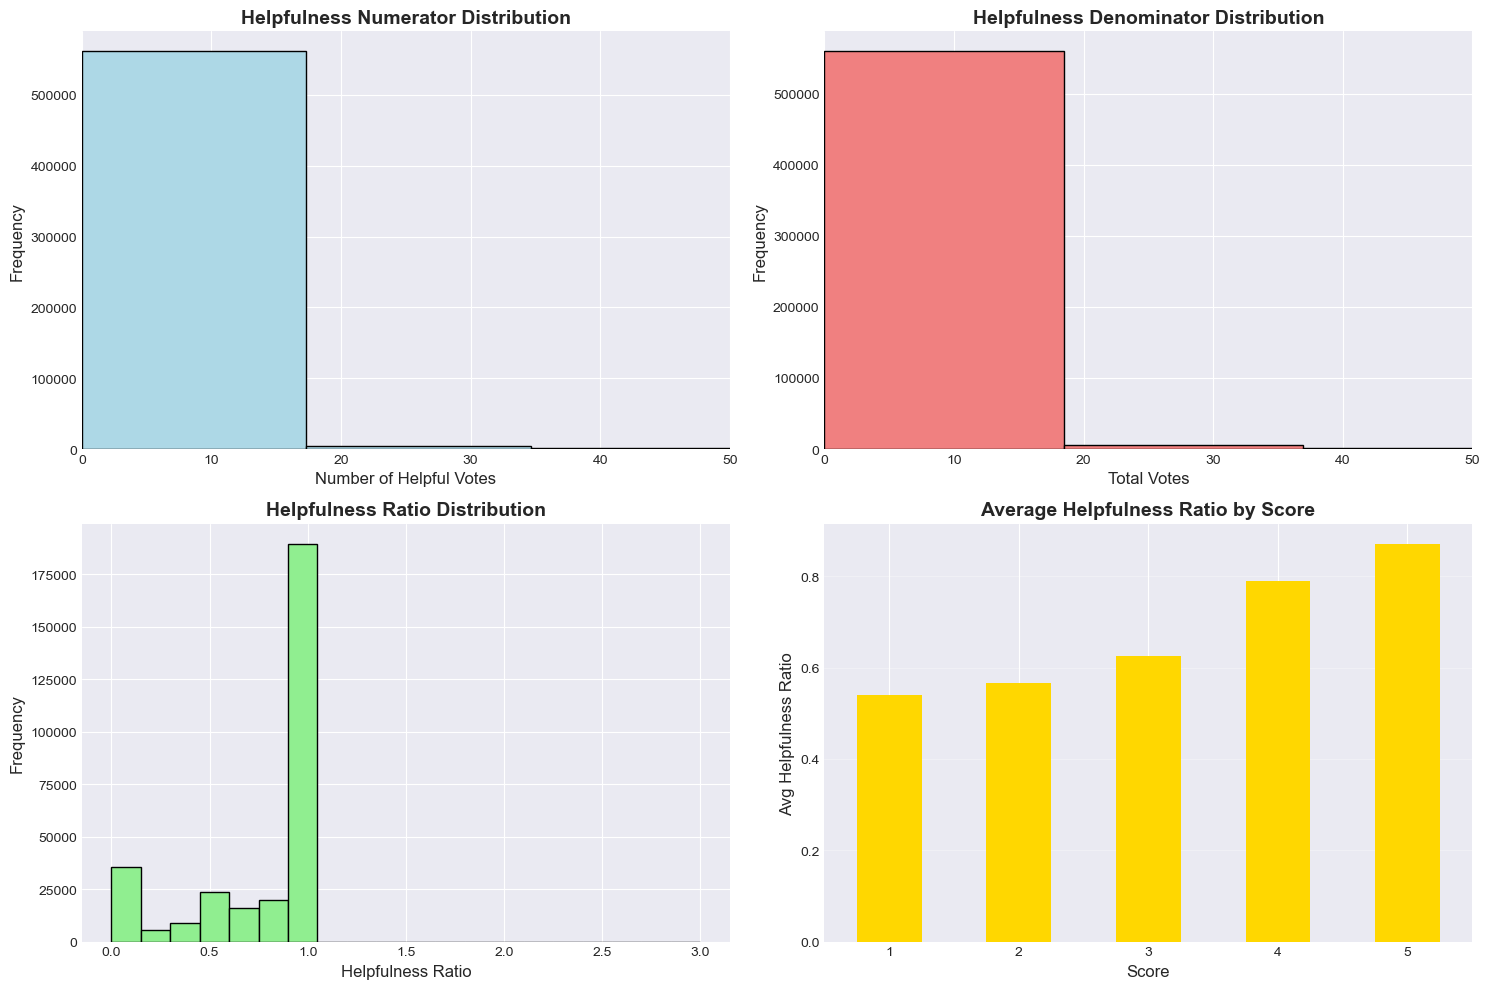

In [38]:
# Helpfulness Analysis
print('\n' + '=' * 70)
print('HELPFULNESS ANALYSIS')
print('=' * 70 + '\n')

# Helpfulness statistics
print('HELPFULNESS NUMERATOR STATISTICS:')
print(reviews['HelpfulnessNumerator'].describe())
print()

print('HELFULNESS DENOMINATOR STATISTICS:')
print(reviews['HelpfulnessDenominator'].describe())
print()

# Calculate helpfulness ratio 
reviews['Helpfulness Ratio'] = reviews.apply(lambda row: row['HelpfulnessNumerator'] / 
                                             row['HelpfulnessDenominator'] if row['HelpfulnessDenominator'] > 0 else 0, axis = 1)

print("HELPFULNESS RATIO STATISTICS:")
print(reviews[reviews['HelpfulnessDenominator'] > 0]['Helpfulness Ratio'].describe())
print()

# Count reviews with votes
reviews_with_votes = (reviews['HelpfulnessDenominator'] > 0).sum()
print(f"REVIEWS WITH HELPFULNESS VOTES:")
print(f"Total: {reviews_with_votes:,} ({(reviews_with_votes / len(reviews) * 100):.2f}%)")
print(f"Without votes: {len(reviews) - reviews_with_votes:,} ({((len(reviews) - reviews_with_votes) / len(reviews) * 100):.2f}%)")

# Helpfulness by score
print('\nAVERAGE HELPFULNESS BY SCORE:')
helpfulness_by_score = reviews[reviews['HelpfulnessDenominator'] > 0].groupby('Score')['Helpfulness Ratio'].mean()
print(helpfulness_by_score)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Helpfulness Numerator distribution
axes[0, 0].hist(reviews['HelpfulnessNumerator'], bins=50, color='lightblue', edgecolor='black')
axes[0, 0].set_title('Helpfulness Numerator Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Helpful Votes', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_xlim(0, 50)

# Helpfulness Denominator distribution
axes[0, 1].hist(reviews['HelpfulnessDenominator'], bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Helpfulness Denominator Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Total Votes', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_xlim(0, 50)

# Helpfulness ratio distribution
axes[1, 0].hist(reviews[reviews['HelpfulnessDenominator'] > 0]['Helpfulness Ratio'], 
                bins=20, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Helpfulness Ratio Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Helpfulness Ratio', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)

# Helpfulness by score
helpfulness_by_score.plot(kind='bar', ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Average Helpfulness Ratio by Score', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Score', fontsize=12)
axes[1, 1].set_ylabel('Avg Helpfulness Ratio', fontsize=12)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


TEXT CONTENT ANALYSIS

SUMMARY LENGTH STATISTICS (Characters):
count   568454.000
mean        23.446
std         14.029
min          0.000
25%         13.000
50%         20.000
75%         30.000
max        128.000
Name: Summary Length, dtype: float64

REVIEW TEXT LENGTH SATISTICS (Characters):
count   568454.000
mean       436.222
std        445.340
min         12.000
25%        179.000
50%        302.000
75%        527.000
max      21409.000
Name: Text Length, dtype: float64

SUMMARY WORD COUNT STATISTICS:
count   568454.000
mean         4.113
std          2.597
min          0.000
25%          2.000
50%          4.000
75%          5.000
max         42.000
Name: Summary Words, dtype: float64

REVIEW TEXT WORD COUNT STATISTICS:
count   568454.000
mean        80.264
std         79.455
min          3.000
25%         33.000
50%         56.000
75%         98.000
max       3432.000
Name: Text Words, dtype: float64

AVERAGE TEXT LENGTH BY SCORE:
       Summary Length  Text Length  Summary W

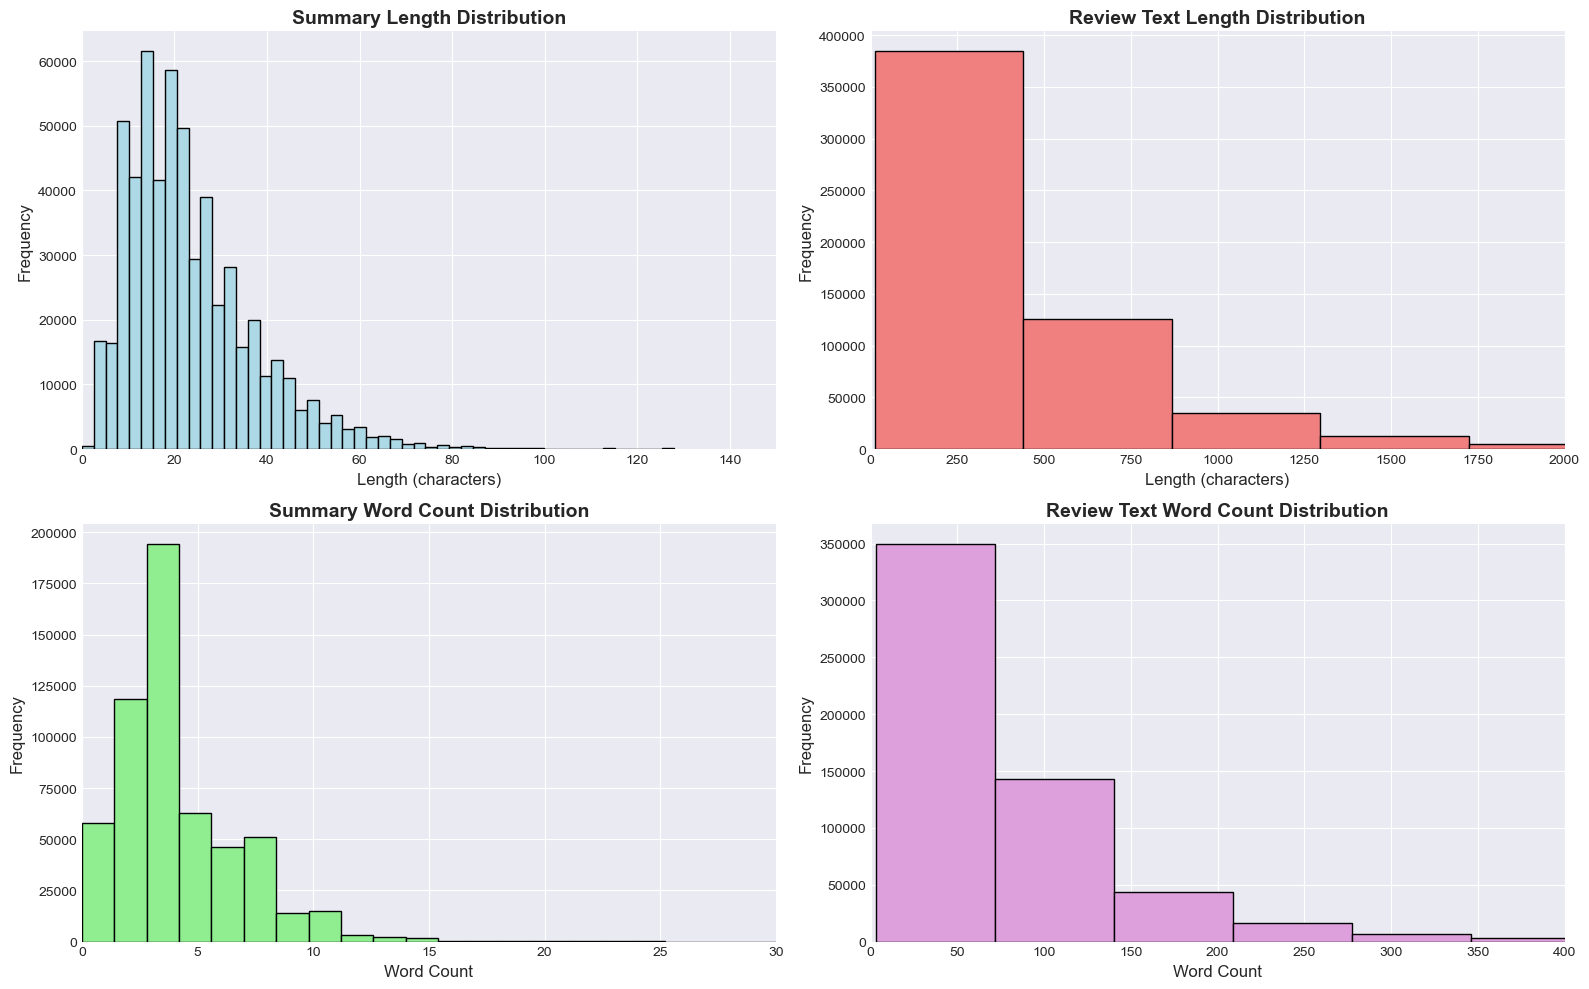

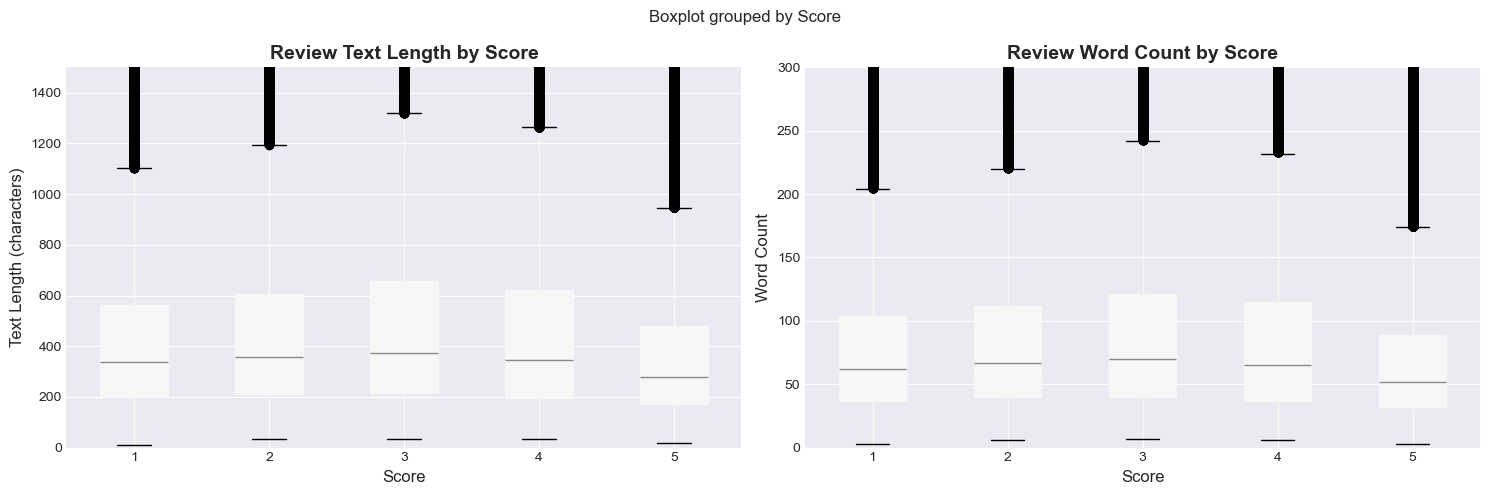

In [39]:
# Text Content Analysis
print('\n' + '=' * 70)
print('TEXT CONTENT ANALYSIS')
print('=' * 70 + '\n')

# Calculate text lengths
reviews['Summary Length'] = reviews['Summary'].fillna('').str.len()
reviews['Text Length'] = reviews['Text'].fillna('').str.len()
reviews['Summary Words'] = reviews['Summary'].fillna('').str.split().str.len()
reviews['Text Words'] = reviews['Text'].fillna('').str.split().str.len()

# Summary statistics
print('SUMMARY LENGTH STATISTICS (Characters):')
print(reviews['Summary Length'].describe())
print()

print('REVIEW TEXT LENGTH SATISTICS (Characters):')
print(reviews['Text Length'].describe())
print()

print('SUMMARY WORD COUNT STATISTICS:')
print(reviews['Summary Words'].describe())
print()

print('REVIEW TEXT WORD COUNT STATISTICS:')
print(reviews['Text Words'].describe())
print()

# Text length by score
print('AVERAGE TEXT LENGTH BY SCORE:')
text_by_score = reviews.groupby('Score')[['Summary Length', 'Text Length', 'Summary Words', 'Text Words']].mean()
print(text_by_score)
print()

# Sample reviews
print('SAMPLE 5-STAR REVIEWS:')
five_star = reviews[reviews['Score'] == 5].head(3)
for idx, row in five_star.iterrows():
    print(f"\n{row['Summary']}")
    print(f"{row['Text'][:150]}...")

print('\nSAMPLE 1-STAR REVEIWS:')
one_star = reviews[reviews['Score'] == 1].head(3)
for idx, row in one_star.iterrows():
    print(f"\n{row['Summary']}")
    print(f"{row['Text'][:150]}...")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize = (16, 10))

# Summary length distribution
axes[0, 0].hist(reviews['Summary Length'], bins = 50, color = 'lightblue', edgecolor = 'black')
axes[0, 0].set_title('Summary Length Distribution', fontsize = 14, fontweight = 'bold')
axes[0, 0].set_xlabel('Length (characters)', fontsize = 12)
axes[0, 0].set_ylabel('Frequency', fontsize = 12)
axes[0, 0].set_xlim(0, 150)

# Text length distribution
axes[0, 1].hist(reviews['Text Length'], bins = 50, color = 'lightcoral', edgecolor = 'black')
axes[0, 1].set_title('Review Text Length Distribution', fontsize = 14, fontweight = 'bold')
axes[0, 1].set_xlabel('Length (characters)', fontsize = 12)
axes[0, 1].set_ylabel('Frequency', fontsize = 12)
axes[0, 1].set_xlim(0, 2000)

# Summary words distribution
axes[1, 0].hist(reviews['Summary Words'], bins = 30, color = 'lightgreen', edgecolor = 'black')
axes[1, 0].set_title('Summary Word Count Distribution', fontsize = 14, fontweight = 'bold')
axes[1, 0].set_xlabel('Word Count', fontsize = 12)
axes[1, 0].set_ylabel('Frequency', fontsize = 12)
axes[1, 0].set_xlim(0, 30)

# Text words distribution
axes[1, 1].hist(reviews['Text Words'], bins = 50, color = 'plum', edgecolor = 'black')
axes[1, 1].set_title('Review Text Word Count Distribution', fontsize = 14, fontweight = 'bold')
axes[1, 1].set_xlabel('Word Count', fontsize = 12)
axes[1, 1].set_ylabel('Frequency', fontsize = 12)
axes[1, 1].set_xlim(0, 400)

plt.tight_layout()
plt.show()

# Text length by score
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

# Box plot - Text length by score
reviews.boxplot(column = 'Text Length', by = 'Score', ax = axes[0], patch_artist = True)
axes[0].set_title('Review Text Length by Score', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Score', fontsize = 12)
axes[0].set_ylabel('Text Length (characters)', fontsize = 12)
axes[0].set_ylim(0, 1500)

# Box plot - Word Count by score
reviews.boxplot(column = 'Text Words', by = 'Score', ax = axes[1], patch_artist = True)
axes[1].set_title('Review Word Count by Score', fontsize = 14, fontweight = 'bold')
axes[1].set_xlabel('Score', fontsize = 12)
axes[1].set_ylabel('Word Count', fontsize = 12)
axes[1].set_ylim(0, 300)

plt.tight_layout()
plt.show()


TEMPORAL ANALYSIS

DATE RANGE:
Earliest review: 1999-10-08 00:00:00
Latest review: 2012-10-26 00:00:00
Span: 4767 days

REVIEWS BY YEAR:
Year
1999         6
2000        32
2001        13
2002        73
2003       132
2004       561
2005      1335
2006      6671
2007     22300
2008     34163
2009     55326
2010     85884
2011    163299
2012    198659
Name: count, dtype: int64

REVIEWS BY MONTH:
Jan: 50,367
Feb: 45,356
Mar: 48,367
Apr: 44,473
May: 46,226
Jun: 44,479
Jul: 48,419
Aug: 50,526
Sep: 55,740
Oct: 55,762
Nov: 36,986
Dec: 41,753

REVIEWS BY DAY OF WEEK:
DayOfWeek
Monday       85363
Tuesday      85857
Wednesday    85994
Thursday     87078
Friday       79682
Saturday     71689
Sunday       72791
Name: count, dtype: int64


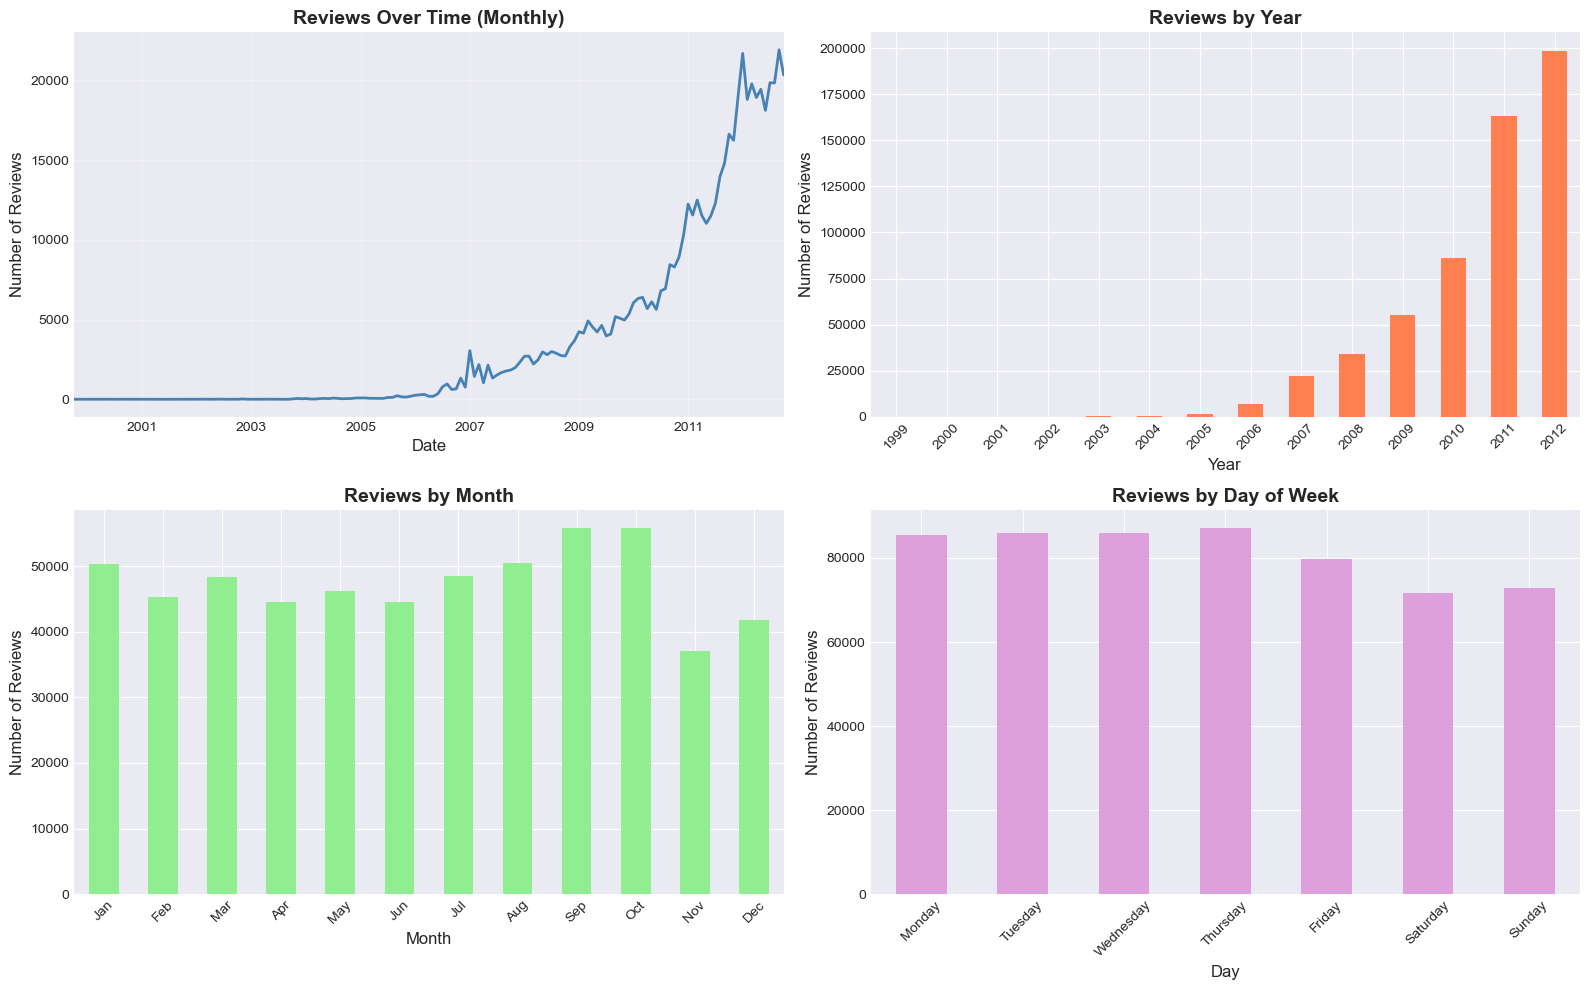


AVERAGE SCORE BY YEAR:
Year
1999   5.000
2000   4.531
2001   3.538
2002   4.712
2003   4.326
2004   4.392
2005   4.446
2006   4.313
2007   4.391
2008   4.345
2009   4.300
2010   4.199
2011   4.144
2012   4.118
Name: Score, dtype: float64


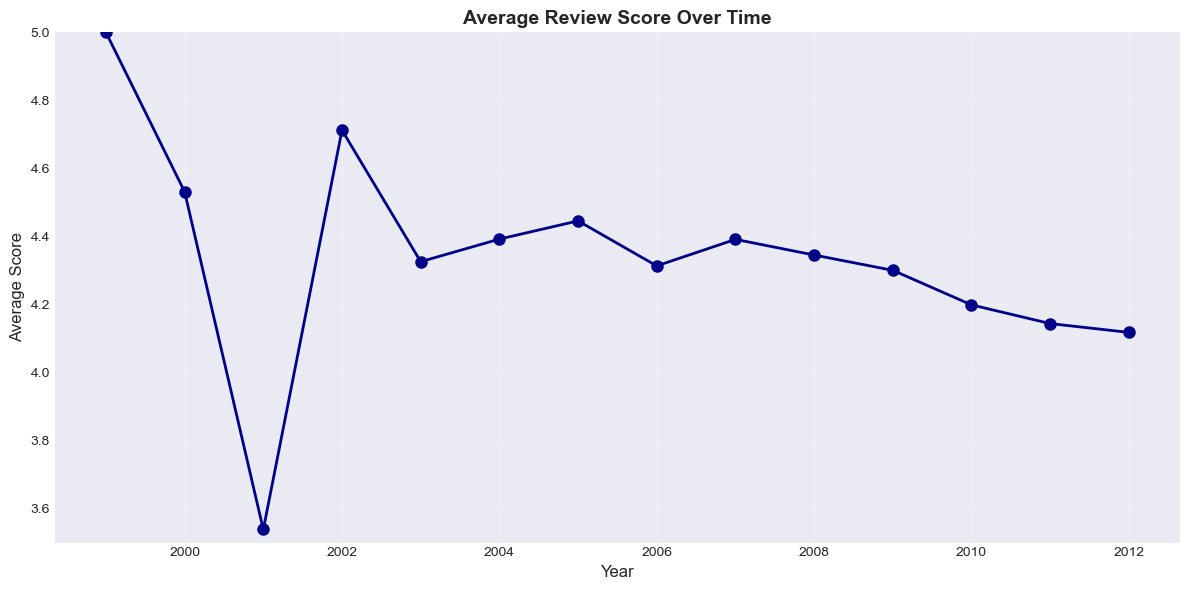

In [40]:
# Temporal Analysis
print('\n' + '=' * 70)
print('TEMPORAL ANALYSIS')
print('=' * 70 + '\n')

# Convert timestamp to datetime
reviews['DateTime'] = pd.to_datetime(reviews['Time'], unit = 's')
reviews['Year'] = reviews['DateTime'].dt.year
reviews['Month'] = reviews['DateTime'].dt.month
reviews['DayOfWeek'] = reviews['DateTime'].dt.day_name()
reviews['Hour'] = reviews['DateTime'].dt.hour

print('DATE RANGE:')
print(f"Earliest review: {reviews['DateTime'].min()}")
print(f"Latest review: {reviews['DateTime'].max()}")
print(f"Span: {(reviews['DateTime'].max() - reviews['DateTime'].min()).days} days")
print()

# Reviews by year
print('REVIEWS BY YEAR:')
year_counts = reviews['Year'].value_counts().sort_index()
print(year_counts)
print()

# Reviews by month
print('REVIEWS BY MONTH:')
month_counts = reviews['Month'].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for month, count in month_counts.items():
    print(f"{month_names[month-1]}: {count:,}")
print()

# Reviews by day of week
print('REVIEWS BY DAY OF WEEK:')
dow_counts = reviews['DayOfWeek'].value_counts()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = dow_counts.reindex([d for d in dow_order if d in dow_counts.index])
print(dow_counts)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize = (16, 10))

# Reviews over time
reviews_timeline = reviews.groupby(reviews['DateTime'].dt.to_period('M')).size()
reviews_timeline.plot(ax = axes[0, 0], color = 'steelblue', linewidth = 2)
axes[0, 0].set_title('Reviews Over Time (Monthly)', fontsize = 14, fontweight = 'bold')
axes[0, 0].set_xlabel('Date', fontsize = 12)
axes[0, 0].set_ylabel('Number of Reviews', fontsize = 12)
axes[0, 0].grid(alpha = 0.3)

# Reviews by year
year_counts.plot(kind = 'bar', ax = axes[0, 1], color = 'coral')
axes[0, 1].set_title('Reviews by Year', fontsize = 14, fontweight = 'bold')
axes[0, 1].set_xlabel('Year', fontsize = 12)
axes[0, 1].set_ylabel('Number of Reviews', fontsize = 12)
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation = 45)

# Reviews by month
month_counts.plot(kind = 'bar', ax = axes[1, 0], color = 'lightgreen')
axes[1, 0].set_title('Reviews by Month', fontsize = 14, fontweight = 'bold')
axes[1, 0].set_xlabel('Month', fontsize = 12)
axes[1, 0].set_ylabel('Number of Reviews', fontsize = 12)
axes[1, 0].set_xticklabels(month_names, rotation = 45)

# Reviews by day of week
dow_counts.plot(kind = 'bar', ax = axes[1, 1], color = 'plum')
axes[1, 1].set_title('Reviews by Day of Week', fontsize = 14, fontweight = 'bold')
axes[1, 1].set_xlabel('Day', fontsize = 12)
axes[1, 1].set_ylabel('Number of Reviews', fontsize = 12)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation = 45)

plt.tight_layout()
plt.show()

# Average score over time
print('\nAVERAGE SCORE BY YEAR:')
avg_score_by_year = reviews.groupby('Year')['Score'].mean()
print(avg_score_by_year)

plt.figure(figsize = (12, 6))
avg_score_by_year.plot(kind = 'line', marker = 'o', linewidth = 2, markersize = 8, color = 'darkblue')
plt.title('Average Review Score Over Time', fontsize = 14, fontweight = 'bold')
plt.xlabel('Year', fontsize = 12)
plt.ylabel('Average Score', fontsize = 12)
plt.ylim(3.5, 5.0)
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()


USER & PRODUCT ANALYSIS

UNIQUE COUNTS:
Unique Users: 256,059
Unique Products: 74,258
Unique Profile Names: 218,415

REVIEWS PER USER STATISTICS:
count   256059.000
mean         2.220
std          4.443
min          1.000
25%          1.000
50%          1.000
75%          2.000
max        448.000
dtype: float64

TOP 10 MOST ACTIVE REVIEWERS:
 1. C. F. Hill "CFH": 451 reviews
 2. O. Brown "Ms. O. Khannah-Brown": 421 reviews
 3. Gary Peterson: 389 reviews
 4. Rebecca of Amazon "The Rebecca Review": 365 reviews
 5. Chris: 363 reviews
 6. Linda: 290 reviews
 7. John: 261 reviews
 8. Mike: 260 reviews
 9. c2: 256 reviews
10. Laura: 253 reviews

REVIEWS PER PRODUCT STATISTICS:
count   74258.000
mean        7.655
std        26.453
min         1.000
25%         1.000
50%         2.000
75%         5.000
max       913.000
dtype: float64

TOP 10 MOST REVIEWED PRODUCTS:
 1. B007JFMH8M: 913 reviews
 2. B0026RQTGE: 632 reviews
 3. B002QWHJOU: 632 reviews
 4. B002QWP89S: 632 reviews
 5. B002QWP8H0: 

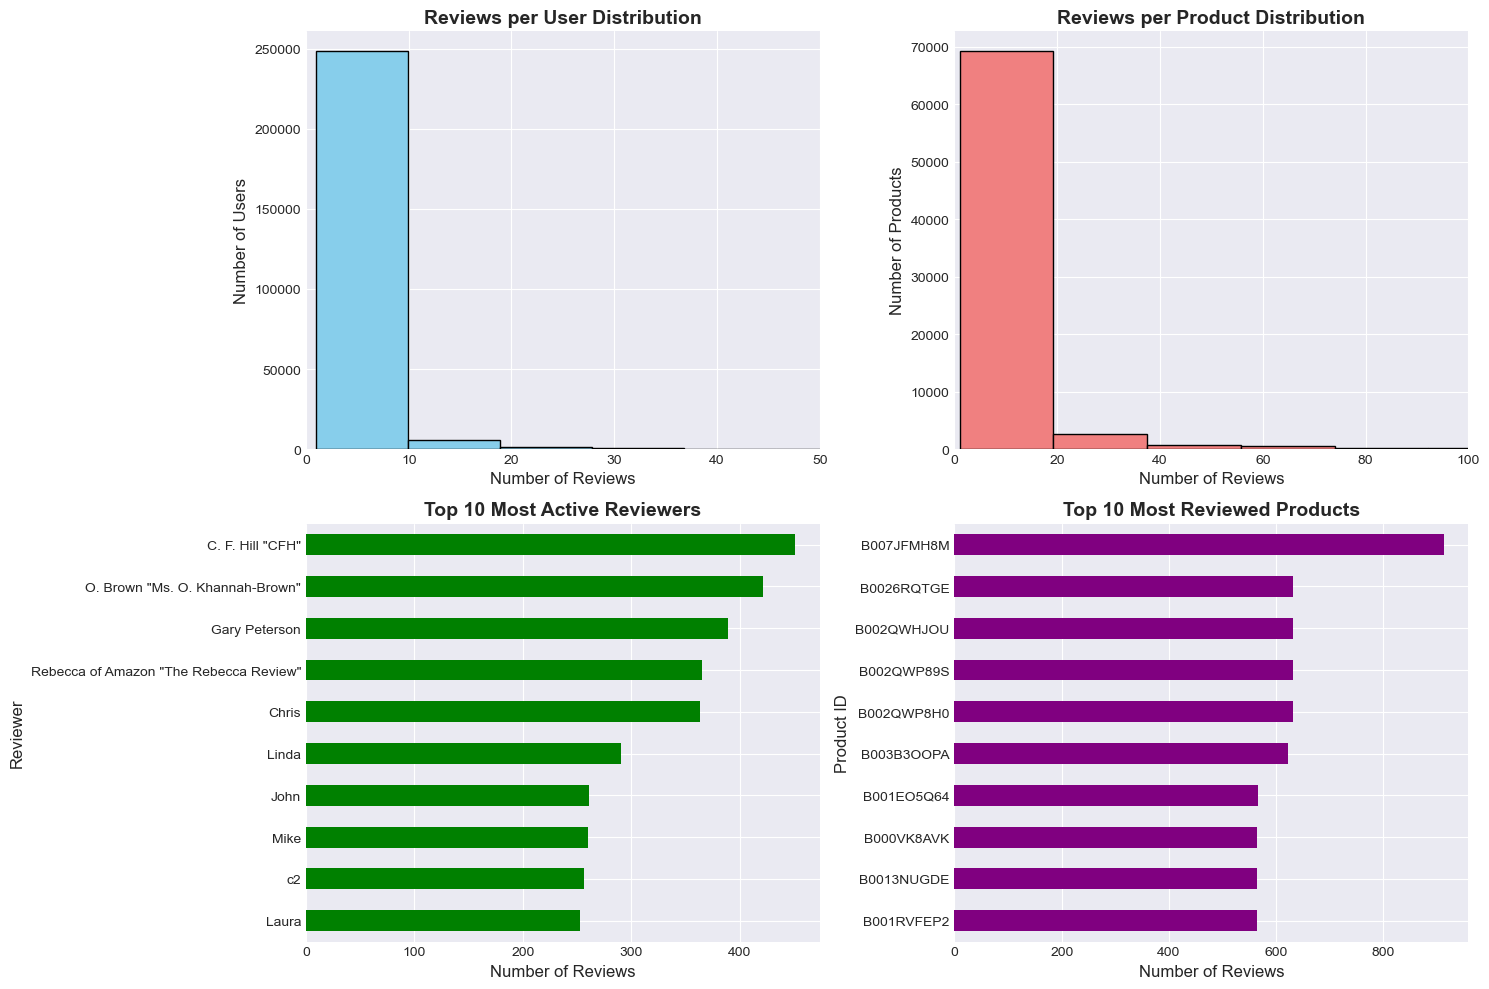

In [41]:
# User and Product Analysis
print("\n" + "="*70)
print("USER & PRODUCT ANALYSIS")
print("="*70 + "\n")

# Unique counts
print("UNIQUE COUNTS:")
print(f"Unique Users: {reviews['UserId'].nunique():,}")
print(f"Unique Products: {reviews['ProductId'].nunique():,}")
print(f"Unique Profile Names: {reviews['ProfileName'].nunique():,}")
print()

# Reviews per user
reviews_per_user = reviews.groupby('UserId').size()
print("REVIEWS PER USER STATISTICS:")
print(reviews_per_user.describe())
print()

print("TOP 10 MOST ACTIVE REVIEWERS:")
top_users = reviews['ProfileName'].value_counts().head(10)
for i, (user, count) in enumerate(top_users.items(), 1):
    print(f"{i:2d}. {user}: {count} reviews")
print()

# Reviews per product
reviews_per_product = reviews.groupby('ProductId').size()
print("REVIEWS PER PRODUCT STATISTICS:")
print(reviews_per_product.describe())
print()

print("TOP 10 MOST REVIEWED PRODUCTS:")
top_products = reviews_per_product.nlargest(10)
for i, (product, count) in enumerate(top_products.items(), 1):
    print(f"{i:2d}. {product}: {count} reviews")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Reviews per user distribution
axes[0, 0].hist(reviews_per_user, bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Reviews per User Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Reviews', fontsize=12)
axes[0, 0].set_ylabel('Number of Users', fontsize=12)
axes[0, 0].set_xlim(0, 50)

# Reviews per product distribution
axes[0, 1].hist(reviews_per_product, bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Reviews per Product Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Number of Reviews', fontsize=12)
axes[0, 1].set_ylabel('Number of Products', fontsize=12)
axes[0, 1].set_xlim(0, 100)

# Top reviewers
top_users.head(10).plot(kind='barh', ax=axes[1, 0], color='green')
axes[1, 0].set_title('Top 10 Most Active Reviewers', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of Reviews', fontsize=12)
axes[1, 0].set_ylabel('Reviewer', fontsize=12)
axes[1, 0].invert_yaxis()

# Top products
top_products.plot(kind='barh', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Top 10 Most Reviewed Products', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Number of Reviews', fontsize=12)
axes[1, 1].set_ylabel('Product ID', fontsize=12)
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()


CORRELATION ANALYSIS

CORRELATION MATRIX:
                        Score  HelpfulnessNumerator  HelpfulnessDenominator  \
Score                   1.000                -0.033                  -0.098   
HelpfulnessNumerator   -0.033                 1.000                   0.975   
HelpfulnessDenominator -0.098                 0.975                   1.000   
Helpfulness Ratio       0.028                 0.242                   0.218   
Summary Length         -0.065                 0.058                   0.062   
Text Length            -0.077                 0.171                   0.176   
Summary Words          -0.077                 0.050                   0.054   
Text Words             -0.077                 0.169                   0.173   

                        Helpfulness Ratio  Summary Length  Text Length  \
Score                               0.028          -0.065       -0.077   
HelpfulnessNumerator                0.242           0.058        0.171   
HelpfulnessDenominator 

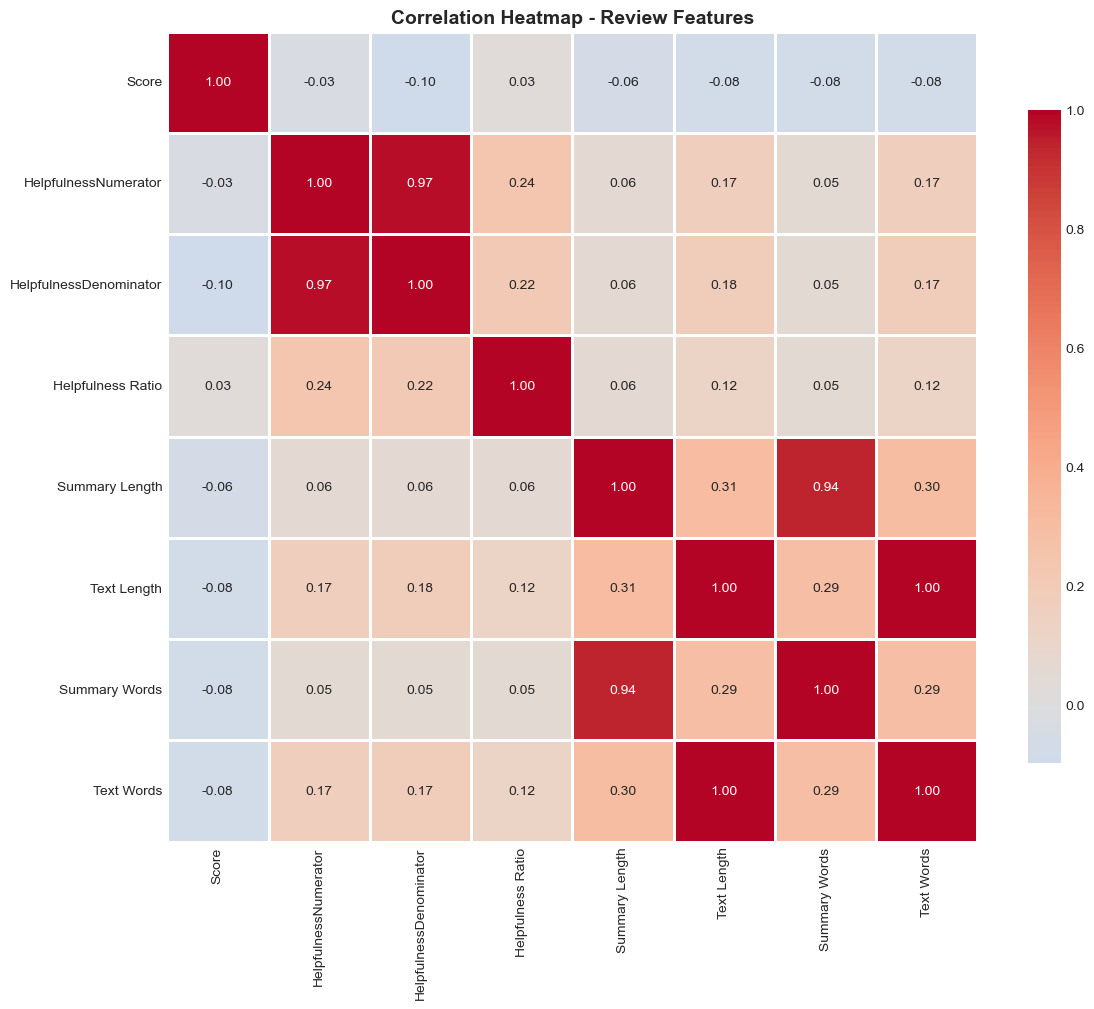


KEY CORRELATIONS:
Score vs Text Length: -0.077
Score vs Helpfulness Ratio: 0.028
Text Length vs Text Words: 0.995


In [42]:
# Correlation Analysis
print("\n" + "="*70)
print("CORRELATION ANALYSIS")
print("="*70 + "\n")

# Select numerical columns for correlation
numerical_cols = ['Score', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Helpfulness Ratio', 'Summary Length', 'Text Length', 
                  'Summary Words', 'Text Words']

correlation_matrix = reviews[numerical_cols].corr()

print("CORRELATION MATRIX:")
print(correlation_matrix)

# Visualization
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1, fmt='.2f', cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Review Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Key correlations
print("\nKEY CORRELATIONS:")
print(f"Score vs Text Length: {correlation_matrix.loc['Score', 'Text Length']:.3f}")
print(f"Score vs Helpfulness Ratio: {correlation_matrix.loc['Score', 'Helpfulness Ratio']:.3f}")
print(f"Text Length vs Text Words: {correlation_matrix.loc['Text Length', 'Text Words']:.3f}")

In [43]:
# Summary Statistics - Reviews Dataset
print("\n" + "="*70)
print("REVIEWS DATASET - COMPREHENSIVE SUMMARY")
print("="*70 + "\n")

summary_stats_reviews = {
    'Total Reviews': f"{len(reviews):,}",
    'Unique Users': f"{reviews['UserId'].nunique():,}",
    'Unique Products': f"{reviews['ProductId'].nunique():,}",
    'Date Range': f"{reviews['DateTime'].min().date()} to {reviews['DateTime'].max().date()}",
    'Average Score': f"{reviews['Score'].mean():.2f}/5.0",
    'Median Score': f"{reviews['Score'].median():.0f}/5.0",
    'Positive Reviews (4-5★)': f"{((reviews['Score'] >= 4).sum() / len(reviews) * 100):.1f}%",
    'Negative Reviews (1-2★)': f"{((reviews['Score'] <= 2).sum() / len(reviews) * 100):.1f}%",
    'Avg Text Length': f"{reviews['Text Length'].mean():.0f} characters",
    'Avg Word Count': f"{reviews['Text Words'].mean():.0f} words",
    'Reviews with Votes': f"{(reviews['HelpfulnessDenominator'] > 0).sum():,} ({((reviews['HelpfulnessDenominator'] > 0).sum() / len(reviews) * 100):.1f}%)",
    'Missing Values': f"{reviews.isnull().sum().sum():,}"
}

print("KEY METRICS:")
for key, value in summary_stats_reviews.items():
    print(f"{key}: {value}")


REVIEWS DATASET - COMPREHENSIVE SUMMARY

KEY METRICS:
Total Reviews: 568,454
Unique Users: 256,059
Unique Products: 74,258
Date Range: 1999-10-08 to 2012-10-26
Average Score: 4.18/5.0
Median Score: 5/5.0
Positive Reviews (4-5★): 78.1%
Negative Reviews (1-2★): 14.4%
Avg Text Length: 436 characters
Avg Word Count: 80 words
Reviews with Votes: 298,402 (52.5%)
Missing Values: 53


In [44]:
# Key Findings & Insights - Reviews Dataset
print("\n" + "="*70)
print("KEY FINDINGS & INSIGHTS - REVIEWS DATASET")
print("="*70 + "\n")

print("1. DATA OVERVIEW:")
print(f"• Massive dataset with {len(reviews):,} reviews")
print(f"• Covers {reviews['ProductId'].nunique():,} unique products")
print(f"• From {reviews['UserId'].nunique():,} unique users")
print(f"• Spans {(reviews['DateTime'].max() - reviews['DateTime'].min()).days} days")
print()

print("2. SCORE DISTRIBUTION:")
positive_pct = ((reviews['Score'] >= 4).sum() / len(reviews) * 100)
negative_pct = ((reviews['Score'] <= 2).sum() / len(reviews) * 100)
neutral_pct = ((reviews['Score'] == 3).sum() / len(reviews) * 100)
print(f"• Positive (4-5★): {positive_pct:.1f}%")
print(f"• Neutral (3★): {neutral_pct:.1f}%")
print(f"• Negative (1-2★): {negative_pct:.1f}%")
print(f"• Overall sentiment: {'Highly Positive' if positive_pct > 60 else 'Mixed'}")
print(f"• Average: {reviews['Score'].mean():.2f}/5.0")
print()

print("3. TEXT CHARACTERISTICS:")
print(f"• Avg review length: {reviews['Text Length'].mean():.0f} characters")
print(f"• Avg word count: {reviews['Text Words'].mean():.0f} words")
print(f"• Longer reviews tend to be: {'more positive' if correlation_matrix.loc['Score', 'Text Length'] > 0 else 'more negative'}")
print()

print("4. USER ENGAGEMENT:")
reviews_with_votes_pct = (reviews['HelpfulnessDenominator'] > 0).sum() / len(reviews) * 100
print(f"• {reviews_with_votes_pct:.1f}% of reviews have helpfulness votes")
print(f"• Avg reviews per user: {reviews_per_user.mean():.1f}")
print(f"• Avg reviews per product: {reviews_per_product.mean():.1f}")
print()

print("5. TEMPORAL PATTERNS:")
peak_year = year_counts.idxmax()
peak_year_count = year_counts.max()
print(f"• Peak activity year: {peak_year} ({peak_year_count:,} reviews)")
print(f"• Review volume trend: {'Increasing' if year_counts.iloc[-1] > year_counts.iloc[0] else 'Decreasing'}")


KEY FINDINGS & INSIGHTS - REVIEWS DATASET

1. DATA OVERVIEW:
• Massive dataset with 568,454 reviews
• Covers 74,258 unique products
• From 256,059 unique users
• Spans 4767 days

2. SCORE DISTRIBUTION:
• Positive (4-5★): 78.1%
• Neutral (3★): 7.5%
• Negative (1-2★): 14.4%
• Overall sentiment: Highly Positive
• Average: 4.18/5.0

3. TEXT CHARACTERISTICS:
• Avg review length: 436 characters
• Avg word count: 80 words
• Longer reviews tend to be: more negative

4. USER ENGAGEMENT:
• 52.5% of reviews have helpfulness votes
• Avg reviews per user: 2.2
• Avg reviews per product: 7.7

5. TEMPORAL PATTERNS:
• Peak activity year: 2012 (198,659 reviews)
• Review volume trend: Increasing


In [45]:
# Save Processed Reviews Data
print("\n" + "="*70)
print("SAVE PROCESSED DATA")
print("="*70 + "\n")

# Save cleaned dataset with new features
output_path_reviews = '../data/processed/reviews_explored.csv'

# Save a sample (full dataset is too large)
print("NOTE: Full dataset is very large (568K+ reviews)")
print("Saving options:")
print("1. Save full dataset (may take time)")
print("2. Save sample (recommended for GitHub)")

# Option 1: Save sample
sample_size = 10000
sample_df = reviews.sample(n=sample_size, random_state=42)
sample_output = '../data/processed/reviews_sample_explored.csv'

try:
    sample_df.to_csv(sample_output, index=False)
    print(f"\nSample dataset saved to: {sample_output}")
    print(f"Sample size: {len(sample_df):,} reviews")
    print(f"Columns: {len(sample_df.columns)}")
except Exception as e:
    print(f"Could not save sample: {e}")

# Option 2: Save full dataset (commented out by default) Uncomment if you want to save the full dataset
# try:
#     reviews_df.to_csv(output_path_reviews, index=False)
#     print(f"Full dataset saved to: {output_path_reviews}")
# except Exception as e:
#     print(f"Could not save full dataset: {e}")

print("\n" + "="*70)
print("REVIEWS DATASET EXPLORATION COMPLETE!")
print("="*70)
print("\nDataset Summary:")
print(f"• {len(reviews):,} total reviews analyzed")
print(f"• {reviews['ProductId'].nunique():,} unique products")
print(f"• {reviews['UserId'].nunique():,} unique users")
print(f"• {len(reviews.columns)} features created")
print(f"• Average score: {reviews['Score'].mean():.2f}/5.0")
print("="*70 + "\n")


SAVE PROCESSED DATA

NOTE: Full dataset is very large (568K+ reviews)
Saving options:
1. Save full dataset (may take time)
2. Save sample (recommended for GitHub)

Sample dataset saved to: ../data/processed/reviews_sample_explored.csv
Sample size: 10,000 reviews
Columns: 21

REVIEWS DATASET EXPLORATION COMPLETE!

Dataset Summary:
• 568,454 total reviews analyzed
• 74,258 unique products
• 256,059 unique users
• 21 features created
• Average score: 4.18/5.0



# Dataset 4: Mental Health FAQ

In [46]:
print('\n' + '=' * 70)
print('MENTAL HEALTH FAQ DATASET EXPLORATION')
print('=' * 70 + '\n')

# Load the mental health FAQ dataset
mental_health_file_path = '/Users/vishalhooda/Documents/Intelligent-Customer-Support/data/raw/Mental_Health_FAQ.csv'

mental = pd.read_csv(mental_health_file_path)
print('Mental Health FAQ dataset loaded successfully')
print(f"Dataset shape: {mental.shape}")


MENTAL HEALTH FAQ DATASET EXPLORATION

Mental Health FAQ dataset loaded successfully
Dataset shape: (98, 3)


In [47]:
# Initial Data Inspection
print('\n' + '=' * 70)
print('INITIAL DATA INSPECTION')
print('=' * 70 + '\n')

# Basid information
print(f"Total FAQ Entries: {len(mental)}")
print(f"Total Columns: {len(mental.columns)}")

# Display first few rows
print("\nFIRST 5 ROWS:")
print(mental.head())

# Display last few rows
print('\nLAST 5 ROWS:')
print(mental.tail())

print('\n' + '=' * 70)

# Display random sample
print('\nRANDOM SAMPLE (5 entries):')
print(mental.sample(5))

print('\n' + '=' * 70)

# Column names
print('\nCOLUMN NAMES:')
for i, col in enumerate(mental.columns, 1):
    print(f"{i}. {col}")

print('\n' + '=' * 70)

# Data types
print('\nDATA TYPES:')
print(mental.dtypes)

print('\n' + '=' * 70)

# Detailed info
print('\nDETAILED INFO:')
mental.info()


INITIAL DATA INSPECTION

Total FAQ Entries: 98
Total Columns: 3

FIRST 5 ROWS:
   Question_ID                                          Questions  \
0      1590140        What does it mean to have a mental illness?   
1      2110618                    Who does mental illness affect?   
2      6361820                        What causes mental illness?   
3      9434130  What are some of the warning signs of mental i...   
4      7657263            Can people with mental illness recover?   

                                             Answers  
0  Mental illnesses are health conditions that di...  
1  It is estimated that mental illness affects 1 ...  
2  It is estimated that mental illness affects 1 ...  
3  Symptoms of mental health disorders vary depen...  
4  When healing from mental illness, early identi...  

LAST 5 ROWS:
    Question_ID                                          Questions  \
93      4373204            How do I know if I'm drinking too much?   
94      7807643  If c

In [48]:
# Data Quality Check
print("\n" + "="*70)
print("DATA QUALITY CHECK")
print("="*70 + "\n")

# Check for missing values
missing_counts = mental.isnull().sum()
missing_percent = (missing_counts / len(mental)) * 100

missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Percentage': missing_percent.values
})

print("MISSING VALUES:")
print(missing_df.to_string(index=False))

if missing_counts.sum() == 0:
    print("\nNo missing values found! Dataset is complete.")
else:
    print(f"\nTotal missing values: {missing_counts.sum()}")

# Check for duplicates
print(f"\nDUPLICATE ROWS: {mental.duplicated().sum()}")

# Check duplicate Question IDs
duplicate_ids = mental['Question_ID'].duplicated().sum()
print(f"DUPLICATE QUESTION IDs: {duplicate_ids}")

# Check for duplicate questions
duplicate_questions = mental['Questions'].duplicated().sum()
print(f"DUPLICATE QUESTIONS (text): {duplicate_questions}")

# Check for empty strings
print("\nEMPTY STRINGS CHECK:")
for col in ['Questions', 'Answers']:
    empty_count = (mental[col].str.strip() == '').sum()
    print(f"{col}: {empty_count} empty strings")


DATA QUALITY CHECK

MISSING VALUES:
     Column  Missing_Count  Missing_Percentage
Question_ID              0               0.000
  Questions              0               0.000
    Answers              0               0.000

No missing values found! Dataset is complete.

DUPLICATE ROWS: 0
DUPLICATE QUESTION IDs: 0
DUPLICATE QUESTIONS (text): 0

EMPTY STRINGS CHECK:
Questions: 0 empty strings
Answers: 0 empty strings



QUESTION ANALYSIS

QUESTION LENGTH STATISTICS (Characters):
count    98.000
mean     52.316
std      25.214
min      12.000
25%      37.250
50%      51.000
75%      61.750
max     210.000
Name: Question Length, dtype: float64

QUESTION WORD COUNT STATISTICS:
count   98.000
mean     9.306
std      4.667
min      3.000
25%      6.000
50%      9.000
75%     11.000
max     39.000
Name: Question Words, dtype: float64

QUESTION LENGTH RANGES:
0-25 chars: 6 questions (6.1%)
25-50 chars: 40 questions (40.8%)
50-75 chars: 41 questions (41.8%)
75-100 chars: 8 questions (8.2%)
100-200 chars: 2 questions (2.0%)

LONGEST QUESTION:
Length: 210 characters
Question: Cannabis is legally allowed to 19+ but there are doctor groups saying it’s potentially harmful to age 25. Any use or certain use? What’s myth and what’s fact? If I’m a parent, what should I tell my young adult?

SHORTEST QUESTION:
Length: 12 characters
Question: What is MSP?


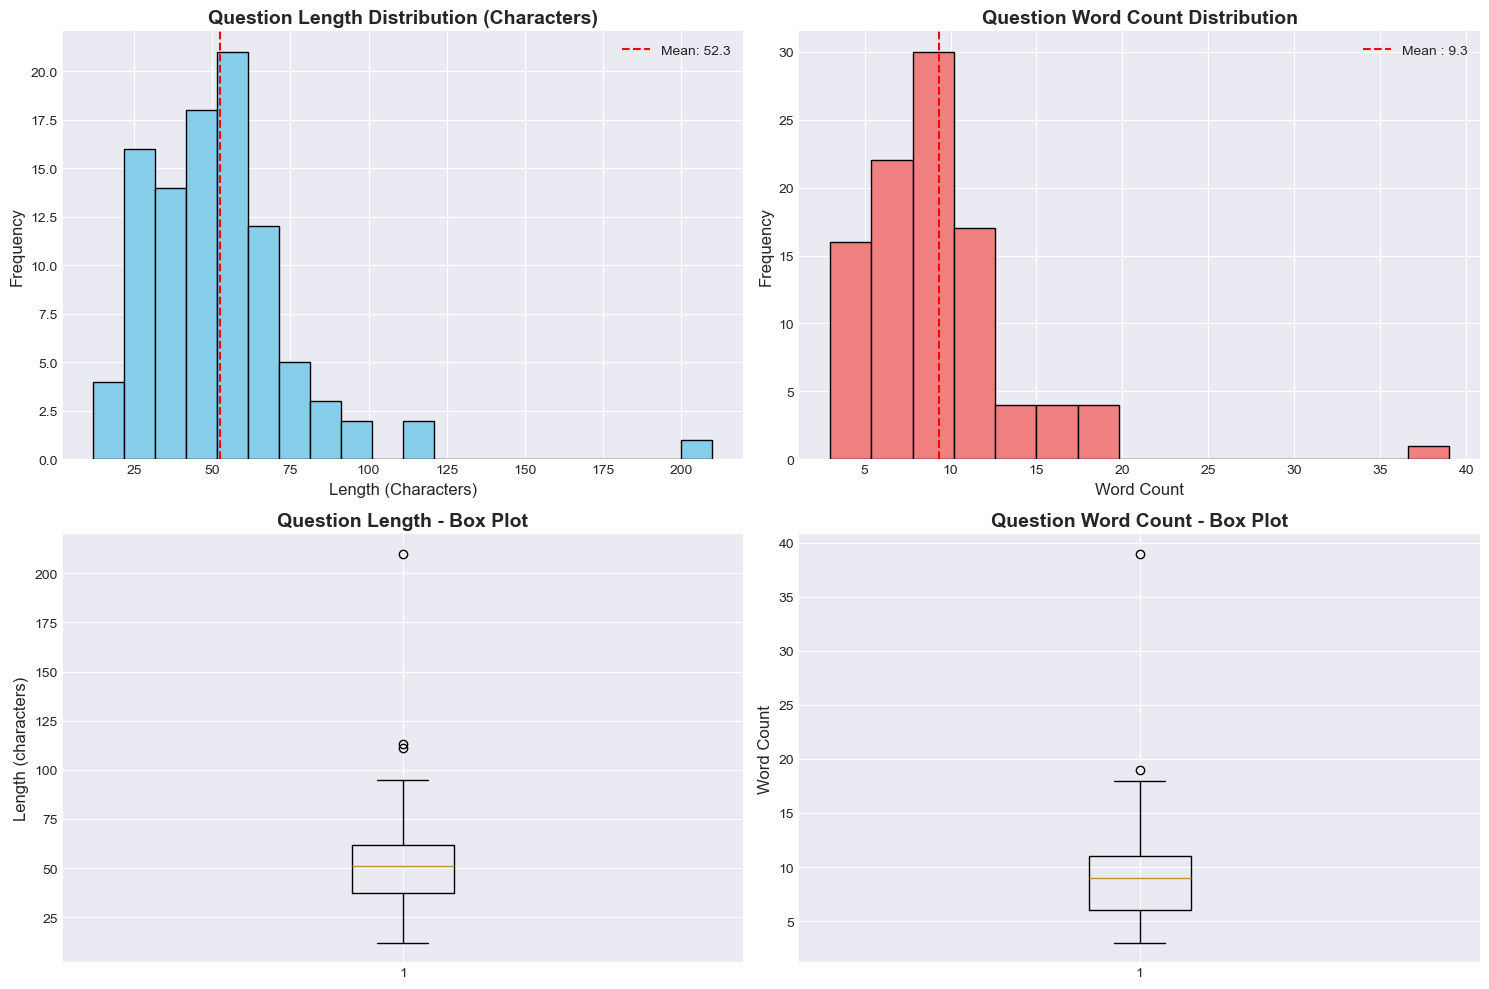

In [49]:
# Question Analysis
print('\n' + '=' * 70)
print('QUESTION ANALYSIS')
print('=' * 70 + '\n')

# Calculate question lengths
mental['Question Length'] = mental['Questions'].str.len()
mental['Question Words'] = mental['Questions'].str.split().str.len()

print('QUESTION LENGTH STATISTICS (Characters):')
print(mental['Question Length'].describe())
print()

print('QUESTION WORD COUNT STATISTICS:')
print(mental['Question Words'].describe())
print()

# Question length distribution
print('QUESTION LENGTH RANGES:')
ranges = [(0, 25), (25, 50), (50, 75), (75, 100), (100, 200)]
for start, end in ranges:
    count = ((mental['Question Length'] >= start) & (mental['Question Length'] < end)).sum()
    pct = (count / len(mental)) * 100
    print(f"{start}-{end} chars: {count} questions ({pct:.1f}%)")

# Longest and shortest questions
print('\nLONGEST QUESTION:')
longest_q = mental.loc[mental['Question Length'].idxmax()]
print(f"Length: {longest_q['Question Length']} characters")
print(f"Question: {longest_q['Questions']}")

print('\nSHORTEST QUESTION:')
shortest_q = mental.loc[mental['Question Length'].idxmin()]
print(f"Length: {shortest_q['Question Length']} characters")
print(f"Question: {shortest_q['Questions']}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize = (15, 10))

# Question length histogram
axes[0, 0].hist(mental['Question Length'], bins = 20, color = 'skyblue', edgecolor = 'black')
axes[0, 0].set_title('Question Length Distribution (Characters)', fontsize = 14, fontweight = 'bold')
axes[0, 0].set_xlabel('Length (Characters)', fontsize = 12)
axes[0, 0].set_ylabel('Frequency', fontsize = 12)
axes[0, 0].axvline(mental['Question Length'].mean(), color = 'red', linestyle = '--', 
                   label = f"Mean: {mental['Question Length'].mean():.1f}")
axes[0, 0].legend()

# Question word count histogram
axes[0, 1].hist(mental['Question Words'], bins = 15, color = 'lightcoral', edgecolor = 'black')
axes[0, 1].set_title('Question Word Count Distribution', fontsize = 14, fontweight = 'bold')
axes[0, 1].set_xlabel('Word Count', fontsize = 12)
axes[0, 1].set_ylabel('Frequency', fontsize = 12)
axes[0, 1].axvline(mental['Question Words'].mean(), color = 'red', linestyle = '--', 
                   label = f"Mean : {mental['Question Words'].mean():.1f}")
axes[0, 1].legend()

# Box plot - Question length
axes[1, 0].boxplot(mental['Question Length'], vert = True)
axes[1, 0].set_title('Question Length - Box Plot', fontsize = 14, fontweight = 'bold')
axes[1, 0].set_ylabel('Length (characters)', fontsize = 12)

# Box plot - Question words
axes[1, 1].boxplot(mental['Question Words'], vert = True)
axes[1, 1].set_title('Question Word Count - Box Plot', fontsize = 14, fontweight = 'bold')
axes[1, 1].set_ylabel('Word Count', fontsize = 12)

plt.tight_layout()
plt.show()
             


ANSWER ANALYSIS

ANSWER LENGTH STATISTICS (Characters):
count     98.000
mean    1591.847
std     1374.447
min       93.000
25%      551.000
50%     1274.500
75%     2368.000
max     8492.000
Name: Answer Length, dtype: float64

ANSWER WORD COUNT STATISTICS:
count     98.000
mean     257.143
std      227.368
min       16.000
25%       84.250
50%      193.500
75%      388.750
max     1441.000
Name: Answer Words, dtype: float64

ANSWER SENTENCE COUNT STATISTICS:
count   98.000
mean    15.235
std     14.166
min      2.000
25%      5.000
50%     11.500
75%     21.000
max     88.000
Name: Answer Sentences, dtype: float64

ANSWER LENGTH RANGES:
0-100 chars: 1 answers (1.0%)
100-200 chars: 8 answers (8.2%)
200-300 chars: 7 answers (7.1%)
300-500 chars: 8 answers (8.2%)
500-1000 chars: 14 answers (14.3%)
1000-5000 chars: 58 answers (59.2%)

LONGEST ANSWER:
Length: 8492 characters
Word Count: 1441 words
Question: Someone I love has been diagnosed with schizophrenia. How can I help?
Answer prev

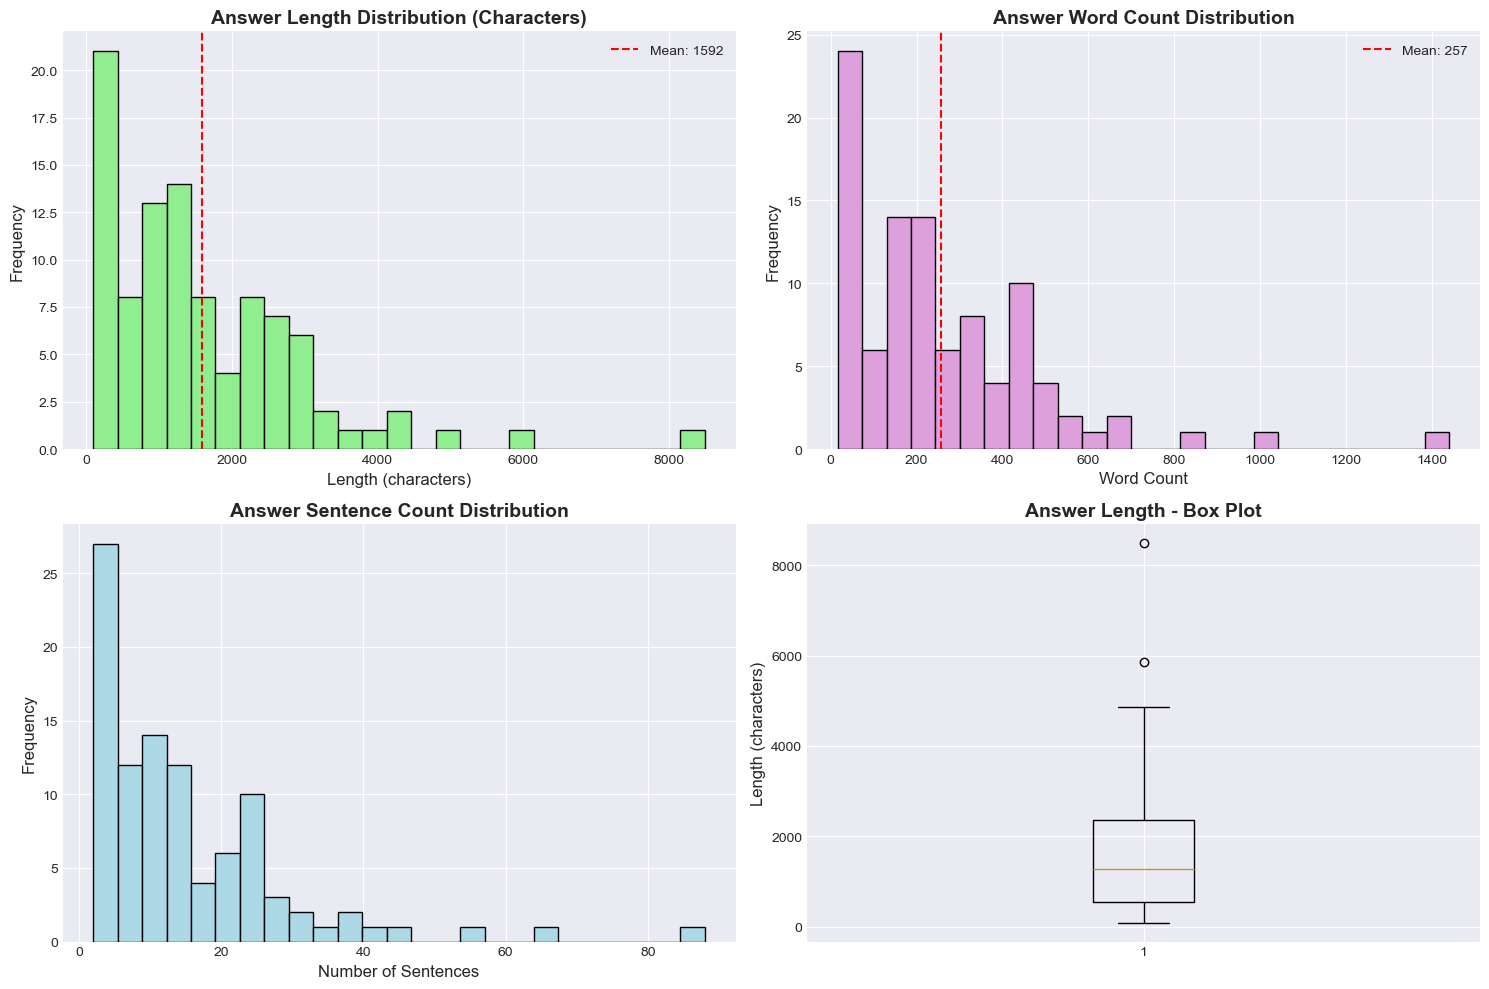

In [54]:
# Answer Analysis
print('\n' + '=' * 70)
print('ANSWER ANALYSIS')
print('=' * 70 + '\n')

# Calculate answer lengths
mental['Answer Length'] = mental['Answers'].str.len()
mental['Answer Words'] = mental['Answers'].str.split().str.len()
mental['Answer Sentences'] = mental['Answers'].str.split('.').str.len()

print('ANSWER LENGTH STATISTICS (Characters):')
print(mental['Answer Length'].describe())
print()

print('ANSWER WORD COUNT STATISTICS:')
print(mental['Answer Words'].describe())
print()

print('ANSWER SENTENCE COUNT STATISTICS:')
print(mental['Answer Sentences'].describe())
print()

# Answer length distribution
print('ANSWER LENGTH RANGES:')
ranges = [(0, 100), (100, 200), (200, 300), (300, 500), (500, 1000), (1000, 5000)]
for start, end in ranges:
    count = ((mental['Answer Length'] >= start) & (mental['Answer Length'] < end)).sum()
    pct = (count / len(mental)) * 100
    if count > 0:
        print(f"{start}-{end} chars: {count} answers ({pct:.1f}%)")

# Longest and shortest answers
print('\nLONGEST ANSWER:')
longest_a = mental.loc[mental['Answer Length'].idxmax()]
print(f"Length: {longest_a['Answer Length']} characters")
print(f"Word Count: {longest_a['Answer Words']} words")
print(f"Question: {longest_a['Questions']}")
print(f"Answer preview: {longest_a['Answers'][:200]}...")

print('\nSHORTEST ANSWER:')
shortest_a = mental.loc[mental['Answer Length'].idxmin()]
print(f"Length: {shortest_a['Answer Length']} characters")
print(f"Word Count: {shortest_a['Answer Words']} words")
print(f"Question: {shortest_a['Questions']}")
print(f"Answer preview: {shortest_a['Answers']}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize = (15, 10))

# Answer length histogram
axes[0, 0].hist(mental['Answer Length'], bins = 25, color = 'lightgreen', edgecolor = 'black')
axes[0, 0].set_title('Answer Length Distribution (Characters)', fontsize = 14, fontweight = 'bold')
axes[0, 0].set_xlabel('Length (characters)', fontsize = 12)
axes[0, 0].set_ylabel('Frequency', fontsize = 12)
axes[0, 0].axvline(mental['Answer Length'].mean(), color = 'red', linestyle = '--', 
                   label = f"Mean: {mental['Answer Length'].mean():.0f}")
axes[0, 0].legend()

# Answer word count histogram
axes[0, 1].hist(mental['Answer Words'], bins = 25, color = 'plum', edgecolor = 'black')
axes[0, 1].set_title('Answer Word Count Distribution', fontsize = 14, fontweight = 'bold')
axes[0, 1].set_xlabel('Word Count', fontsize = 12)
axes[0, 1].set_ylabel('Frequency', fontsize = 12)
axes[0, 1].axvline(mental['Answer Words'].mean(), color = 'red', linestyle = '--', 
                   label = f"Mean: {mental['Answer Words'].mean():.0f}")
axes[0, 1].legend()

# Answer sentence count
axes[1, 0].hist(mental['Answer Sentences'], bins = 25, color = 'lightblue', edgecolor = 'black')
axes[1, 0].set_title('Answer Sentence Count Distribution', fontsize = 14, fontweight = 'bold')
axes[1, 0].set_xlabel('Number of Sentences', fontsize = 12)
axes[1, 0].set_ylabel('Frequency', fontsize = 12)

# Box plot - Answer length
axes[1, 1].boxplot(mental['Answer Length'], vert = True)
axes[1, 1].set_title('Answer Length - Box Plot', fontsize = 14, fontweight = 'bold')
axes[1, 1].set_ylabel('Length (characters)', fontsize = 12)

plt.tight_layout()
plt.show()


QUESTION-ANSWER RELATIONSHIP

ANSWER TO QUESTION LENGTH RATIO:
count    98.000
mean     34.489
std      32.670
min       1.817
25%      11.290
50%      28.150
75%      43.354
max     167.457
Name: Answer Question Ratio, dtype: float64

On average, answers are 34.5x longer than questions

CORRELATION (Question Length vs Answer Length): 0.174
Weak correlation - question length doesn't predict answer length


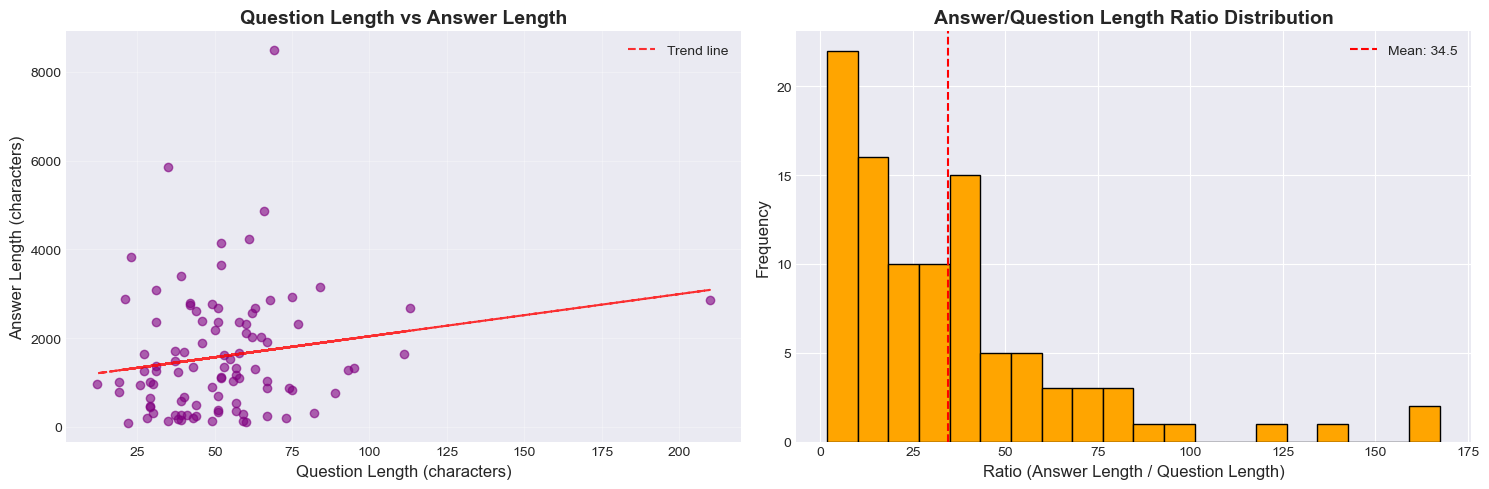

In [56]:
# Question-Answer Relationship
print("\n" + "=" * 70)
print("QUESTION-ANSWER RELATIONSHIP")
print("=" * 70 + "\n")

# Calculate ratio
mental['Answer Question Ratio'] = mental['Answer Length'] / mental['Question Length']

print("ANSWER TO QUESTION LENGTH RATIO:")
print(mental['Answer Question Ratio'].describe())
print()

print(f"On average, answers are {mental['Answer Question Ratio'].mean():.1f}x longer than questions")

# Correlation
correlation = mental['Question Length'].corr(mental['Answer Length'])
print(f"\nCORRELATION (Question Length vs Answer Length): {correlation:.3f}")

if abs(correlation) < 0.3:
    print("Weak correlation - question length doesn't predict answer length")
elif abs(correlation) < 0.7:
    print("Moderate correlation - some relationship exists")
else:
    print("Strong correlation - longer questions tend to have longer answers")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

# Scatter plot
axes[0].scatter(mental['Question Length'], mental['Answer Length'], alpha = 0.6, color = 'purple')
axes[0].set_title('Question Length vs Answer Length', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Question Length (characters)', fontsize = 12)
axes[0].set_ylabel('Answer Length (characters)', fontsize = 12)
axes[0].grid(alpha = 0.3)

# Add trend line
z = np.polyfit(mental['Question Length'], mental['Answer Length'], 1)
p = np.poly1d(z)
axes[0].plot(mental['Question Length'], p(mental['Question Length']), "r--", alpha = 0.8, label='Trend line')
axes[0].legend()

# Answer to Question ratio distribution
axes[1].hist(mental['Answer Question Ratio'], bins = 20, color = 'orange', edgecolor = 'black')
axes[1].set_title('Answer/Question Length Ratio Distribution', fontsize = 14, fontweight = 'bold')
axes[1].set_xlabel('Ratio (Answer Length / Question Length)', fontsize = 12)
axes[1].set_ylabel('Frequency', fontsize = 12)
axes[1].axvline(mental['Answer Question Ratio'].mean(), color='red', linestyle='--',
                label=f"Mean: {mental['Answer Question Ratio'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()


CONTENT ANALYSIS - QUESTION TOPICS

TOP 20 WORDS IN QUESTIONS:
 1. mental               :  22
 2. find                 :  21
 3. health               :  17
 4. help                 :  15
 5. difference           :  12
 6. between              :  12
 7. disorder             :  11
 8. about                :  10
 9. illness              :   7
10. use                  :   7
11. know                 :   6
12. someone              :   6
13. information          :   6
14. should               :   5
15. care                 :   5
16. more                 :   5
17. personality          :   5
18. child                :   4
19. treatment            :   4
20. need                 :   4

QUESTION TYPES (Starting words):
   what           : 26 questions (26.5%)
   how            : 22 questions (22.4%)
   where          : 15 questions (15.3%)
   what's         :  8 questions (8.2%)
   if             :  4 questions (4.1%)
   i’m            :  4 questions (4.1%)
   can            :  3 questions (3.1%)

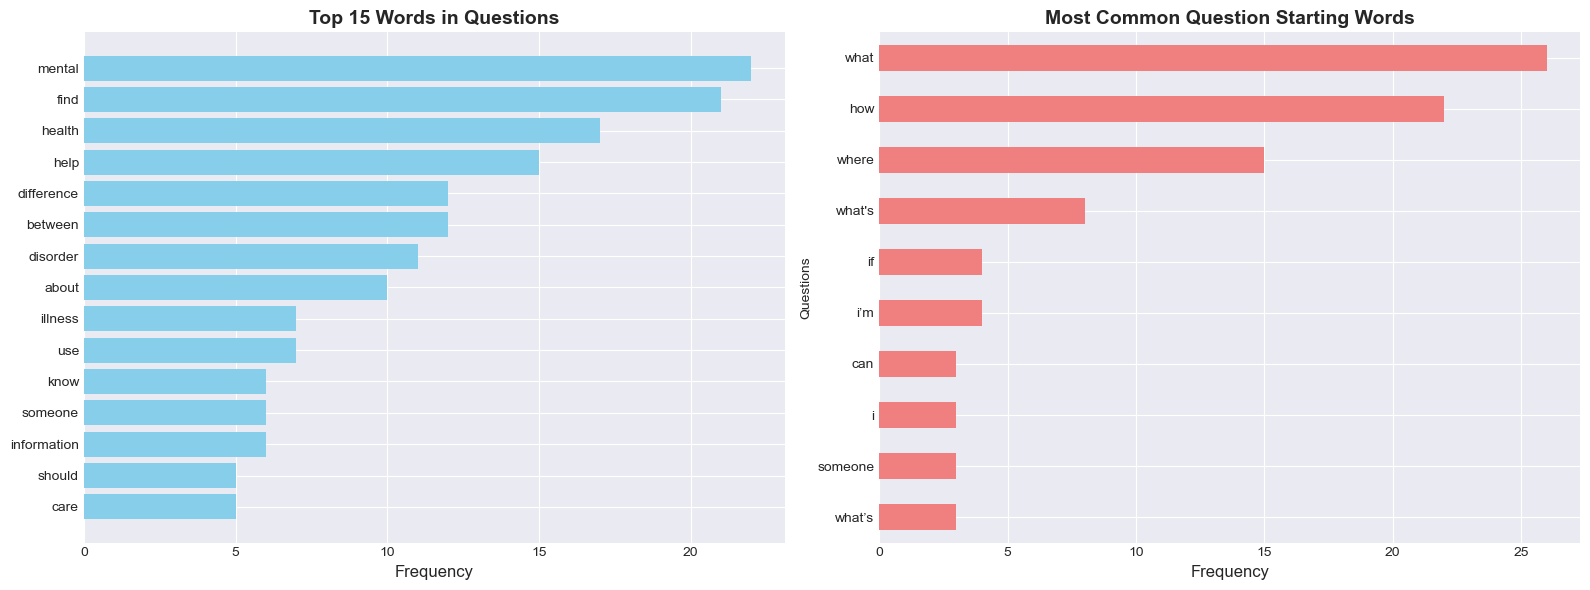

In [58]:
# Content Analysis - Question Topics
print("\n" + "=" * 70)
print("CONTENT ANALYSIS - QUESTION TOPICS")
print("=" * 70 + "\n")

# Common question words
from collections import Counter
import re

def get_top_words(texts, n = 20, min_length = 3):
    """Extract top N words from texts"""
    all_text = ' '.join(texts)
    words = re.findall(r'\b[a-z]{' + str(min_length) + r',}\b', all_text.lower())
    # Common stopwords
    stopwords = {'the', 'and', 'to', 'of', 'for', 'you', 'in', 'is', 'that', 'it', 'on', 'with', 'was', 'are', 'this', 
                 'have', 'from', 'or', 'be', 'at', 'by', 'not', 'but', 'can', 'your', 'will', 'my', 'me', 'has',
                 'what', 'how', 'who', 'does', 'when', 'where', 'why', 'which'}
    words = [w for w in words if w not in stopwords]
    return Counter(words).most_common(n)

print("TOP 20 WORDS IN QUESTIONS:")
question_words = get_top_words(mental['Questions'])
for i, (word, count) in enumerate(question_words, 1):
    print(f"{i:2d}. {word:20s} : {count:3d}")

# Common question types (starting words)
print("\nQUESTION TYPES (Starting words):")
question_starters = mental['Questions'].str.lower().str.split().str[0].value_counts().head(10)
for starter, count in question_starters.items():
    pct = (count / len(mental)) * 100
    print(f"   {starter:15s}: {count:2d} questions ({pct:.1f}%)")

# Key mental health terms
print("\nKEY MENTAL HEALTH TERMS IN QUESTIONS:")
mental_health_terms = ['mental', 'health', 'illness', 'disorder', 'treatment', 'therapy', 'depression', 'anxiety', 'help', 'care']
for term in mental_health_terms:
    count = mental['Questions'].str.lower().str.contains(term).sum()
    pct = (count / len(mental)) * 100
    if count > 0:
        print(f"   {term:15s}: {count:2d} questions ({pct:.1f}%)")

# Visualization - Top question words
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top words in questions
question_words_df = pd.DataFrame(question_words[:15], columns = ['word', 'count'])
axes[0].barh(question_words_df['word'], question_words_df['count'], color = 'skyblue')
axes[0].set_title('Top 15 Words in Questions', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Frequency', fontsize = 12)
axes[0].invert_yaxis()

# Question starters
question_starters.plot(kind='barh', ax = axes[1], color = 'lightcoral')
axes[1].set_title('Most Common Question Starting Words', fontsize = 14, fontweight = 'bold')
axes[1].set_xlabel('Frequency', fontsize = 12)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


CONTENT ANALYSIS - ANSWER TOPICS

TOP 20 WORDS IN ANSWERS:
 1. health               : 268
 2. mental               : 220
 3. people               : 193
 4. may                  : 187
 5. help                 : 174
 6. they                 : 166
 7. about                : 141
 8. their                : 120
 9. support              : 116
10. more                 : 112
11. like                 : 108
12. some                 : 106
13. other                : 104
14. find                 :  95
15. use                  :  89
16. one                  :  85
17. time                 :  81
18. symptoms             :  76
19. doctor               :  76
20. feel                 :  74

KEY MENTAL HEALTH TERMS IN ANSWERS:
   mental         : 69 answers (70.4%)
   health         : 74 answers (75.5%)
   illness        : 37 answers (37.8%)
   disorder       : 28 answers (28.6%)
   treatment      : 33 answers (33.7%)
   therapy        : 13 answers (13.3%)
   depression     : 15 answers (15.3%)
   anxiety

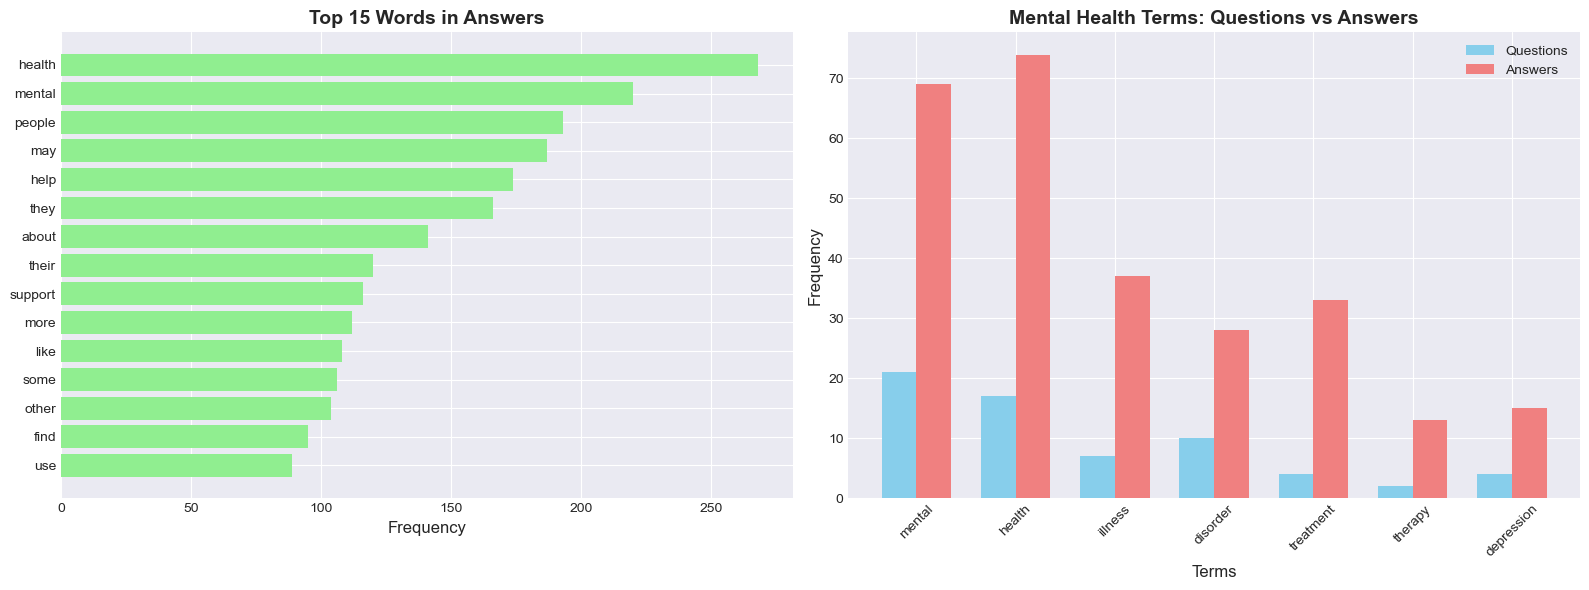

In [59]:
# Content Analysis - Answer Topics
print("\n" + "=" * 70)
print("CONTENT ANALYSIS - ANSWER TOPICS")
print("=" * 70 + "\n")

print("TOP 20 WORDS IN ANSWERS:")
answer_words = get_top_words(mental['Answers'])
for i, (word, count) in enumerate(answer_words, 1):
    print(f"{i:2d}. {word:20s} : {count:3d}")

# Mental health terms in answers
print("\nKEY MENTAL HEALTH TERMS IN ANSWERS:")
for term in mental_health_terms:
    count = mental['Answers'].str.lower().str.contains(term).sum()
    pct = (count / len(mental)) * 100
    if count > 0:
        print(f"   {term:15s}: {count:2d} answers ({pct:.1f}%)")

# Action/help words in answers
print("\nACTION/HELP WORDS IN ANSWERS:")
action_words = ['help', 'support', 'treatment', 'therapy', 'medication', 'professional', 'doctor', 'care', 'recovery', 'manage']
for word in action_words:
    count = mental['Answers'].str.lower().str.contains(word).sum()
    pct = (count / len(mental)) * 100
    if count > 0:
        print(f"   {word:15s}: {count:2d} answers ({pct:.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top words in answers
answer_words_df = pd.DataFrame(answer_words[:15], columns = ['word', 'count'])
axes[0].barh(answer_words_df['word'], answer_words_df['count'], color = 'lightgreen')
axes[0].set_title('Top 15 Words in Answers', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Frequency', fontsize = 12)
axes[0].invert_yaxis()

# Mental health terms comparison
terms_in_q = [mental['Questions'].str.lower().str.contains(term).sum() for term in mental_health_terms[:7]]
terms_in_a = [mental['Answers'].str.lower().str.contains(term).sum() for term in mental_health_terms[:7]]

x = np.arange(len(mental_health_terms[:7]))
width = 0.35
axes[1].bar(x - width/2, terms_in_q, width, label = 'Questions', color = 'skyblue')
axes[1].bar(x + width/2, terms_in_a, width, label = 'Answers', color = 'lightcoral')
axes[1].set_title('Mental Health Terms: Questions vs Answers', fontsize = 14, fontweight = 'bold')
axes[1].set_xlabel('Terms', fontsize = 12)
axes[1].set_ylabel('Frequency', fontsize = 12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(mental_health_terms[:7], rotation = 45)
axes[1].legend()

plt.tight_layout()
plt.show()

In [62]:
# Sample Q&A Pairs
print("\n" + "=" * 70)
print("SAMPLE QUESTION-ANSWER PAIRS")
print("=" * 70 + "\n")

# Display 5 random Q&A pairs
sample_pairs = mental.sample(5)

for idx, (i, row) in enumerate(sample_pairs.iterrows(), 1):
    print(f"{'='*70}")
    print(f"Q&A PAIR {idx}:")
    print(f"{'='*70}")
    print(f"\nQUESTION:")
    print(f"   {row['Questions']}")
    print(f"\nANSWER:")
    # Wrap text for better readability
    answer_text = row['Answers']
    words = answer_text.split()
    lines = []
    current_line = "   "
    for word in words:
        if len(current_line + word) > 67:
            lines.append(current_line)
            current_line = "   " + word + " "
        else:
            current_line += word + " "
    lines.append(current_line)
    print('\n'.join(lines))
    print(f"\nStats: Q: {row['Question Length']} chars, A: {row['Answer Length']} chars")
    print()


SAMPLE QUESTION-ANSWER PAIRS

Q&A PAIR 1:

QUESTION:
   I received a diagnosis but I don’t think it’s right. What can I do?

ANSWER:
   If possible, bring up your concerns with the professional who 
   provided the diagnosis. That way, the professional can answer 
   your questions and you can better understand their decision. If 
   that doesn’t resolve the situation or a follow-up appointment 
   isn’t possible, you can ask for a second opinion. A second 
   opinion is an assessment from a different professional. This can 
   give you better understanding of what’s going on and what to do 
   about it. Second opinions are common when it comes to major 
   health decisions—you won’t hurt anyone’s feelings and your 
   doctor will try to accommodate reasonable requests for a second 
   opinion. Talk to your family doctor (or go to a walk-in clinic) 
   to discuss your options and get a referral to a different 
   program or health professional, if needed. For more how to get a 
   sec

In [63]:
# Summary Statistics
print("\n" + "=" * 70)
print("MENTAL HEALTH FAQ - COMPREHENSIVE SUMMARY")
print("=" * 70 + "\n")

summary_stats_faq = {
    'Total FAQ Entries': f"{len(mental)}",
    'Avg Question Length': f"{mental['Question Length'].mean():.1f} characters",
    'Avg Question Words': f"{mental['Question Words'].mean():.1f} words",
    'Avg Answer Length': f"{mental['Answer Length'].mean():.0f} characters",
    'Avg Answer Words': f"{mental['Answer Words'].mean():.0f} words",
    'Avg Answer Sentences': f"{mental['Answer Sentences'].mean():.1f} sentences",
    'Answer/Question Ratio': f"{mental['Answer Question Ratio'].mean():.1f}x",
    'Longest Answer': f"{mental['Answer Length'].max()} characters",
    'Shortest Answer': f"{mental['Answer Length'].min()} characters",
    'Missing Values': f"{mental.isnull().sum().sum()}",
    'Duplicate Entries': f"{mental.duplicated().sum()}"
}

print("KEY METRICS:")
for key, value in summary_stats_faq.items():
    print(f"{key}: {value}")



MENTAL HEALTH FAQ - COMPREHENSIVE SUMMARY

KEY METRICS:
Total FAQ Entries: 98
Avg Question Length: 52.3 characters
Avg Question Words: 9.3 words
Avg Answer Length: 1592 characters
Avg Answer Words: 257 words
Avg Answer Sentences: 15.2 sentences
Answer/Question Ratio: 34.5x
Longest Answer: 8492 characters
Shortest Answer: 93 characters
Missing Values: 0
Duplicate Entries: 0


In [65]:
# Key findings & Insights
print("\n" + "=" * 70)
print("KEY FINDINGS & INSIGHTS - MENTAL HEALTH FAQ")
print("=" * 70 + "\n")

print("1. DATASET CHARACTERISTICS:")
print(f"   • Small, focused dataset with {len(mental)} Q&A pairs")
print(f"   • Complete data - no missing values")
print(f"   • No duplicate entries")
print(f"   • Focused on mental health education and awareness")
print()

print("2. QUESTION PATTERNS:")
print(f"   • Average question: {mental['Question Length'].mean():.0f} chars, {mental['Question Words'].mean():.0f} words")
print(f"   • Most common question types:")
most_common = question_starters.head(3)
for starter, count in most_common.items():
    print(f"      - {starter.capitalize()}: {count} questions")
print()

print("3. ANSWER CHARACTERISTICS:")
print(f"   • Average answer: {mental['Answer Length'].mean():.0f} chars, {mental['Answer Words'].mean():.0f} words")
print(f"   • Answers are {mental['Answer Question Ratio'].mean():.1f}x longer than questions")
print(f"   • Range: {mental['Answer Length'].min()}-{mental['Answer Length'].max()} characters")
print()

print("4. CONTENT FOCUS:")
print(f"   • Key topics: mental health, illness, treatment, support")
print(f"   • Focus areas: awareness, symptoms, treatment, recovery")
print(f"   • Tone: Educational and supportive")
print()

print("5. USE CASES:")
print(f"   • Perfect for chatbot/FAQ system")
print(f"   • Ideal for RAG (Retrieval-Augmented Generation)")
print(f"   • Semantic search and question matching")
print(f"   • Mental health information retrieval")


KEY FINDINGS & INSIGHTS - MENTAL HEALTH FAQ

1. DATASET CHARACTERISTICS:
   • Small, focused dataset with 98 Q&A pairs
   • Complete data - no missing values
   • No duplicate entries
   • Focused on mental health education and awareness

2. QUESTION PATTERNS:
   • Average question: 52 chars, 9 words
   • Most common question types:
      - What: 26 questions
      - How: 22 questions
      - Where: 15 questions

3. ANSWER CHARACTERISTICS:
   • Average answer: 1592 chars, 257 words
   • Answers are 34.5x longer than questions
   • Range: 93-8492 characters

4. CONTENT FOCUS:
   • Key topics: mental health, illness, treatment, support
   • Focus areas: awareness, symptoms, treatment, recovery
   • Tone: Educational and supportive

5. USE CASES:
   • Perfect for chatbot/FAQ system
   • Ideal for RAG (Retrieval-Augmented Generation)
   • Semantic search and question matching
   • Mental health information retrieval


In [66]:
# Save Processed Data
print("\n" + "=" * 70)
print("SAVE PROCESSED DATA")
print("=" * 70 + "\n")

# Save cleaned dataset with new features
output_path_faq = '../data/processed/mental_health_faq_explored.csv'

try:
    mental.to_csv(output_path_faq, index=False)
    print(f"Processed FAQ dataset saved to: {output_path_faq}")
    print(f"   Total entries: {len(mental)}")
    print(f"   Columns: {list(mental.columns)}")
    print(f"   Shape: {mental.shape}")
except Exception as e:
    print(f"Could not save file: {e}")

print("\n" + "=" * 70)
print("MENTAL HEALTH FAQ EXPLORATION COMPLETE!")
print("=" * 70)
print("\nDataset Summary:")
print(f"   • {len(mental)} Q&A pairs")
print(f"   • Avg question: {mental['Question Words'].mean():.0f} words")
print(f"   • Avg answer: {mental['Answer Words'].mean():.0f} words")
print(f"   • {len(mental.columns)} features created")


SAVE PROCESSED DATA

Processed FAQ dataset saved to: ../data/processed/mental_health_faq_explored.csv
   Total entries: 98
   Columns: ['Question_ID', 'Questions', 'Answers', 'Question Length', 'Question Words', 'Answer Length', 'Answer Words', 'Asnwer Sentences', 'Answer Sentences', 'Answer Question Ratio']
   Shape: (98, 10)

MENTAL HEALTH FAQ EXPLORATION COMPLETE!

Dataset Summary:
   • 98 Q&A pairs
   • Avg question: 9 words
   • Avg answer: 257 words
   • 10 features created


# Dataset 5: Telecom Customer Churn

In [2]:
print('\n' + '=' * 70)
print('TELECOM CUSTOMER CHURN DATASET')
print('=' * 70 + '\n')

# Load the churn dataset
churn_file_path = '/Users/vishalhooda/Documents/Intelligent-Customer-Support/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

churn = pd.read_csv(churn_file_path)
print('Telecom Churn dataset loaded successfully')
print(f"Dataset shape: {churn.shape}")


TELECOM CUSTOMER CHURN DATASET

Telecom Churn dataset loaded successfully
Dataset shape: (7043, 21)


In [3]:
# Initial Data Inspection
print("\n" + "="*70)
print("📋 INITIAL DATA INSPECTION")
print("="*70 + "\n")

# Basic information
print(f"Total Customers: {len(churn):,}")
print(f"Total Features: {len(churn.columns)}")

# Display first rows
print("\nFIRST 5 ROWS:")
print(churn.head())

# Display last rows
print("\nLAST 5 ROWS:")
print(churn.tail())

print("\n" + "=" * 70)

# Display random sample
print("\nRANDOM SAMPLE (5 customers):")
print(churn.sample(5))

print("\n" + "=" * 70)

# Column information
print("\nALL 21 COLUMNS:")
for i, col in enumerate(churn.columns, 1):
    print(f"{i:2d}. {col}")

print("\n" + "=" * 70)

# Data types
print("\nDATA TYPES:")
print(churn.dtypes)
print()
print(f"Numerical columns: {churn.select_dtypes(include = [np.number]).shape[1]}")
print(f"Categorical columns: {churn.select_dtypes(include = ['object']).shape[1]}")

print("\n" + "=" * 70)

# Detailed info
print("\nDETAILED INFO:")
churn.info()


📋 INITIAL DATA INSPECTION

Total Customers: 7,043
Total Features: 21

FIRST 5 ROWS:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport 

In [4]:
# Missing Values & Data Quality
print("\n" + "=" * 70)
print("DATA QUALITY ANALYSIS")
print("=" * 70 + "\n")

# Check for missing values
missing_counts = churn.isnull().sum()
missing_percent = (missing_counts / len(churn)) * 100

missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Percentage': missing_percent.values
}).sort_values('Missing_Count', ascending = False)

print("MISSING VALUES:")
print(missing_df[missing_df['Missing_Count'] > 0].to_string(index = False))

if missing_counts.sum() == 0:
    print("\nNo missing values found!")
else:
    print(f"\nTotal missing values: {missing_counts.sum()}")

# Check for duplicates
print(f"\nDUPLICATE CUSTOMER IDs: {churn['customerID'].duplicated().sum()}")
print(f"DUPLICATE ROWS: {churn.duplicated().sum()}")

# Check TotalCharges data type issue
print("\nDATA TYPE ISSUES:")
print(f"TotalCharges dtype: {churn['TotalCharges'].dtype}")
if churn['TotalCharges'].dtype == 'object':
    print("TotalCharges is object type (should be numeric)")
    print("Converting to numeric...")
    
    # Check for non-numeric values
    non_numeric = pd.to_numeric(churn['TotalCharges'], errors = 'coerce').isna().sum()
    print(f"Non-numeric values found: {non_numeric}")
    
    # Convert to numeric
    churn['TotalCharges'] = pd.to_numeric(churn['TotalCharges'], errors = 'coerce')
    print("TotalCharges converted to numeric")
    
    # Check for new missing values
    total_charges_missing = churn['TotalCharges'].isna().sum()
    if total_charges_missing > 0:
        print(f"{total_charges_missing} missing values created after conversion")


DATA QUALITY ANALYSIS

MISSING VALUES:
Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percentage]
Index: []

No missing values found!

DUPLICATE CUSTOMER IDs: 0
DUPLICATE ROWS: 0

DATA TYPE ISSUES:
TotalCharges dtype: object
TotalCharges is object type (should be numeric)
Converting to numeric...
Non-numeric values found: 11
TotalCharges converted to numeric
11 missing values created after conversion



TARGET VARIABLE ANALYSIS - CHURN

CHURN DISTRIBUTION:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

CHURN METRICS:
Total Customers: 7,043
Churned: 1,869 (26.54%)
Retained: 5,174 (73.46%)
Churn Rate: 26.54%
Retention Rate: 73.46%

CLASS BALANCE:
Retention to Churn Ratio: 2.77:1
Reasonably balanced for classification


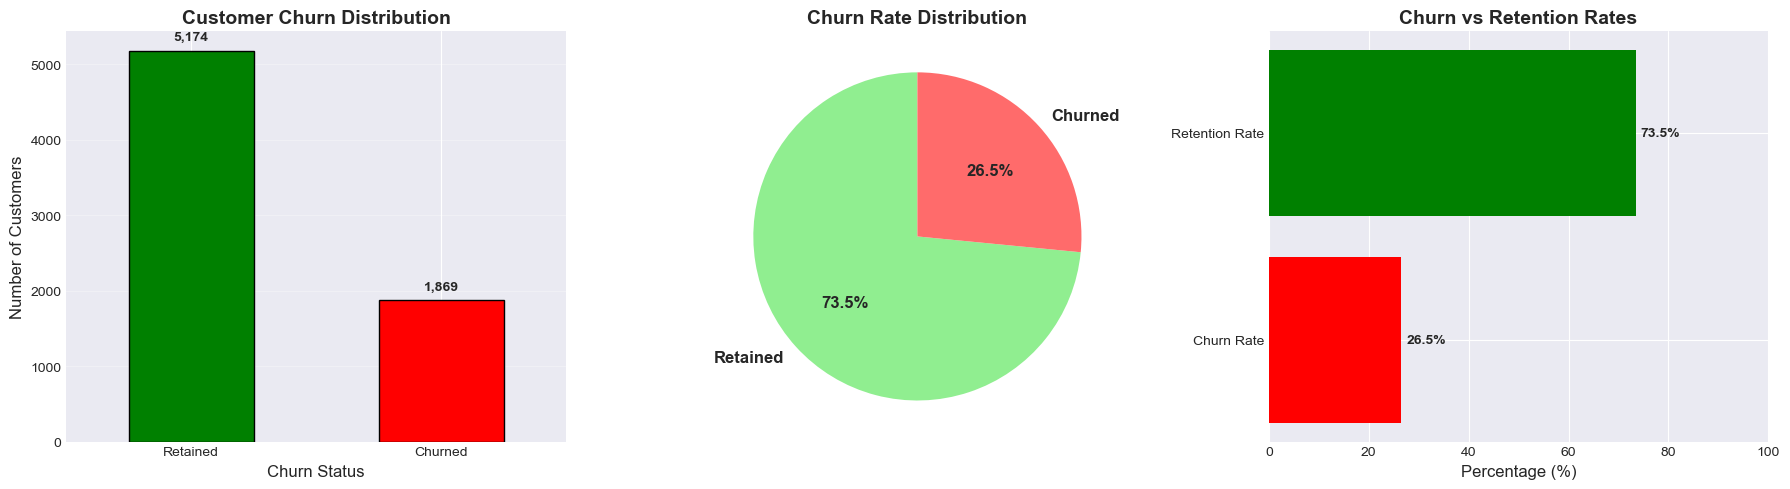

In [5]:
# Target Variable Analysis - Churn
print("\n" + "=" * 70)
print("TARGET VARIABLE ANALYSIS - CHURN")
print("=" * 70 + "\n")

# Churn distribution
print("CHURN DISTRIBUTION:")
churn_counts = churn['Churn'].value_counts()
print(churn_counts)
print()

# Calculate churn rate
total_customers = len(churn)
churned = (churn['Churn'] == 'Yes').sum()
retained = (churn['Churn'] == 'No').sum()
churn_rate = (churned / total_customers) * 100
retention_rate = (retained / total_customers) * 100

print("CHURN METRICS:")
print(f"Total Customers: {total_customers:,}")
print(f"Churned: {churned:,} ({churn_rate:.2f}%)")
print(f"Retained: {retained:,} ({retention_rate:.2f}%)")
print(f"Churn Rate: {churn_rate:.2f}%")
print(f"Retention Rate: {retention_rate:.2f}%")

# Class balance
print(f"\nCLASS BALANCE:")
ratio = retained / churned
print(f"Retention to Churn Ratio: {ratio:.2f}:1")
if ratio > 3:
    print("Imbalanced dataset - consider using:")
    print("• Class weights in model training")
    print("• SMOTE for oversampling")
    print("• Stratified sampling")
else:
    print("Reasonably balanced for classification")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize = (18, 5))

# Bar chart
churn_counts.plot(kind = 'bar', ax = axes[0], color = ['green', 'red'], edgecolor = 'black')
axes[0].set_title('Customer Churn Distribution', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Churn Status', fontsize = 12)
axes[0].set_ylabel('Number of Customers', fontsize = 12)
axes[0].set_xticklabels(['Retained', 'Churned'], rotation = 0)
axes[0].grid(axis = 'y', alpha = 0.3)

# Add count labels
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha = 'center', va = 'bottom', fontweight = 'bold')

# Pie chart
colors = ['#90EE90', '#FF6B6B']
axes[1].pie(churn_counts, labels = ['Retained', 'Churned'], autopct = '%1.1f%%', 
            startangle = 90, colors = colors, textprops = {'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Churn Rate Distribution', fontsize = 14, fontweight = 'bold')

# Percentage bar
axes[2].barh(['Churn Rate', 'Retention Rate'], [churn_rate, retention_rate], color = ['red', 'green'])
axes[2].set_title('Churn vs Retention Rates', fontsize = 14, fontweight = 'bold')
axes[2].set_xlabel('Percentage (%)', fontsize = 12)
axes[2].set_xlim(0, 100)
for i, v in enumerate([churn_rate, retention_rate]):
    axes[2].text(v + 1, i, f'{v:.1f}%', va = 'center', fontweight = 'bold')

plt.tight_layout()
plt.show()


CUSTOMER DEMOGRAPHICS ANALYSIS

GENDER DISTRIBUTION:
gender
Male      3555
Female    3488
Name: count, dtype: int64
Male: 50.5%
Female: 49.5%

SENIOR CITIZEN STATUS:
Non-Senior (0): 5,901 (83.8%)
Senior (1): 1,142 (16.2%)

PARTNER STATUS:
Partner
No     3641
Yes    3402
Name: count, dtype: int64
No: 51.7%
Yes: 48.3%

DEPENDENTS STATUS:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
No: 70.0%
Yes: 30.0%


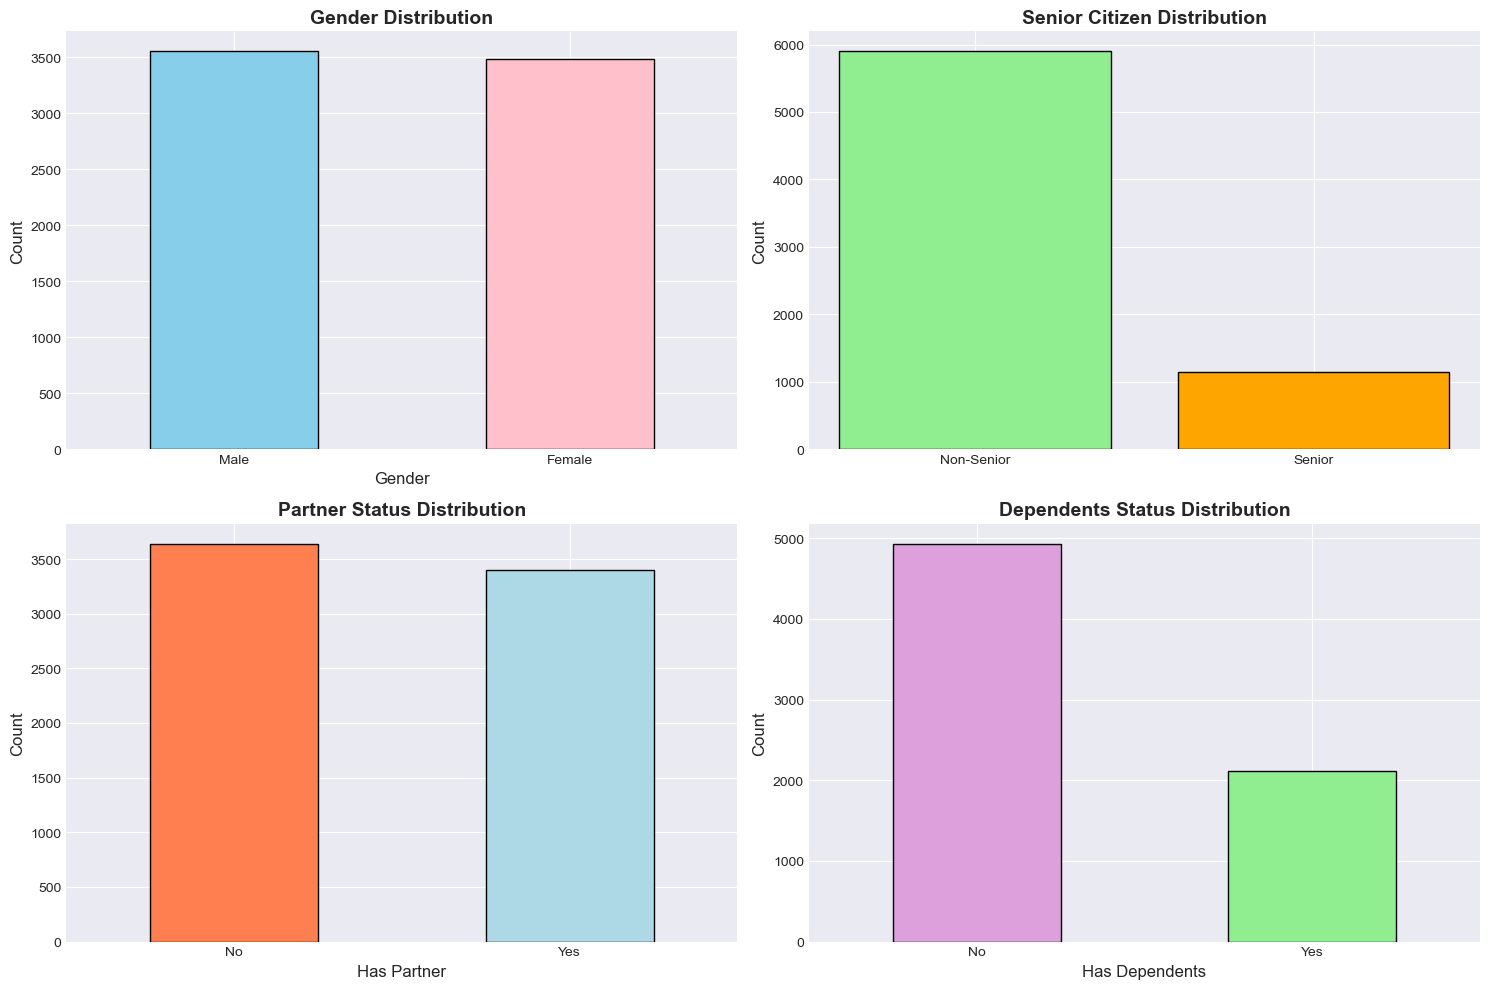

In [6]:
# Demographics Analysis
print("\n" + "=" * 70)
print("CUSTOMER DEMOGRAPHICS ANALYSIS")
print("=" * 70 + "\n")

# Gender distribution
print("GENDER DISTRIBUTION:")
gender_counts = churn['gender'].value_counts()
print(gender_counts)
for gender, count in gender_counts.items():
    pct = (count / len(churn)) * 100
    print(f"{gender}: {pct:.1f}%")
print()

# Senior Citizen
print("SENIOR CITIZEN STATUS:")
senior_counts = churn['SeniorCitizen'].value_counts()
print(f"Non-Senior (0): {senior_counts.get(0, 0):,} ({senior_counts.get(0, 0) / len(churn)*100:.1f}%)")
print(f"Senior (1): {senior_counts.get(1, 0):,} ({senior_counts.get(1, 0) / len(churn)*100:.1f}%)")
print()

# Partner status
print("PARTNER STATUS:")
partner_counts = churn['Partner'].value_counts()
print(partner_counts)
for status, count in partner_counts.items():
    pct = (count / len(churn)) * 100
    print(f"{status}: {pct:.1f}%")
print()

# Dependents
print("DEPENDENTS STATUS:")
dependents_counts = churn['Dependents'].value_counts()
print(dependents_counts)
for status, count in dependents_counts.items():
    pct = (count / len(churn)) * 100
    print(f"{status}: {pct:.1f}%")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize = (15, 10))

# Gender distribution
gender_counts.plot(kind = 'bar', ax = axes[0, 0], color = ['skyblue', 'pink'], edgecolor = 'black')
axes[0, 0].set_title('Gender Distribution', fontsize = 14, fontweight = 'bold')
axes[0, 0].set_xlabel('Gender', fontsize = 12)
axes[0, 0].set_ylabel('Count', fontsize = 12)
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation = 0)

# Senior Citizen
senior_labels = ['Non-Senior', 'Senior']
senior_values = [senior_counts.get(0, 0), senior_counts.get(1, 0)]
axes[0, 1].bar(senior_labels, senior_values, color = ['lightgreen', 'orange'], edgecolor = 'black')
axes[0, 1].set_title('Senior Citizen Distribution', fontsize = 14, fontweight = 'bold')
axes[0, 1].set_ylabel('Count', fontsize = 12)

# Partner status
partner_counts.plot(kind = 'bar', ax = axes[1, 0], color = ['coral', 'lightblue'], edgecolor = 'black')
axes[1, 0].set_title('Partner Status Distribution', fontsize = 14, fontweight = 'bold')
axes[1, 0].set_xlabel('Has Partner', fontsize = 12)
axes[1, 0].set_ylabel('Count', fontsize = 12)
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation = 0)

# Dependents
dependents_counts.plot(kind = 'bar', ax = axes[1, 1], color = ['plum', 'lightgreen'], edgecolor = 'black')
axes[1, 1].set_title('Dependents Status Distribution', fontsize = 14, fontweight = 'bold')
axes[1, 1].set_xlabel('Has Dependents', fontsize = 12)
axes[1, 1].set_ylabel('Count', fontsize = 12)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation = 0)

plt.tight_layout()
plt.show()


SERVICE USAGE ANALYSIS

TENURE STATISTICS (Months):
count   7043.000
mean      32.371
std       24.559
min        0.000
25%        9.000
50%       29.000
75%       55.000
max       72.000
Name: tenure, dtype: float64

PHONE SERVICE:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MULTIPLE LINES:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

INTERNET SERVICE TYPE:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
Fiber optic: 44.0%
DSL: 34.4%
No: 21.7%


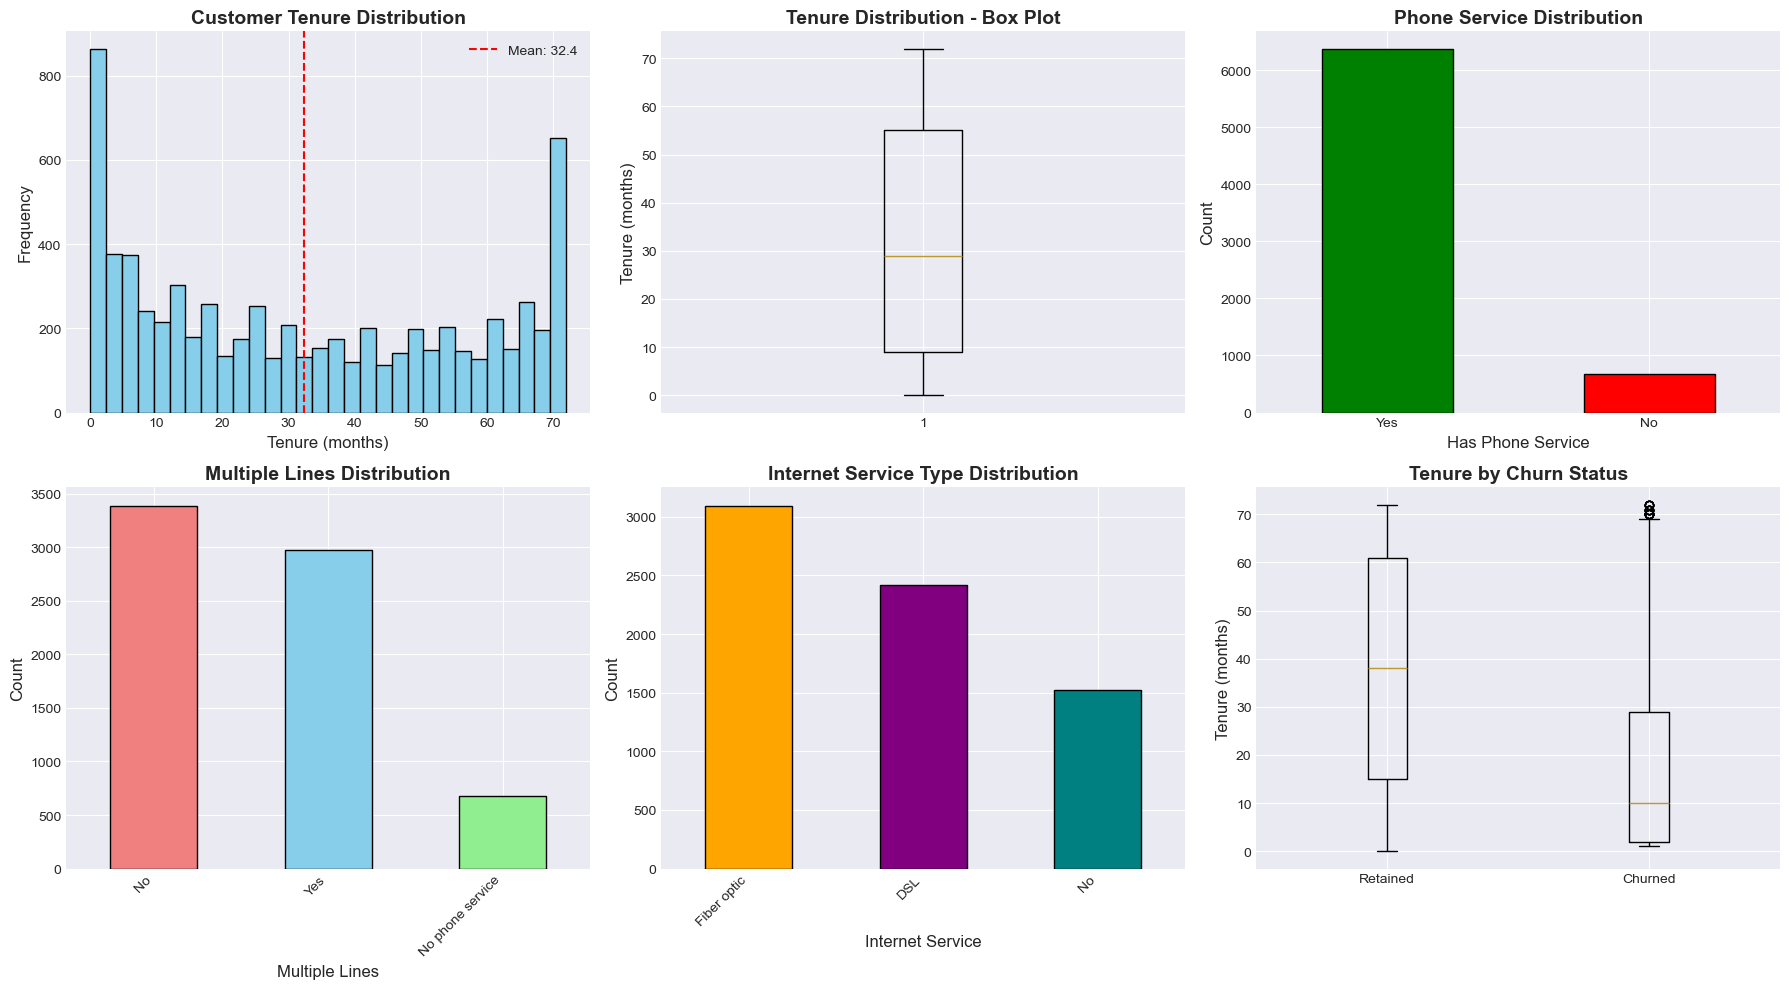

In [7]:
# Service Usage Analysis
print("\n" + "=" * 70)
print("SERVICE USAGE ANALYSIS")
print("=" * 70 + "\n")

# Tenure analysis
print("TENURE STATISTICS (Months):")
print(churn['tenure'].describe())
print()

# Phone Service
print("PHONE SERVICE:")
phone_counts = churn['PhoneService'].value_counts()
print(phone_counts)
print()

# Multiple Lines
print("MULTIPLE LINES:")
lines_counts = churn['MultipleLines'].value_counts()
print(lines_counts)
print()

# Internet Service
print("INTERNET SERVICE TYPE:")
internet_counts = churn['InternetService'].value_counts()
print(internet_counts)
for service, count in internet_counts.items():
    pct = (count / len(churn)) * 100
    print(f"{service}: {pct:.1f}%")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize = (18, 10))

# Tenure distribution
axes[0, 0].hist(churn['tenure'], bins = 30, color = 'skyblue', edgecolor = 'black')
axes[0, 0].set_title('Customer Tenure Distribution', fontsize = 14, fontweight = 'bold')
axes[0, 0].set_xlabel('Tenure (months)', fontsize = 12)
axes[0, 0].set_ylabel('Frequency', fontsize = 12)
axes[0, 0].axvline(churn['tenure'].mean(), color = 'red', linestyle='--', label = f"Mean: {churn['tenure'].mean():.1f}")
axes[0, 0].legend()

# Tenure box plot
axes[0, 1].boxplot(churn['tenure'])
axes[0, 1].set_title('Tenure Distribution - Box Plot', fontsize = 14, fontweight = 'bold')
axes[0, 1].set_ylabel('Tenure (months)', fontsize = 12)

# Phone Service
phone_counts.plot(kind = 'bar', ax = axes[0, 2], color = ['green', 'red'], edgecolor = 'black')
axes[0, 2].set_title('Phone Service Distribution', fontsize = 14, fontweight = 'bold')
axes[0, 2].set_xlabel('Has Phone Service', fontsize = 12)
axes[0, 2].set_ylabel('Count', fontsize = 12)
axes[0, 2].set_xticklabels(axes[0, 2].get_xticklabels(), rotation = 0)

# Multiple Lines
lines_counts.plot(kind = 'bar', ax = axes[1, 0], color = ['lightcoral', 'skyblue', 'lightgreen'], edgecolor = 'black')
axes[1, 0].set_title('Multiple Lines Distribution', fontsize = 14, fontweight = 'bold')
axes[1, 0].set_xlabel('Multiple Lines', fontsize = 12)
axes[1, 0].set_ylabel('Count', fontsize = 12)
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation = 45, ha = 'right')

# Internet Service
internet_counts.plot(kind = 'bar', ax = axes[1, 1], color = ['orange', 'purple', 'teal'], edgecolor = 'black')
axes[1, 1].set_title('Internet Service Type Distribution', fontsize = 14, fontweight = 'bold')
axes[1, 1].set_xlabel('Internet Service', fontsize = 12)
axes[1, 1].set_ylabel('Count', fontsize = 12)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation = 45, ha = 'right')

# Tenure by Churn
axes[1, 2].boxplot([churn[churn['Churn'] == 'No']['tenure'], churn[churn['Churn'] == 'Yes']['tenure']], 
                    labels = ['Retained', 'Churned'])
axes[1, 2].set_title('Tenure by Churn Status', fontsize = 14, fontweight = 'bold')
axes[1, 2].set_ylabel('Tenure (months)', fontsize = 12)

plt.tight_layout()
plt.show()


ADDITIONAL SERVICES ANALYSIS

ADDITIONAL SERVICES USAGE:
OnlineSecurity      : 2,019 customers (28.7%)
OnlineBackup        : 2,429 customers (34.5%)
DeviceProtection    : 2,422 customers (34.4%)
TechSupport         : 2,044 customers (29.0%)
StreamingTV         : 2,707 customers (38.4%)
StreamingMovies     : 2,732 customers (38.8%)


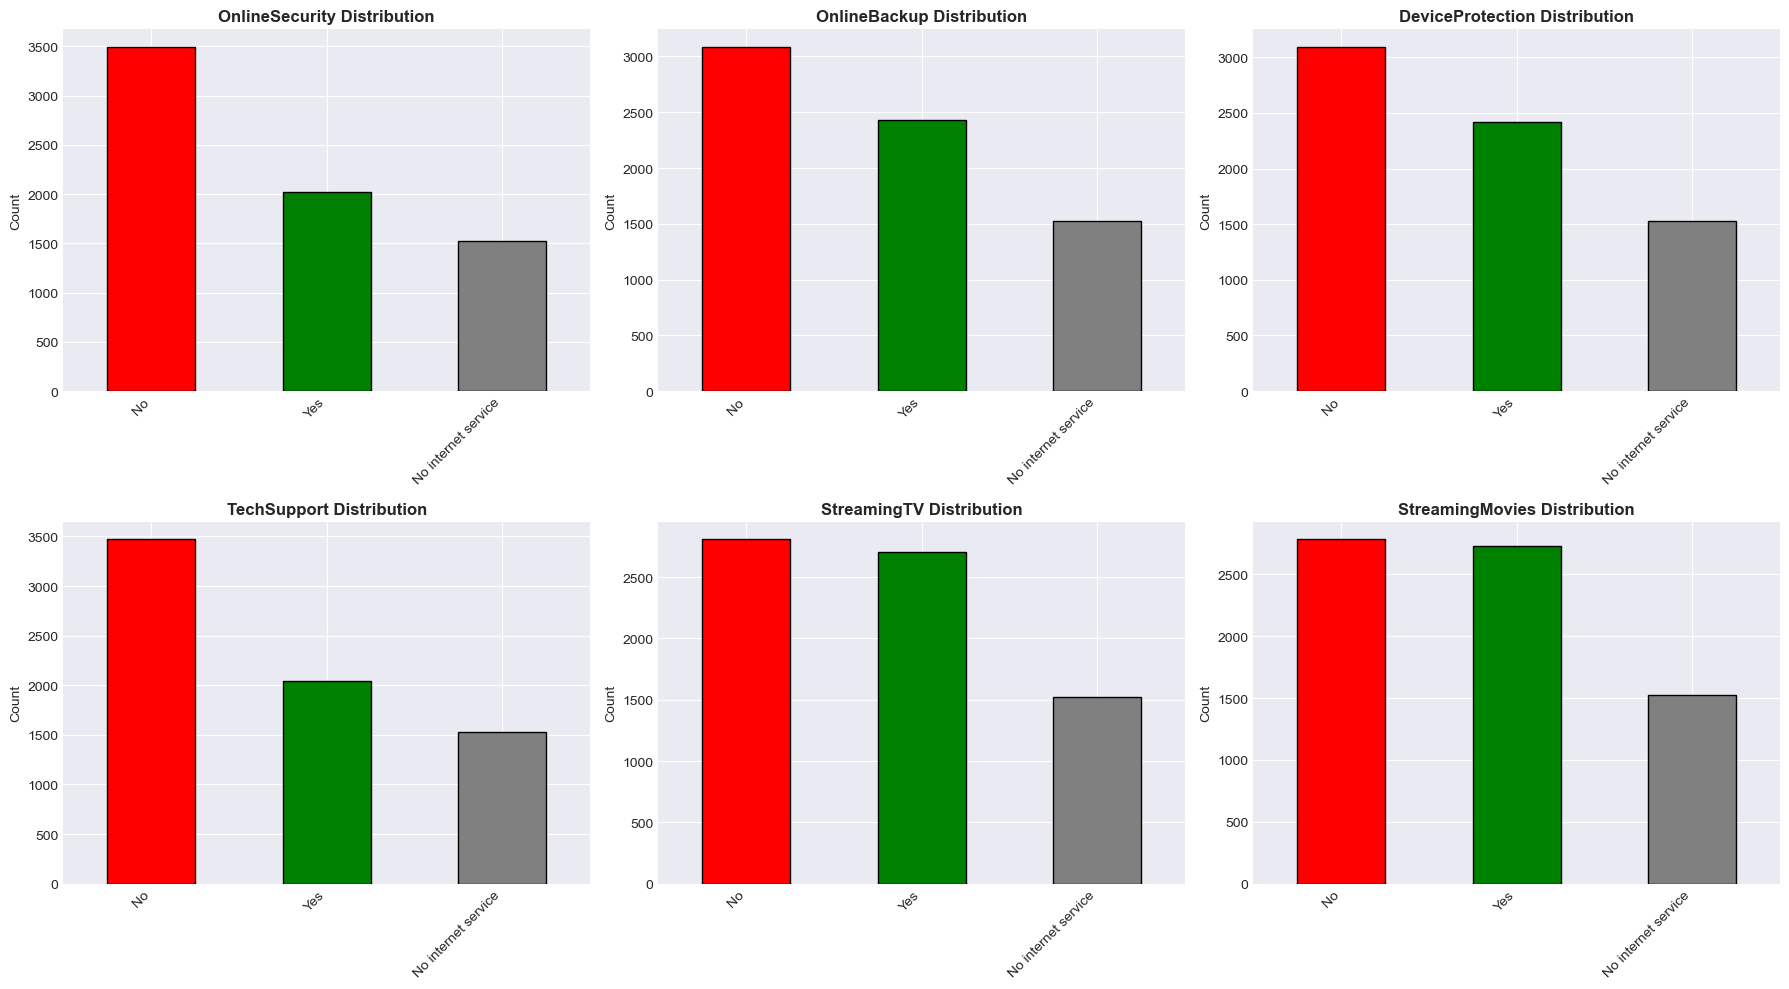

In [8]:
# Additional Services Analysis
print("\n" + "=" * 70)
print("ADDITIONAL SERVICES ANALYSIS")
print("=" * 70 + "\n")

# List of additional services
additional_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

print("ADDITIONAL SERVICES USAGE:")
for service in additional_services:
    service_counts = churn[service].value_counts()
    yes_count = service_counts.get('Yes', 0)
    yes_pct = (yes_count / len(churn)) * 100
    print(f"{service:20s}: {yes_count:,} customers ({yes_pct:.1f}%)")

# Visualization
fig, axes = plt.subplots(2, 3, figsize = (18, 10))

for idx, service in enumerate(additional_services):
    row = idx // 3
    col = idx % 3
    
    service_counts = churn[service].value_counts()
    service_counts.plot(kind = 'bar', ax = axes[row, col], color = ['red', 'green', 'gray'], edgecolor = 'black')
    axes[row, col].set_title(f'{service} Distribution', fontsize = 12, fontweight = 'bold')
    axes[row, col].set_xlabel('')
    axes[row, col].set_ylabel('Count', fontsize = 10)
    axes[row, col].set_xticklabels(axes[row, col].get_xticklabels(), rotation = 45, ha = 'right')

plt.tight_layout()
plt.show()


CONTRACT & BILLING ANALYSIS

CONTRACT TYPE:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
Month-to-month: 55.0%
Two year: 24.1%
One year: 20.9%

PAPERLESS BILLING:
PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64
Yes: 59.2%
No: 40.8%

PAYMENT METHOD:
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64
Electronic check: 33.6%
Mailed check: 22.9%
Bank transfer (automatic): 21.9%
Credit card (automatic): 21.6%


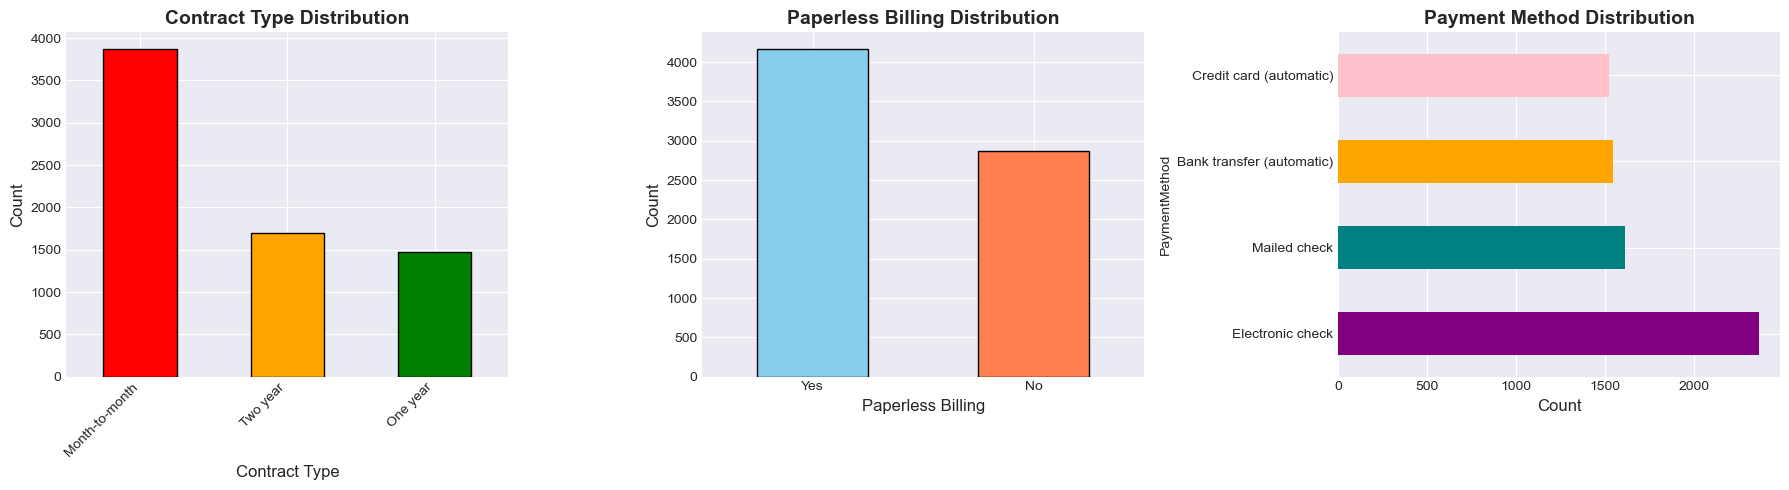

In [9]:
# Contract & Billing Analysis
print("\n" + "=" * 70)
print("CONTRACT & BILLING ANALYSIS")
print("=" * 70 + "\n")

# Contract type
print("CONTRACT TYPE:")
contract_counts = churn['Contract'].value_counts()
print(contract_counts)
for contract, count in contract_counts.items():
    pct = (count / len(churn)) * 100
    print(f"{contract}: {pct:.1f}%")
print()

# Paperless Billing
print("PAPERLESS BILLING:")
paperless_counts = churn['PaperlessBilling'].value_counts()
print(paperless_counts)
for status, count in paperless_counts.items():
    pct = (count / len(churn)) * 100
    print(f"{status}: {pct:.1f}%")
print()

# Payment Method
print("PAYMENT METHOD:")
payment_counts = churn['PaymentMethod'].value_counts()
print(payment_counts)
for method, count in payment_counts.items():
    pct = (count / len(churn)) * 100
    print(f"{method}: {pct:.1f}%")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize = (18, 5))

# Contract type
contract_counts.plot(kind = 'bar', ax = axes[0], color = ['red', 'orange', 'green'], edgecolor = 'black')
axes[0].set_title('Contract Type Distribution', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Contract Type', fontsize = 12)
axes[0].set_ylabel('Count', fontsize = 12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation = 45, ha = 'right')

# Paperless Billing
paperless_counts.plot(kind = 'bar', ax = axes[1], color = ['skyblue', 'coral'], edgecolor = 'black')
axes[1].set_title('Paperless Billing Distribution', fontsize = 14, fontweight = 'bold')
axes[1].set_xlabel('Paperless Billing', fontsize = 12)
axes[1].set_ylabel('Count', fontsize = 12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation = 0)

# Payment Method
payment_counts.plot(kind = 'barh', ax = axes[2], color = ['purple', 'teal', 'orange', 'pink'])
axes[2].set_title('Payment Method Distribution', fontsize = 14, fontweight = 'bold')
axes[2].set_xlabel('Count', fontsize = 12)

plt.tight_layout()
plt.show()


FINANCIAL ANALYSIS

MONTHLY CHARGES STATISTICS:
count   7043.000
mean      64.762
std       30.090
min       18.250
25%       35.500
50%       70.350
75%       89.850
max      118.750
Name: MonthlyCharges, dtype: float64

TOTAL CHARGES STATISTICS:
count   7032.000
mean    2283.300
std     2266.771
min       18.800
25%      401.450
50%     1397.475
75%     3794.738
max     8684.800
Name: TotalCharges, dtype: float64

AVERAGE CHARGES BY CHURN STATUS:
       MonthlyCharges  TotalCharges
Churn                              
No             61.265      2555.344
Yes            74.441      1531.796


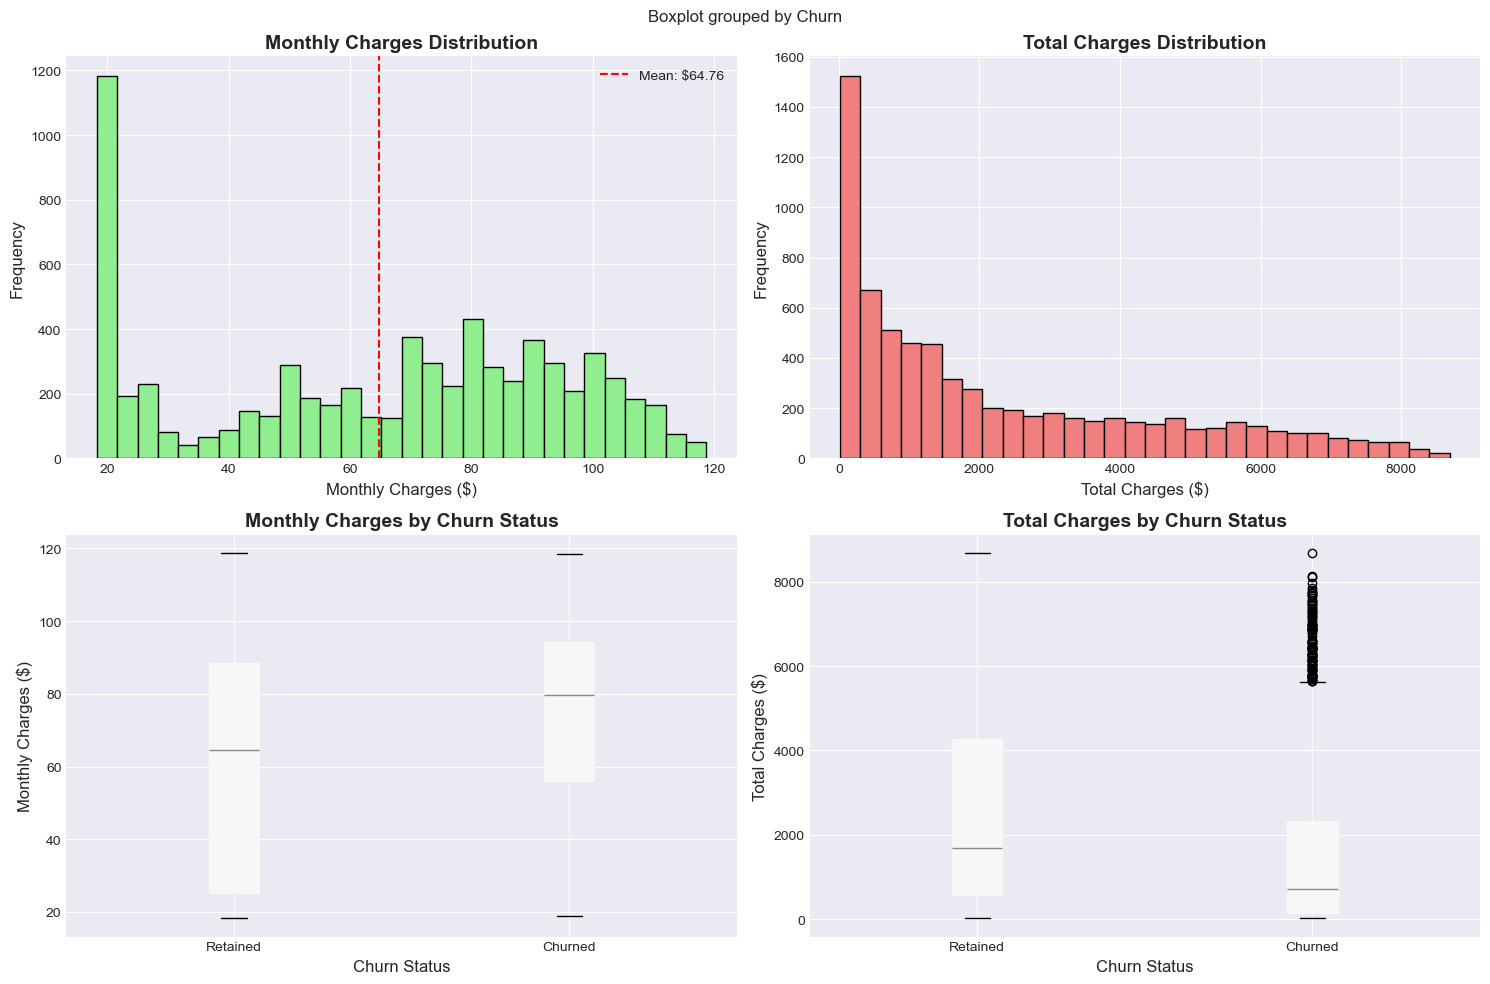

In [10]:
# Financial Analysis
print("\n" + "=" * 70)
print("FINANCIAL ANALYSIS")
print("=" * 70 + "\n")

# Monthly Charges
print("MONTHLY CHARGES STATISTICS:")
print(churn['MonthlyCharges'].describe())
print()

# Total Charges
print("TOTAL CHARGES STATISTICS:")
print(churn['TotalCharges'].describe())
print()

# Average by churn status
print("AVERAGE CHARGES BY CHURN STATUS:")
charges_by_churn = churn.groupby('Churn')[['MonthlyCharges', 'TotalCharges']].mean()
print(charges_by_churn)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize = (15, 10))

# Monthly Charges distribution
axes[0, 0].hist(churn['MonthlyCharges'], bins = 30, color = 'lightgreen', edgecolor = 'black')
axes[0, 0].set_title('Monthly Charges Distribution', fontsize = 14, fontweight = 'bold')
axes[0, 0].set_xlabel('Monthly Charges ($)', fontsize = 12)
axes[0, 0].set_ylabel('Frequency', fontsize = 12)
axes[0, 0].axvline(churn['MonthlyCharges'].mean(), color = 'red', linestyle = '--', label = f"Mean: ${churn['MonthlyCharges'].mean():.2f}")
axes[0, 0].legend()

# Total Charges distribution
axes[0, 1].hist(churn['TotalCharges'].dropna(), bins = 30, color = 'lightcoral', edgecolor = 'black')
axes[0, 1].set_title('Total Charges Distribution', fontsize = 14, fontweight = 'bold')
axes[0, 1].set_xlabel('Total Charges ($)', fontsize = 12)
axes[0, 1].set_ylabel('Frequency', fontsize = 12)

# Monthly Charges by Churn
churn.boxplot(column = 'MonthlyCharges', by = 'Churn', ax = axes[1, 0], patch_artist = True)
axes[1, 0].set_title('Monthly Charges by Churn Status', fontsize = 14, fontweight = 'bold')
axes[1, 0].set_xlabel('Churn Status', fontsize = 12)
axes[1, 0].set_ylabel('Monthly Charges ($)', fontsize = 12)
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Retained', 'Churned'])

# Total Charges by Churn
churn.boxplot(column = 'TotalCharges', by = 'Churn', ax = axes[1, 1], patch_artist = True)
axes[1, 1].set_title('Total Charges by Churn Status', fontsize = 14, fontweight = 'bold')
axes[1, 1].set_xlabel('Churn Status', fontsize = 12)
axes[1, 1].set_ylabel('Total Charges ($)', fontsize = 12)
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['Retained', 'Churned'])

plt.tight_layout()
plt.show()


CHURN ANALYSIS BY KEY FEATURES

CHURN RATE BY CONTRACT TYPE:
Churn              No    Yes
Contract                    
Month-to-month 57.290 42.710
One year       88.730 11.270
Two year       97.168  2.832

CHURN RATE BY INTERNET SERVICE:
Churn               No    Yes
InternetService              
DSL             81.041 18.959
Fiber optic     58.107 41.893
No              92.595  7.405

CHURN RATE BY AGE GROUP:
Churn          No    Yes
Non-Senior 76.394 23.606
Senior     58.319 41.681


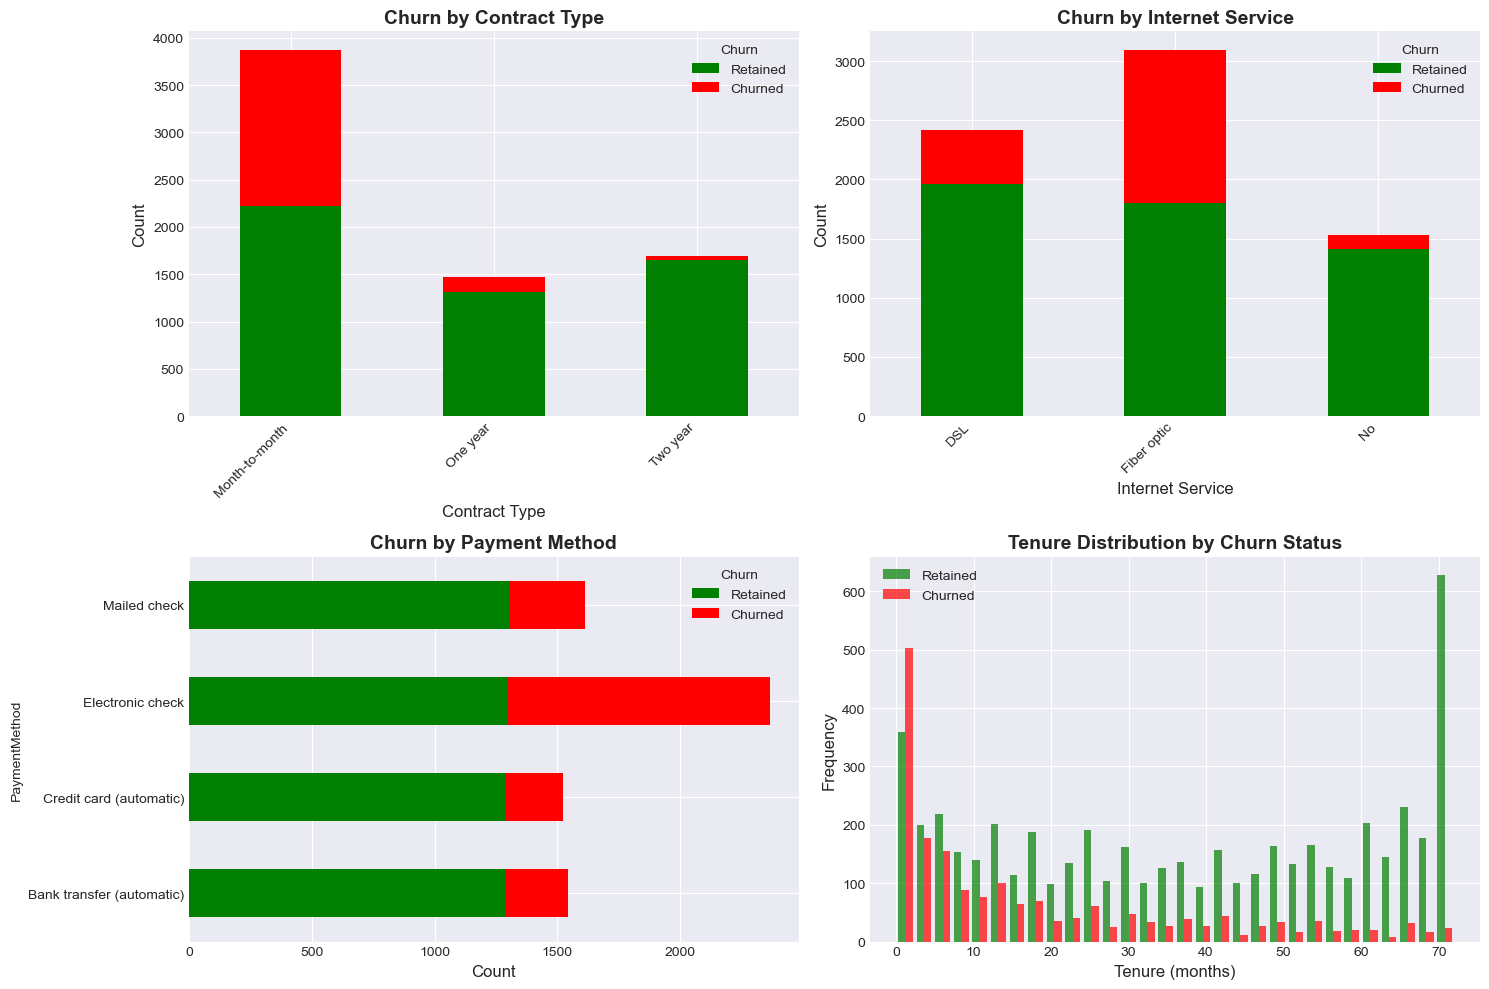

In [11]:
# Churn Analysis by Key Features
print("\n" + "=" * 70)
print("CHURN ANALYSIS BY KEY FEATURES")
print("=" * 70 + "\n")

# Churn by Contract Type
print("CHURN RATE BY CONTRACT TYPE:")
contract_churn = pd.crosstab(churn['Contract'], churn['Churn'], normalize = 'index') * 100
print(contract_churn)
print()

# Churn by Internet Service
print("CHURN RATE BY INTERNET SERVICE:")
internet_churn = pd.crosstab(churn['InternetService'], churn['Churn'], normalize = 'index') * 100
print(internet_churn)
print()

# Churn by Senior Citizen
print("CHURN RATE BY AGE GROUP:")
senior_churn = pd.crosstab(churn['SeniorCitizen'], churn['Churn'], normalize = 'index') * 100
senior_churn.index = ['Non-Senior', 'Senior']
print(senior_churn)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize = (15, 10))

# Contract vs Churn
contract_churn_counts = pd.crosstab(churn['Contract'], churn['Churn'])
contract_churn_counts.plot(kind = 'bar', stacked = True, ax = axes[0, 0], color = ['green', 'red'])
axes[0, 0].set_title('Churn by Contract Type', fontsize = 14, fontweight = 'bold')
axes[0, 0].set_xlabel('Contract Type', fontsize = 12)
axes[0, 0].set_ylabel('Count', fontsize = 12)
axes[0, 0].legend(title = 'Churn', labels = ['Retained', 'Churned'])
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation = 45, ha = 'right')

# Internet Service vs Churn
internet_churn_counts = pd.crosstab(churn['InternetService'], churn['Churn'])
internet_churn_counts.plot(kind = 'bar', stacked = True, ax = axes[0, 1], color = ['green', 'red'])
axes[0, 1].set_title('Churn by Internet Service', fontsize = 14, fontweight = 'bold')
axes[0, 1].set_xlabel('Internet Service', fontsize = 12)
axes[0, 1].set_ylabel('Count', fontsize = 12)
axes[0, 1].legend(title = 'Churn', labels = ['Retained', 'Churned'])
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation = 45, ha = 'right')

# Payment Method vs Churn
payment_churn_counts = pd.crosstab(churn['PaymentMethod'], churn['Churn'])
payment_churn_counts.plot(kind = 'barh', stacked = True, ax = axes[1, 0], color = ['green', 'red'])
axes[1, 0].set_title('Churn by Payment Method', fontsize = 14, fontweight = 'bold')
axes[1, 0].set_xlabel('Count', fontsize = 12)
axes[1, 0].legend(title = 'Churn', labels = ['Retained', 'Churned'])

# Tenure vs Churn comparison
axes[1, 1].hist([churn[churn['Churn'] == 'No']['tenure'],churn[churn['Churn'] == 'Yes']['tenure']],
                bins = 30, label = ['Retained', 'Churned'], color = ['green', 'red'], alpha = 0.7)
axes[1, 1].set_title('Tenure Distribution by Churn Status', fontsize = 14, fontweight = 'bold')
axes[1, 1].set_xlabel('Tenure (months)', fontsize = 12)
axes[1, 1].set_ylabel('Frequency', fontsize = 12)
axes[1, 1].legend()

plt.tight_layout()
plt.show()


CORRELATION ANALYSIS

Numerical columns for correlation: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

CORRELATION MATRIX:
                SeniorCitizen  tenure  MonthlyCharges  TotalCharges
SeniorCitizen           1.000   0.017           0.220         0.102
tenure                  0.017   1.000           0.248         0.826
MonthlyCharges          0.220   0.248           1.000         0.651
TotalCharges            0.102   0.826           0.651         1.000


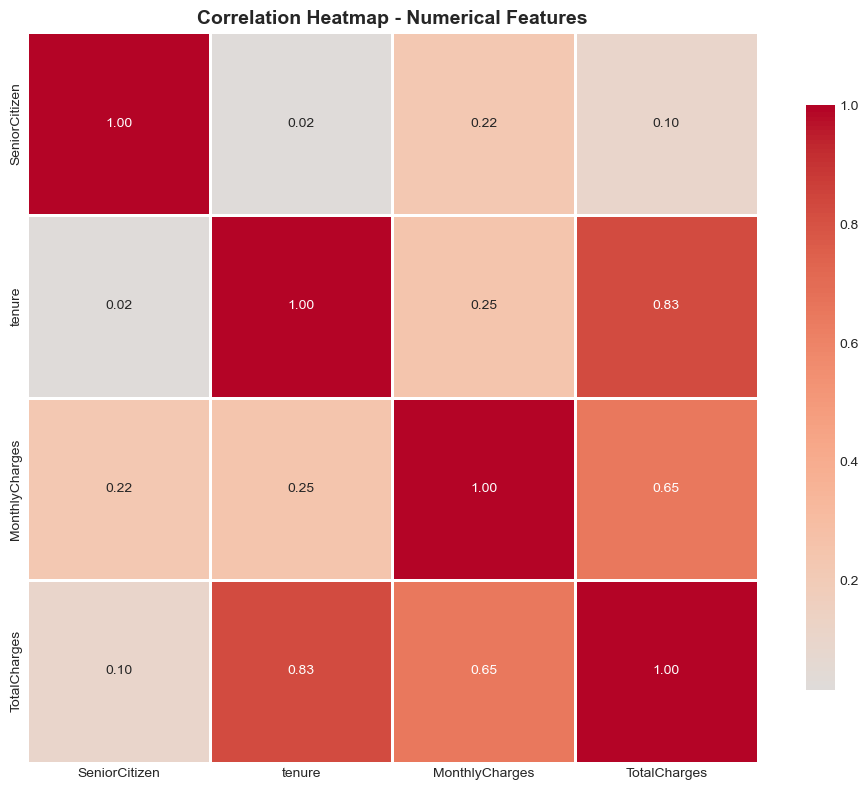

In [12]:
# Correlation Analysis
print("\n" + "=" * 70)
print("CORRELATION ANALYSIS")
print("=" * 70 + "\n")

# Select numerical columns
numerical_cols = churn.select_dtypes(include = [np.number]).columns.tolist()
print(f"Numerical columns for correlation: {numerical_cols}")

# Calculate correlation
correlation_matrix = churn[numerical_cols].corr()

print("\nCORRELATION MATRIX:")
print(correlation_matrix)

# Visualization
plt.figure(figsize = (10, 8))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', center = 0, square = True, linewidths = 1, fmt = '.2f', 
            cbar_kws = {"shrink": 0.8})
plt.title('Correlation Heatmap - Numerical Features', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

In [13]:
# Summary Statistics
print("\n" + "=" * 70)
print("TELECOM CHURN - COMPREHENSIVE SUMMARY")
print("=" * 70 + "\n")

summary_stats_churn = {
    'Total Customers': f"{len(churn):,}",
    'Churned Customers': f"{(churn['Churn'] == 'Yes').sum():,}",
    'Churn Rate': f"{((churn['Churn'] == 'Yes').sum() / len(churn) * 100):.2f}%",
    'Avg Tenure': f"{churn['tenure'].mean():.1f} months",
    'Avg Monthly Charges': f"${churn['MonthlyCharges'].mean():.2f}",
    'Avg Total Charges': f"${churn['TotalCharges'].mean():.2f}",
    'Senior Citizens': f"{(churn['SeniorCitizen'] == 1).sum():,} ({(churn['SeniorCitizen'] == 1).sum() / len(churn) * 100:.1f}%)",
    'With Partners': f"{(churn['Partner'] == 'Yes').sum():,} ({(churn['Partner'] == 'Yes').sum() / len(churn) * 100:.1f}%)",
    'With Dependents': f"{(churn['Dependents'] == 'Yes').sum():,} ({(churn['Dependents'] == 'Yes').sum() / len(churn) * 100:.1f}%)",
    'Fiber Optic Users': f"{(churn['InternetService'] == 'Fiber optic').sum():,}",
    'Month-to-Month': f"{(churn['Contract'] == 'Month-to-month').sum():,}",
    'Missing Values': f"{churn.isnull().sum().sum()}"
}

print("KEY METRICS:")
for key, value in summary_stats_churn.items():
    print(f"   • {key}: {value}")


TELECOM CHURN - COMPREHENSIVE SUMMARY

KEY METRICS:
   • Total Customers: 7,043
   • Churned Customers: 1,869
   • Churn Rate: 26.54%
   • Avg Tenure: 32.4 months
   • Avg Monthly Charges: $64.76
   • Avg Total Charges: $2283.30
   • Senior Citizens: 1,142 (16.2%)
   • With Partners: 3,402 (48.3%)
   • With Dependents: 2,110 (30.0%)
   • Fiber Optic Users: 3,096
   • Month-to-Month: 3,875
   • Missing Values: 11


In [14]:
# Key Findings & Insights
print("\n" + "=" * 70)
print("KEY FINDINGS & INSIGHTS - TELECOM CHURN")
print("=" * 70 + "\n")

print("1. CHURN OVERVIEW:")
churn_rate = (churn['Churn'] == 'Yes').sum() / len(churn) * 100
print(f"   • Churn rate: {churn_rate:.1f}%")
print(f"   • {(churn['Churn'] == 'Yes').sum():,} customers churned out of {len(churn):,}")
if churn_rate > 25:
    print(f"   • High churn rate! Requires immediate attention")
elif churn_rate > 15:
    print(f"   • Moderate churn rate")
else:
    print(f"   • Relatively low churn rate")
print()

print("2. HIGH-RISK FACTORS:")
# Month-to-month contract
mtm_churn = churn[churn['Contract'] == 'Month-to-month']['Churn'].value_counts(normalize = True)['Yes'] * 100
print(f"   • Month-to-month contracts: {mtm_churn:.1f}% churn rate")

# Fiber optic
fiber_churn = churn[churn['InternetService'] == 'Fiber optic']['Churn'].value_counts(normalize = True)['Yes'] * 100
print(f"   • Fiber optic users: {fiber_churn:.1f}% churn rate")

# Electronic check
echeck_churn = churn[churn['PaymentMethod'] == 'Electronic check']['Churn'].value_counts(normalize = True)['Yes'] * 100
print(f"   • Electronic check payment: {echeck_churn:.1f}% churn rate")
print()

print("3. CUSTOMER PROFILE:")
avg_tenure_churned = churn[churn['Churn'] == 'Yes']['tenure'].mean()
avg_tenure_retained = churn[churn['Churn'] == 'No']['tenure'].mean()
print(f"   • Churned customers avg tenure: {avg_tenure_churned:.1f} months")
print(f"   • Retained customers avg tenure: {avg_tenure_retained:.1f} months")
print(f"   • Churned customers have {((avg_tenure_retained - avg_tenure_churned) / avg_tenure_churned * 100):.0f}% shorter tenure")
print()

print("4. FINANCIAL IMPACT:")
avg_monthly_churned = churn[churn['Churn'] == 'Yes']['MonthlyCharges'].mean()
avg_monthly_retained = churn[churn['Churn'] == 'No']['MonthlyCharges'].mean()
print(f"   • Churned customers avg monthly: ${avg_monthly_churned:.2f}")
print(f"   • Retained customers avg monthly: ${avg_monthly_retained:.2f}")
print(f"   • Churned customers pay {'more' if avg_monthly_churned > avg_monthly_retained else 'less'}")


KEY FINDINGS & INSIGHTS - TELECOM CHURN

1. CHURN OVERVIEW:
   • Churn rate: 26.5%
   • 1,869 customers churned out of 7,043
   • High churn rate! Requires immediate attention

2. HIGH-RISK FACTORS:
   • Month-to-month contracts: 42.7% churn rate
   • Fiber optic users: 41.9% churn rate
   • Electronic check payment: 45.3% churn rate

3. CUSTOMER PROFILE:
   • Churned customers avg tenure: 18.0 months
   • Retained customers avg tenure: 37.6 months
   • Churned customers have 109% shorter tenure

4. FINANCIAL IMPACT:
   • Churned customers avg monthly: $74.44
   • Retained customers avg monthly: $61.27
   • Churned customers pay more


In [15]:
# Save Processed Churn Data
print("\n" + "=" * 70)
print("SAVE PROCESSED DATA")
print("=" * 70 + "\n")

# Save cleaned dataset
output_path_churn = '../data/processed/telecom_churn_explored.csv'

try:
    churn.to_csv(output_path_churn, index=False)
    print(f" Processed churn dataset saved to: {output_path_churn}")
    print(f"   Total customers: {len(churn):,}")
    print(f"   Columns: {len(churn.columns)}")
    print(f"   Shape: {churn.shape}")
except Exception as e:
    print(f" Could not save file: {e}")

print("\n" + "=" * 70)
print("TELECOM CUSTOMER CHURN EXPLORATION COMPLETE!")
print("=" * 70)
print("\nDataset Summary:")
print(f"   • {len(churn):,} customers analyzed")
print(f"   • {(churn['Churn'] == 'Yes').sum():,} churned ({churn_rate:.1f}%)")
print(f"   • {len(churn.columns)} features")
print(f"   • High-risk: Month-to-month contracts, Fiber optic, Electronic check")
print("\nReady for churn prediction modeling!")
print("=" * 70 + "\n")


SAVE PROCESSED DATA

 Processed churn dataset saved to: ../data/processed/telecom_churn_explored.csv
   Total customers: 7,043
   Columns: 21
   Shape: (7043, 21)

TELECOM CUSTOMER CHURN EXPLORATION COMPLETE!

Dataset Summary:
   • 7,043 customers analyzed
   • 1,869 churned (26.5%)
   • 21 features
   • High-risk: Month-to-month contracts, Fiber optic, Electronic check

Ready for churn prediction modeling!

